In [1]:
import os
import copy
import math
import random
import warnings
from itertools import combinations
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import squarify
import shap
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import matplotlib as mpl
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_predict
)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
# ---- Metrics ----
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mutual_info_score
)
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import art3d


# ---- Feature selection ----
from sklearn.feature_selection import mutual_info_classif

# ---- Linear models ----
from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression,
    Lasso,
    ElasticNet,
    OrthogonalMatchingPursuit
)

# ---- Tree-based models ----
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)

# ---- Instance-based models ----
from sklearn.neighbors import (
    KNeighborsRegressor,
    RadiusNeighborsRegressor
)

# ---- SVM / Kernel models ----
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge

# ---- Gaussian process ----
from sklearn.gaussian_process import GaussianProcessRegressor

# ---- Neural networks ----
from sklearn.neural_network import MLPRegressor

# ---- Boosting models ----
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


from sklearn.linear_model import Lasso, ElasticNet, OrthogonalMatchingPursuit
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor

# 1.数据处理

In [2]:
data = pd.read_csv(r"D:\论文数据\2025.2 出口选择\20190519+问卷统计表.csv", encoding='utf-8') 
data = data.drop('序号', axis=1)
#data

In [3]:
rename_dict = {
    '性别': 'GE',  ##
    '年龄段': 'AG',  ## 
    '教育程度': 'ED',  ##
    '行动能力': 'MO',  ##
    '您乘坐客船的经历（不含本次）': 'PE',  ##
    '与您一起出行的人员数量': 'GS',  ##
    '接受船舶疏散教育/训练的经历': 'ET',  ##                     
    '听到疏散逃生警报，您会等待工作人员确认后再行动': 'AM1',
    '听到疏散逃生警报，您会立即疏散逃生': 'AM2',
    '听到疏散逃生警报，您会观察其他人的动静再行动': 'AM3',
    '假如听到疏散逃生警报，您会自行开门查看确认': 'AM4',      
    '疏散逃生时，您会选择距离最近的出口': 'EC1',  #
    '疏散逃生时，您会选择最熟悉的出口': 'EC2',  #
    '疏散逃生时，您会选择跟着大多数人走': 'EC3',  #
    '疏散逃生时，您会选择听从疏散指示或广播': 'EC4',  #       
    '您会耐心排队等待': 'CO1',
    '您会自行寻找其他出口': 'CO2',  
    '您会往前挤行': 'CO3',
    '您会听从船员引导': 'CO4',
    '贵重物品遗留，您是否会返回寻找': 'RT1',
    '家人遗留，您是否会返回寻找': 'RT2',
    '疏散过程中，您是否会协助他人进行疏散': 'CC1',
    '疏散过程中，您是否会超越他人或向前挤行': 'CC2',
    '疏散逃生时，您是否会寻找同伴一起逃生': 'FC',
    '假如发生火灾，您是否会出现恐慌心理': 'EP',
    '疏散时，您是否会携带大件行李箱': 'CL',
    '疏散时，您是否会跟从团队中的临时领导者': 'FL'
}
data.rename(columns=rename_dict, inplace=True)

In [4]:
df = data
'''
df = data
df_ec = df.drop(columns=['NE', 'FE', 'FM', 'FI'])
df_ne = df.drop(columns=['FE', 'FM', 'FI'])
df_fe = df.drop(columns=['NE', 'FM', 'FI'])
df_fm = df.drop(columns=['NE', 'FE', 'FI'])
df_fi = df.drop(columns=['NE', 'FE', 'FM'])
'''

"\ndf = data\ndf_ec = df.drop(columns=['NE', 'FE', 'FM', 'FI'])\ndf_ne = df.drop(columns=['FE', 'FM', 'FI'])\ndf_fe = df.drop(columns=['NE', 'FM', 'FI'])\ndf_fm = df.drop(columns=['NE', 'FE', 'FI'])\ndf_fi = df.drop(columns=['NE', 'FE', 'FM'])\n"

In [5]:
df.columns

Index(['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET', 'AM1', 'AM2', 'AM3', 'AM4',
       'EC1', 'EC2', 'EC3', 'EC4', 'CO1', 'CO2', 'CO3', 'CO4', 'RT1', 'RT2',
       'CC1', 'CC2', 'FC', 'EP', 'CL', 'FL'],
      dtype='str')

# 2.数据展示

In [6]:
# 保存路径
save_path = r"D:\论文数据\2025.10 出口选择\矩形树图"
os.makedirs(save_path, exist_ok=True)  # 若文件夹不存在则创建

# 汇总每个变量的选项数量
summary_list = []
for col in df.columns:
    counts = df[col].value_counts().reset_index()
    counts.columns = ['Category', 'Count']
    counts['Variable'] = col
    counts['Label'] = counts['Variable'] + " (" + counts['Category'].astype(str) + ")"
    summary_list.append(counts)    

# 合并所有统计结果
summary_df = pd.concat(summary_list, ignore_index=True)

# 调整列顺序
summary_df = summary_df[['Variable', 'Category', 'Label', 'Count']]

# 导出为 CSV 文件
output_file = os.path.join(save_path, "treemap_data.csv")
summary_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ 已成功保存 treemap 数据到：{output_file}")

✅ 已成功保存 treemap 数据到：D:\论文数据\2025.10 出口选择\矩形树图\treemap_data.csv


图像已保存到：D:\论文数据\2025.10 出口选择\矩形树图\treemap_output_4cols.png


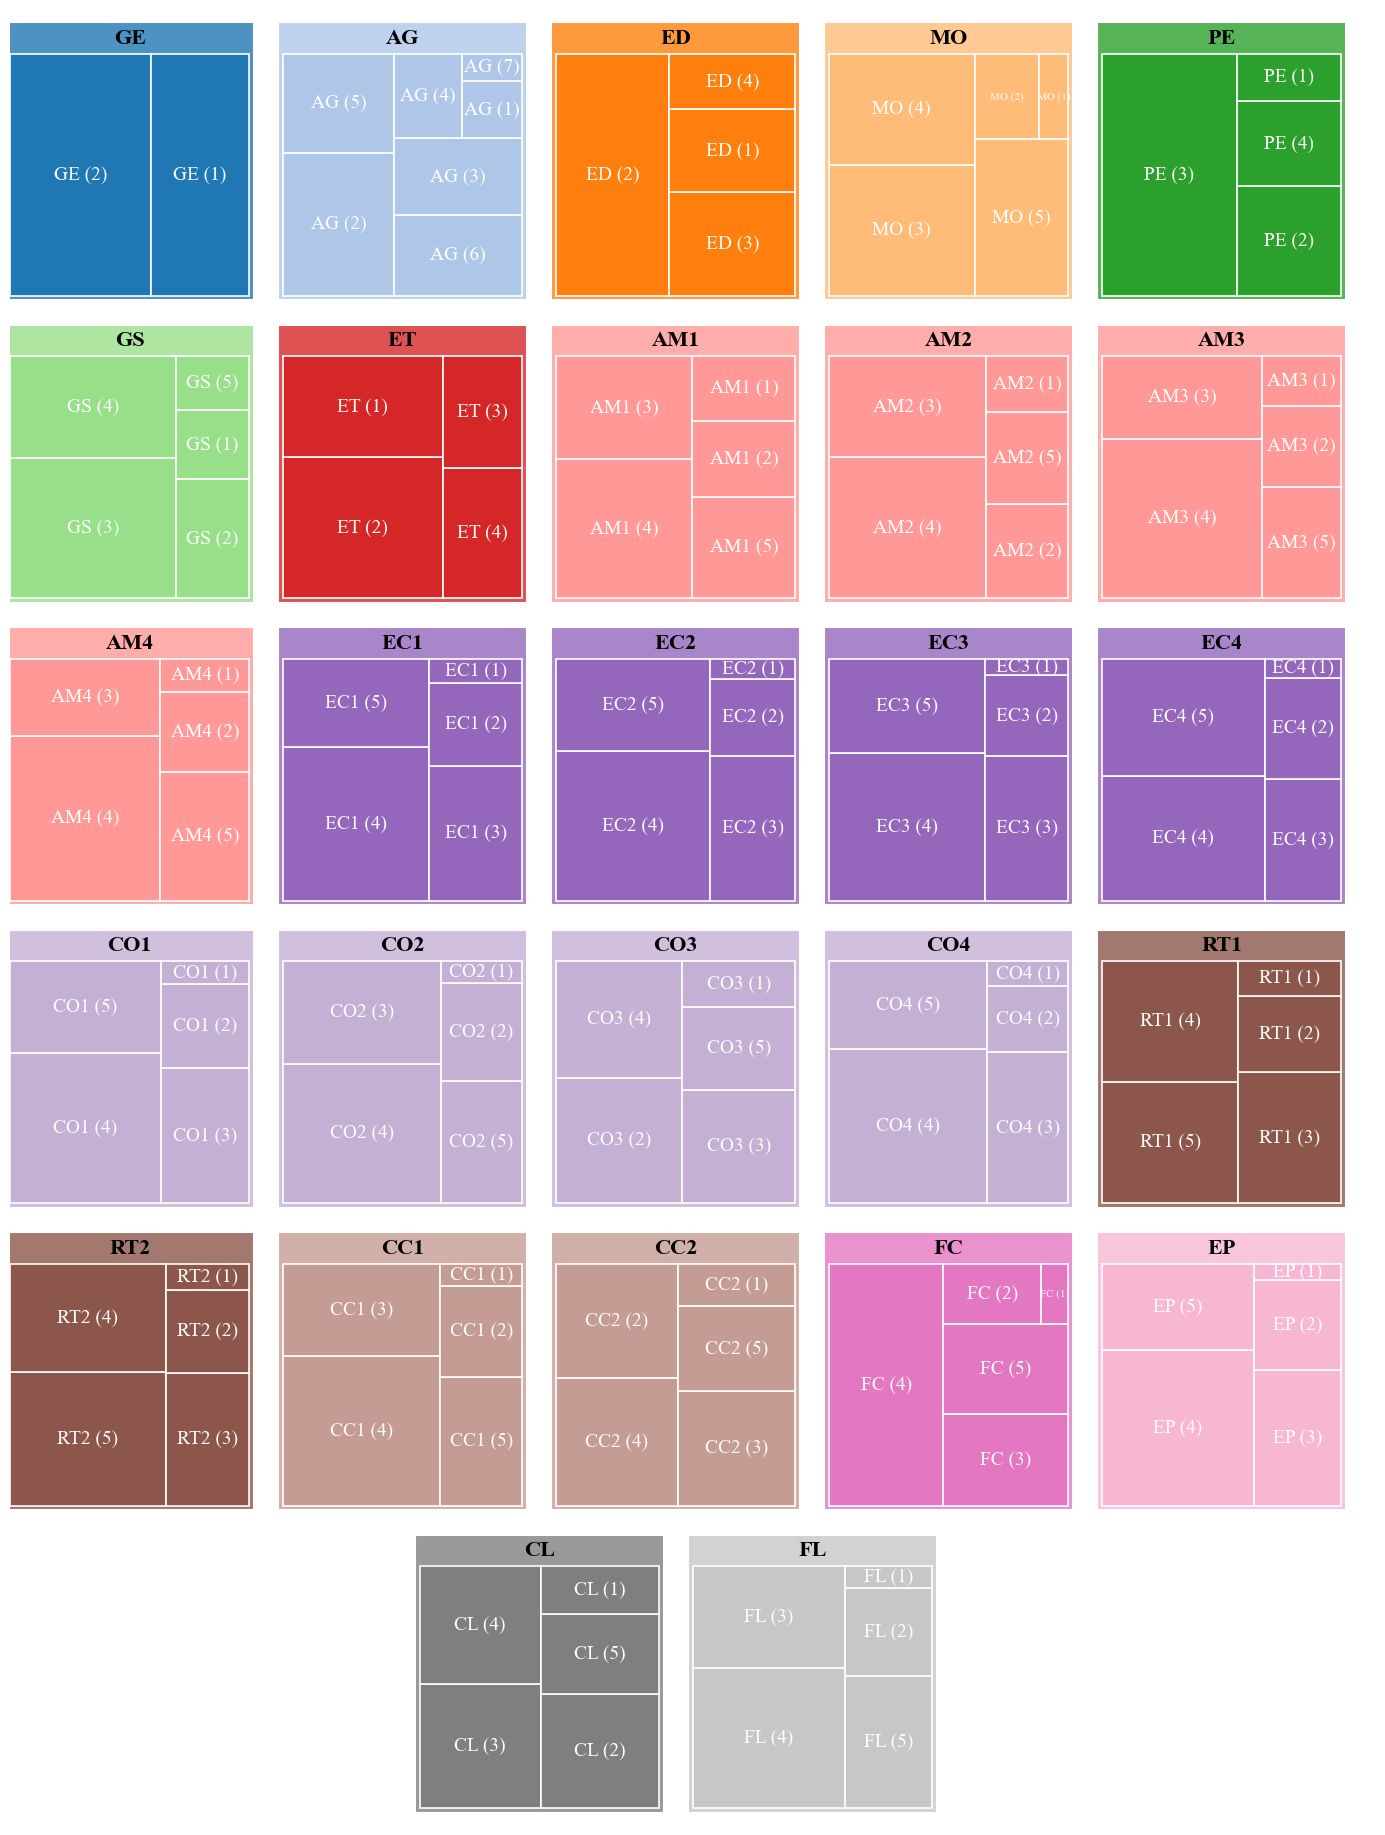

In [7]:
# ===== seaborn 调色板 =====
base_palette = sns.color_palette("tab20", 20)

# ===== 定义分组前缀 =====
group_prefixes = ['AM', 'EC', 'CO', 'RT', 'CC']

# ===== 建立前缀颜色映射 =====
unique_prefixes = []
for v in summary_df['Variable'].unique():
    prefix = next((p for p in group_prefixes if v.startswith(p)), v)
    if prefix not in unique_prefixes:
        unique_prefixes.append(prefix)

# 按顺序给颜色（够用会循环）
prefix_color_map = {
    prefix: base_palette[i % len(base_palette)]
    for i, prefix in enumerate(unique_prefixes)
}

# ===== 颜色分配函数 =====
def get_color(var):
    prefix = next((p for p in group_prefixes if var.startswith(p)), var)
    return prefix_color_map[prefix]

summary_df['Color'] = summary_df['Variable'].apply(get_color)

# ===== 绘图参数 =====
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20

variables = summary_df['Variable'].unique()
cols = 5   # 每行改为4列
rows = math.ceil(len(variables) / cols)
box_size = 1.0
bg_extra_height = 0.11
gap = 0.14
bg_pad = 0.02
unit_h = box_size + bg_extra_height + gap
unit_w = box_size + gap
fig_width = cols * unit_w
fig_height = rows * unit_h

fig, ax = plt.subplots(figsize=(fig_width * 2.5, fig_height * 2.5))
ax.set_xlim(0, fig_width)
ax.set_ylim(0, fig_height)
ax.axis('off')

def lighten_color(color, amount=0.7):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * amount for x in c)

# ===== 绘制每个大方块 =====
for idx, var in enumerate(variables):
    r = idx // cols
    c = idx % cols

    # 最后一行如果不满4个，居中显示
    if r == rows - 1 and (len(variables) % cols) != 0:
        remaining = len(variables) % cols
        start_c = (cols - remaining) / 2
        c = start_c + (idx % cols)

    sub = summary_df[summary_df['Variable'] == var]
    main_color = sub['Color'].iloc[0]
    bg_color = lighten_color(main_color, 0.8)

    x0 = c * unit_w
    y0 = fig_height - (r + 1) * unit_h + gap / 2

    # 背景块
    ax.add_patch(plt.Rectangle(
        (x0 - bg_pad, y0 - bg_pad),
        box_size + 2 * bg_pad,
        box_size + bg_extra_height + 2 * bg_pad,
        color=bg_color,
        ec='white', lw=1.5, zorder=0
    ))

    # 小矩形区
    values = sub['Count'].tolist()
    rects = squarify.squarify(
        squarify.normalize_sizes(values, box_size, box_size),
        x=x0, y=y0, dx=box_size, dy=box_size
    )

    for i, rect in enumerate(rects):
        ax.add_patch(plt.Rectangle(
            (rect['x'], rect['y']),
            rect['dx'], rect['dy'],
            color=main_color,
            ec='white', lw=1.2, zorder=1
        ))
        cx = rect['x'] + rect['dx'] / 2
        cy = rect['y'] + rect['dy'] / 2
        label_text = sub.iloc[i]['Label']
        small_labels = ["FC (1)", "MO (1)", "MO (2)"]
        font_size = 8 if label_text in small_labels else 14
        
        ax.text(cx, cy, label_text,
                ha='center', va='center',
                color='white', fontsize=font_size, zorder=2)

    ax.text(x0 + box_size / 2,
            y0 + box_size + 0.02,
            var, ha='center', va='bottom',
            fontsize=16, fontweight='bold',
            color='black', zorder=3)

plt.tight_layout()

# ===== 保存输出 =====
output_path = r"D:\论文数据\2025.10 出口选择\矩形树图\treemap_output_4cols.png"
plt.savefig(output_path, dpi=1200, bbox_inches='tight')
print(f"图像已保存到：{output_path}")

plt.show()


Category counts:
 Category
Demographic                  31
Pre-evacuation behavior      20
Exit choice behavior         20
Congestion behavior          20
Motivated return behavior    10
Competitive behavior         10
Group behavior               10
Other evacuation behavior    10
Name: count, dtype: int64


C:\Users\yuan yiquan\AppData\Local\Temp\ipykernel_79580\1009637387.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")


图像已保存到：D:\论文数据\2025.10 出口选择\矩形树图\treemap.png


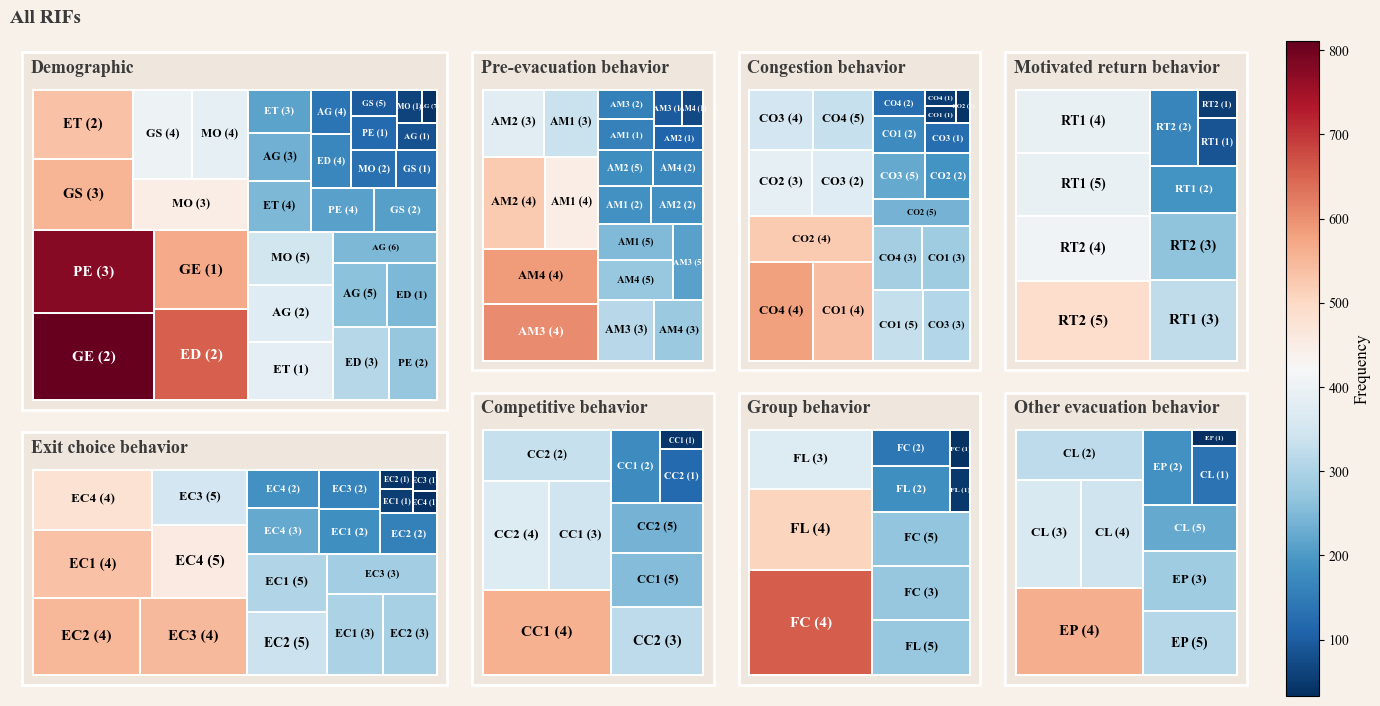

In [36]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import squarify

# ======================================================
# 0) 输入：summary_df 必须包含 Variable / Label / Count
# ======================================================
df = summary_df.copy()
need_cols = {"Variable", "Label", "Count"}
miss = need_cols - set(df.columns)
if miss:
    raise ValueError(f"summary_df 缺少列: {miss}")

df["Count"] = pd.to_numeric(df["Count"], errors="coerce").fillna(0)
df = df[df["Count"] > 0].copy()

# ======================================================
# 1) 8 块分类映射（返回值必须与 layout 的 key 完全一致）
# ======================================================
demographic_vars = {"GE", "AG", "ED", "MO", "PE", "GS", "ET"}
pre_vars = {"AM1", "AM2", "AM3", "AM4"}
exit_choice_vars = {"EC1", "EC2", "EC3", "EC4"}
cong_vars = {"CO1", "CO2", "CO3", "CO4"}
return_vars = {"RT1", "RT2"}
competitive_vars = {"CC1", "CC2"}
group_vars = {"FC", "FL"}
other_vars = {"CL", "EP"}

# ★ 统一的 8 块名称（和 layout key 一致）
CAT_DEMO = "Demographic"
CAT_PRE  = "Pre-evacuation behavior"
CAT_EXIT = "Exit choice behavior"
CAT_CONG = "Congestion behavior"
CAT_RET  = "Motivated return behavior"
CAT_COMP = "Competitive behavior"
CAT_GROUP= "Group behavior"
CAT_OTHER= "Other evacuation behavior"

def assign_cat8(var: str) -> str:
    v = str(var).strip()
    if v in demographic_vars:   return CAT_DEMO
    if v in pre_vars:           return CAT_PRE
    if v in exit_choice_vars:   return CAT_EXIT
    if v in cong_vars:          return CAT_CONG
    if v in return_vars:        return CAT_RET
    if v in competitive_vars:   return CAT_COMP
    if v in group_vars:         return CAT_GROUP
    if v in other_vars:         return CAT_OTHER
    return "Unmapped"

df["Category"] = df["Variable"].apply(assign_cat8)
df = df[df["Category"] != "Unmapped"].copy()

print("Category counts:\n", df["Category"].value_counts())

# ======================================================
# 2) 颜色映射（保持你当前发散色图）
# ======================================================
vmin, vmax = df["Count"].min(), df["Count"].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("RdBu_r")
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# ======================================================
# 3) 文字颜色与字号：深色白字 + 小块字更小（但全部都标注）
# ======================================================
def auto_text_color(rgba, threshold=0.62):
    r, g, b, _ = rgba
    luminance = 0.2126*r + 0.7152*g + 0.0722*b
    return "black" if luminance > threshold else "white"

def fontsize_from_geom(dx, dy, fs_min=4.5, fs_max=11.0):
    m = min(dx, dy)
    fs = fs_min + (fs_max - fs_min) * np.clip((m - 1.0) / 7.0, 0, 1)
    return float(fs)

# ======================================================
# 4) 混合 treemap：高层二分聚左 + 分区内 squarify 避免细条
# ======================================================
def split_by_half(items):
    total = sum(it["value"] for it in items)
    half = total / 2.0
    acc = 0.0
    cut = 1
    for i, it in enumerate(items):
        acc += it["value"]
        if acc >= half:
            cut = i + 1
            break
    cut = max(1, min(cut, len(items)-1))
    return items[:cut], items[cut:]

def squarify_rects(items, x, y, dx, dy):
    vals = [it["value"] for it in items]
    rects = squarify.squarify(
        squarify.normalize_sizes(vals, dx, dy),
        x=x, y=y, dx=dx, dy=dy
    )
    out = []
    for r, it in zip(rects, items):
        out.append(dict(x=r["x"], y=r["y"], dx=r["dx"], dy=r["dy"],
                        label=it["label"], value=it["value"]))
    return out

def hybrid_treemap(items, x, y, dx, dy, depth=2, horizontal=True):
    if not items:
        return []
    if len(items) <= 6 or depth <= 0:
        return squarify_rects(items, x, y, dx, dy)

    items = sorted(items, key=lambda d: d["value"], reverse=True)
    left, right = split_by_half(items)
    total = sum(it["value"] for it in items)
    sum_left = sum(it["value"] for it in left)

    rects = []
    if horizontal:
        w_left = dx * (sum_left / total)
        rects += hybrid_treemap(left,  x,         y, w_left,       dy, depth=depth-1, horizontal=False)
        rects += hybrid_treemap(right, x+w_left,  y, dx-w_left,    dy, depth=depth-1, horizontal=False)
    else:
        h_bot = dy * (sum_left / total)
        rects += hybrid_treemap(left,  x, y,        dx, h_bot,     depth=depth-1, horizontal=True)
        rects += hybrid_treemap(right, x, y+h_bot,  dx, dy-h_bot,  depth=depth-1, horizontal=True)

    return rects

# ======================================================
# 5) 固定 8 块布局（整齐版式）
# ======================================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

W, H = 120, 70
FIG_BG = "#f7f1ea"
CAT_BG = "#efe6dd"

PAD_OUT = 1.2
PAD_IN  = 1.0
TITLE_H = 3.0
LW_CAT  = 2.0
LW_LEAF = 1.4

left_w  = 0.36 * W
right_w = W - left_w

demo_h = 0.58 * H
exit_h = H - demo_h

top_h = 0.52 * H
bot_h = H - top_h

top_cell_w = right_w / 3
bot_cell_w = right_w / 3

layout = {
    CAT_DEMO: (0,           H - demo_h, left_w,  demo_h),
    CAT_EXIT: (0,           0,          left_w,  exit_h),

    CAT_PRE:  (left_w + 0*top_cell_w, H - top_h, top_cell_w, top_h),
    CAT_CONG: (left_w + 1*top_cell_w, H - top_h, top_cell_w, top_h),
    CAT_RET:  (left_w + 2*top_cell_w, H - top_h, top_cell_w, top_h),

    CAT_COMP:  (left_w + 0*bot_cell_w, 0, bot_cell_w, bot_h),
    CAT_GROUP: (left_w + 1*bot_cell_w, 0, bot_cell_w, bot_h),
    CAT_OTHER: (left_w + 2*bot_cell_w, 0, bot_cell_w, bot_h),
}

# ======================================================
# 6) 绘制一个 block（混合 treemap + 全部标注）
# ======================================================
def draw_block(ax, cat, x, y, dx, dy, depth=2):
    sub = df[df["Category"] == cat].copy()
    if sub.empty:
        ax.text(x + 2, y + dy/2, f"[EMPTY] {cat}", color="red", fontsize=14, fontweight="bold")
        return

    # 外框 + 背景
    cx, cy = x + PAD_OUT, y + PAD_OUT
    cdx, cdy = max(dx - 2*PAD_OUT, 1e-6), max(dy - 2*PAD_OUT, 1e-6)

    ax.add_patch(plt.Rectangle(
        (cx, cy), cdx, cdy,
        facecolor=CAT_BG,
        edgecolor="white",
        linewidth=LW_CAT,
        zorder=0
    ))

    # 标题
    ax.text(cx + 0.8, cy + cdy - 0.8, cat,
            ha="left", va="top",
            fontsize=13, fontweight="bold",
            color="#3a3a3a", zorder=3)

    # 叶子区域（扣标题）
    leaf_x = cx + PAD_IN
    leaf_y = cy + PAD_IN
    leaf_dx = max(cdx - 2*PAD_IN, 1e-6)
    leaf_dy = max(cdy - TITLE_H - 2*PAD_IN, 1e-6)

    sub = sub.sort_values("Count", ascending=False).reset_index(drop=True)
    items = [{"label": sub.loc[i, "Label"], "value": float(sub.loc[i, "Count"])}
             for i in range(len(sub))]

    rects = hybrid_treemap(items, leaf_x, leaf_y, leaf_dx, leaf_dy, depth=depth, horizontal=True)

    for rct in rects:
        label = rct["label"]
        val = rct["value"]

        facecolor = cmap(norm(val))
        ax.add_patch(plt.Rectangle(
            (rct["x"], rct["y"]), rct["dx"], rct["dy"],
            facecolor=facecolor,
            edgecolor="white",
            linewidth=LW_LEAF,
            zorder=1
        ))

        fs = fontsize_from_geom(rct["dx"], rct["dy"])
        txt_color = auto_text_color(facecolor)

        ax.text(
            rct["x"] + rct["dx"]/2,
            rct["y"] + rct["dy"]/2,
            label,
            ha="center", va="center",
            fontsize=fs,
            color=txt_color,
            fontweight="bold",
            zorder=2,
            clip_on=True
        )

# ======================================================
# 7) 画整图
# ======================================================
fig, ax = plt.subplots(figsize=(14, 7.2))
fig.patch.set_facecolor(FIG_BG)
ax.set_facecolor(FIG_BG)
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.axis("off")

ax.text(0, H + 1.5, "All RIFs", ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#3a3a3a")

for cat in layout:
    x, y, dx, dy = layout[cat]
    draw_block(ax, cat, x, y, dx, dy, depth=2)

cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Frequency", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
# ===== 保存输出 =====
output_path = r"D:\论文数据\2025.10 出口选择\矩形树图\treemap.png"
plt.savefig(output_path, dpi=600, bbox_inches='tight')
print(f"图像已保存到：{output_path}")
plt.show()
'''

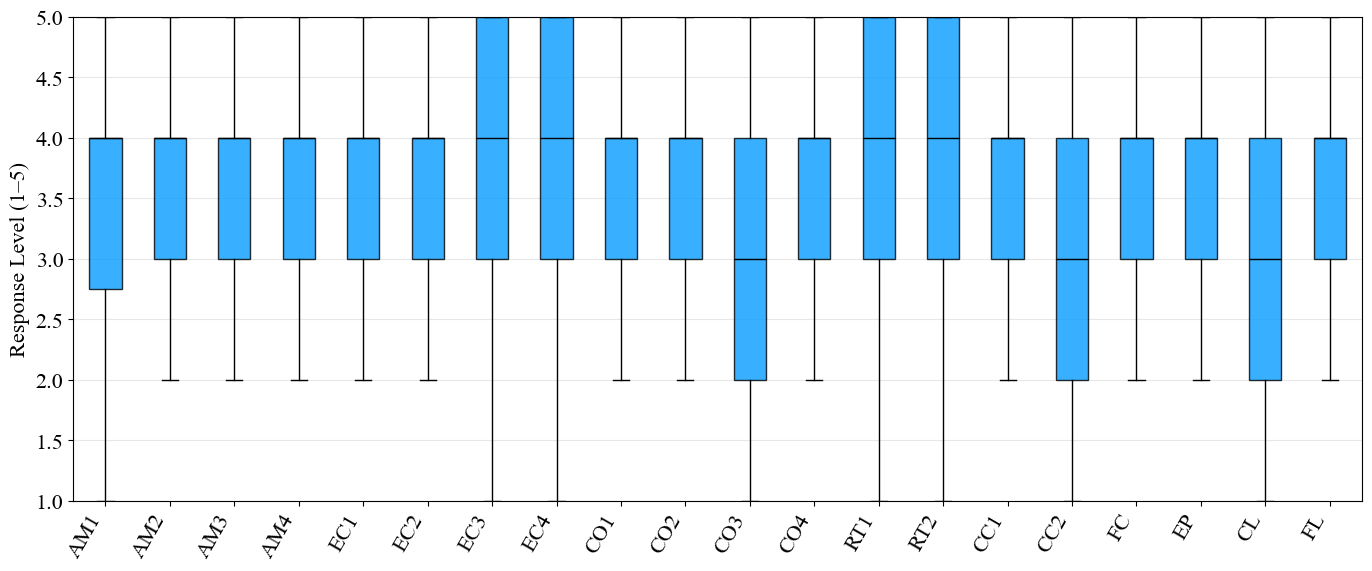

箱线图已保存至：D:\论文数据\2025.10 出口选择\RMSE\Questionnaire_Boxplot.png


In [82]:
cols_to_drop = ['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET']
data1 = df.drop(columns=cols_to_drop)

save_dir = r"D:\论文数据\2025.10 出口选择\RMSE"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "Questionnaire_Boxplot.png")

plt.figure(figsize=(14, 6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.boxplot(
    [data1[col].dropna() for col in data1.columns],  # ✅ 用 data1.columns
    labels=data1.columns,                            # ✅ 一致
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color='black'),
    boxprops=dict(facecolor='#069DFF', alpha=0.8),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.xticks(rotation=60, ha='right')
plt.ylim(1, 5)
plt.ylabel("Response Level (1–5)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(save_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"箱线图已保存至：{save_path}")

In [8]:
print(df.columns.tolist())

['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET', 'AM1', 'AM2', 'AM3', 'AM4', 'EC1', 'EC2', 'EC3', 'EC4', 'CO1', 'CO2', 'CO3', 'CO4', 'RT1', 'RT2', 'CC1', 'CC2', 'FC', 'EP', 'CL', 'FL']


In [6]:
# =======================
# 数据预处理
# =======================
# 前部变量（行为与心理因素）
front_vars = ['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET', 'AM1', 'AM2', 'AM3', 'AM4', 
              'CO1', 'CO2', 'CO3', 'CO4', 'RT1', 'RT2', 'CC1', 'CC2', 'FC', 'EP', 'CL', 'FL']

# 后部变量（出口选择行为）
exit_vars = ['EC1', 'EC2', 'EC3', 'EC4']

In [7]:
# 计算互信息
mi_scores = {}
for exit_var in exit_vars:
    mi = mutual_info_classif(df[front_vars], df[exit_var], discrete_features='auto')
    mi_scores[exit_var] = dict(zip(front_vars, mi))

# 转换为DataFrame
mi_df = pd.DataFrame(mi_scores)

# 计算每个前部变量的平均影响力
mi_df["Mean_MI"] = mi_df.mean(axis=1)

# 按影响力排序
mi_df_sorted = mi_df.sort_values(by="Mean_MI", ascending=False)

print(mi_df_sorted)

          EC1       EC2       EC3       EC4   Mean_MI
AM4  0.291243  0.205968  0.163591  0.140767  0.200392
AM3  0.211056  0.210287  0.158472  0.117881  0.174424
CO1  0.121579  0.098264  0.182031  0.271439  0.168328
AM2  0.217481  0.144211  0.159961  0.130817  0.163117
AM1  0.173540  0.126876  0.113845  0.127817  0.135519
CO4  0.150963  0.123680  0.096681  0.138196  0.127380
CO2  0.074890  0.102039  0.101951  0.100313  0.094798
CO3  0.079837  0.051634  0.052658  0.096312  0.070110
CC1  0.057445  0.077926  0.059085  0.035115  0.057393
FC   0.052800  0.061379  0.054366  0.052901  0.055361
RT2  0.031012  0.099173  0.037487  0.047553  0.053806
RT1  0.054261  0.080790  0.035269  0.031656  0.050494
CC2  0.073264  0.035801  0.031143  0.058905  0.049778
EP   0.029701  0.075276  0.046065  0.037012  0.047014
CL   0.027064  0.020142  0.032998  0.065854  0.036514
GS   0.045203  0.059011  0.019466  0.001261  0.031235
ET   0.022463  0.023356  0.033673  0.000000  0.019873
ED   0.000000  0.015771  0.0

# 3.集成机器学习

<span style="font-size:20px; color:blue">数据处理</span>

In [8]:
# 控制变量
Control_vars = ['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET']

# 处理变量
Treatment_vars = ['AM1', 'AM2', 'AM3', 'AM4', 'CO1', 'CO2', 'CO3', 'CO4', 'RT1', 'RT2', 'CC1', 'CC2', 'FC', 'EP', 'CL', 'FL']

# 结果变量（出口选择行为）
Outcome_vars1 = ['EC1']
Outcome_vars2 = ['EC2']
Outcome_vars3 = ['EC3']
Outcome_vars4 = ['EC4']

In [9]:
'''
随机森林（RF）、极端梯度提升（XGBoost）、轻量级梯度提升机（LightGBM）、梯度提升决策树（GBDT）、
自适应提升（AdaBoost）、支持向量机（SVM）、神经网络（NN）、决策树（DT）和线性回归（LR）
'''

'\n随机森林（RF）、极端梯度提升（XGBoost）、轻量级梯度提升机（LightGBM）、梯度提升决策树（GBDT）、\n自适应提升（AdaBoost）、支持向量机（SVM）、神经网络（NN）、决策树（DT）和线性回归（LR）\n'

<span style="font-size:30px; color:red">模型训练</span>

In [10]:
# ======================
# 提取变量
# ======================
all_vars= Treatment_vars+ Control_vars

X = df[all_vars]
y1 = df[Outcome_vars1[0]]
y2 = df[Outcome_vars2[0]]
y3 = df[Outcome_vars3[0]]
y4 = df[Outcome_vars4[0]]

# ======================
# 划分训练集与测试集
# ======================
X_train, X_test, y_train1, y_test1 = train_test_split(
    X, y1, test_size=0.2, random_state=42
)

# 其他三个结果变量基于同样的索引切分
# 以保证 4 个任务拥有完全一致的训练/测试样本

y_train2 = y2.loc[X_train.index]
y_test2  = y2.loc[X_test.index]

y_train3 = y3.loc[X_train.index]
y_test3  = y3.loc[X_test.index]

y_train4 = y4.loc[X_train.index]
y_test4  = y4.loc[X_test.index]

In [11]:
task_list = [
    ("Task1", y_train1, y_test1),
    ("Task2", y_train2, y_test2),
    ("Task3", y_train3, y_test3),
    ("Task4", y_train4, y_test4),
]


In [12]:
# === 自定义模型：Locally Weighted Regression（LWR）===
class LocallyWeightedRegression:
    def __init__(self, tau=0.5):
        self.tau = tau

    def fit(self, X, y):
        self.X = X
        self.y = y
        return self

    def predict(self, X_test):
        preds = []
        for x in X_test:
            w = np.exp(-np.sum((self.X - x)**2, axis=1) / (2 * self.tau**2))
            W = np.diag(w)
            try:
                theta = np.linalg.inv(self.X.T @ W @ self.X) @ self.X.T @ W @ self.y
                preds.append(x @ theta)
            except:
                preds.append(np.average(self.y, weights=w))
        return np.array(preds)

# === 自定义模型：Residual FC Network（带残差结构）===
class ResidualFCN:
    def __init__(self, hidden=64, epochs=200, lr=0.001):
        self.hidden = hidden
        self.epochs = epochs
        self.lr = lr

    def fit(self, X, y):
        self.model = MLPRegressor(
            hidden_layer_sizes=(self.hidden, self.hidden),
            max_iter=self.epochs,
            learning_rate_init=self.lr
        )
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)


# === 自定义模型：BP Neural Network（MLP 等价替代）===
class BPNeuralNetwork(MLPRegressor):
    pass

<span style="font-size:30px; color:green">负相关学习</span>

In [13]:
SEED = 42

models = {

    "LR": (
        LinearRegression(),
        {}
    ),

    "OMP": (
        OrthogonalMatchingPursuit(),
        {"n_nonzero_coefs": [None, 5, 10]}
    ),

    "SVR": (
        SVR(),
        {
            "C": [1, 5, 10],
            "epsilon": [0.05, 0.1],
            "kernel": ["rbf"]
        }
    ),

    "KR": (
        KernelRidge(),
        {
            "alpha": [0.1, 1.0],
            "kernel": ["rbf"],
            "gamma": [0.01, 0.1]
        }
    ),

    "KNN": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    ),

    "RF": (
        RandomForestRegressor(
            random_state=SEED,
            n_jobs=1
        ),
        {
            "n_estimators": [200, 300],
            "max_depth": [None, 10],
            "max_features": ["sqrt"]
        }
    ),

    "ET": (
        ExtraTreesRegressor(
            random_state=SEED,
            n_jobs=1
        ),
        {
            "n_estimators": [200, 300],
            "max_depth": [None, 10]
        }
    ),

    "GBDT": (
        GradientBoostingRegressor(random_state=SEED),
        {
            "n_estimators": [200, 300],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    ),

    "XGB": (
        XGBRegressor(
            random_state=SEED,
            n_estimators=200,
            n_jobs=1,
            tree_method="hist",
            subsample=0.8,
            colsample_bytree=0.8,
            verbosity=0
        ),
        {
            "n_estimators": [200, 300],
            "max_depth": [4, 6],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8],
            "colsample_bytree": [0.8]
        }
    ),

    "LGBM": (
        LGBMRegressor(
            random_state=SEED,
            deterministic=True,
            force_col_wise=True,
            n_jobs=1
        ),
        {
            "n_estimators": [200, 400],
            "num_leaves": [31, 63],
            "learning_rate": [0.05],
            "subsample": [0.8]
        }
    ),

    "MLP": (
        MLPRegressor(
            max_iter=500,
            random_state=SEED
        ),
        {
            "hidden_layer_sizes": [(64,), (128, 64)],
            "learning_rate_init": [0.001, 0.01]
        }
    ),

    "BP": (
        BPNeuralNetwork(
            max_iter=500,
            random_state=SEED
        ),
        {
            "hidden_layer_sizes": [(64,), (128,)],
            "learning_rate_init": [0.001, 0.01]
        }
    ),

    "RFCN": (
        ResidualFCN(),
        {
            "hidden": [32, 64],
            "epochs": [200],
            "lr": [0.001, 0.005]
        }
    )
}


In [14]:
# ==========================================================
# 0) 全局确定性设置（必须在训练前执行）
# ==========================================================
SEED = 114514

os.environ["PYTHONHASHSEED"] = str(SEED)

# 强制底层线性代数单线程，避免浮点并行导致的微漂
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

random.seed(SEED)
np.random.seed(SEED)

# ---- PyTorch 确定性（如果你 BP/RFCN 用 PyTorch）----
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
except Exception:
    pass

# ---- TensorFlow 确定性（如果你 BP/RFCN 用 TF/Keras）----
try:
    import tensorflow as tf
    try:
        tf.keras.utils.set_random_seed(SEED)
    except Exception:
        pass
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass
except Exception:
    pass


# ==========================================================
# 1) 工具：尽量把一个模型“锁死”为确定性
# ==========================================================
def make_model_deterministic(mdl, seed=42):
    """
    尽最大努力让模型训练可复现：
    - 设 random_state / seed
    - 设单线程 n_jobs / num_threads / nthread
    - 调用可能存在的自定义 set_seed 等接口
    """
    # 1) random_state
    if hasattr(mdl, "random_state"):
        try:
            mdl.set_params(random_state=seed)
        except Exception:
            try:
                setattr(mdl, "random_state", seed)
            except Exception:
                pass

    # 2) 单线程（sklearn / xgb / lgbm 的常见参数）
    try:
        params = mdl.get_params()
        for p in ["n_jobs", "num_threads", "nthread"]:
            if p in params:
                try:
                    mdl.set_params(**{p: 1})
                except Exception:
                    pass
    except Exception:
        pass

    # 3) 兜底（能设则设）
    for key, val in [("verbosity", 0), ("silent", 1)]:
        try:
            if key in mdl.get_params():
                mdl.set_params(**{key: val})
        except Exception:
            pass

    # 4) 自定义模型：尝试常见 seed 接口
    for fn_name in ["set_seed", "seed_everything", "set_random_state", "set_rng"]:
        if hasattr(mdl, fn_name):
            try:
                getattr(mdl, fn_name)(seed)
            except Exception:
                pass

    # 5) 自定义模型：如果有属性 seed / random_state
    for attr in ["seed", "random_state"]:
        if hasattr(mdl, attr):
            try:
                setattr(mdl, attr, seed)
            except Exception:
                pass

    return mdl


# ==========================================================
# 2) ✅ 导出路径：D:\论文数据\2025.10 出口选择\
# ==========================================================
OUT_DIR = r"D:\论文数据\2025.10 出口选择"
os.makedirs(OUT_DIR, exist_ok=True)


# ==========================================================
# 3) ✅ 先把 models 里的“超参数空间”整理成表（写 Excel 用）
# ==========================================================
base_param_rows = []
for model_name, (model_obj, param_grid) in models.items():
    if not param_grid:
        base_param_rows.append({
            "Model": model_name,
            "Hyperparameter": "(none)",
            "Candidates": "(default)"
        })
    else:
        for p, v in param_grid.items():
            base_param_rows.append({
                "Model": model_name,
                "Hyperparameter": p,
                "Candidates": str(v)
            })
base_params_df = pd.DataFrame(base_param_rows)


# ==========================================================
# 4) 主循环（完全可复现版 + 导出 λ/γ + 导出模型超参数空间）
# ==========================================================
from sklearn.metrics import mean_squared_error
import shap

task_outputs = {}
best_rows = []   # 汇总每个 task 的最优超参数（写 Excel）

# ★ 强制任务顺序固定
task_list_ordered = list(task_list)

# ★ 强制模型顺序固定（按 models 的键顺序）
model_names_ordered = list(models.keys())

for task_name, y_train, y_test in task_list_ordered:
    print("\n==============================")
    print(f"🔥 当前任务：{task_name}")
    print("==============================")

    # ===============================
    # 1. 训练所有模型（确定性）
    # ===============================
    predictions = {}
    rmse_dict = {}
    model_objects = {}

    for name in model_names_ordered:
        model, params = models[name]
        mdl = copy.deepcopy(model)
        mdl = make_model_deterministic(mdl, seed=SEED)

        try:
            mdl.fit(X_train, y_train)
            pred = mdl.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, pred))

            predictions[name] = pred
            rmse_dict[name] = rmse
            model_objects[name] = mdl

            print(f"{name:20s} | RMSE = {rmse:.4f}")

        except Exception as e:
            print(f"{name:20s} ❌ FAILED: {e}")

    # ===============================
    # 2. 多样性矩阵（固定顺序）
    # ===============================
    model_names = [m for m in model_names_ordered if m in predictions]
    n = len(model_names)

    div_matrix = pd.DataFrame(
        np.zeros((n, n)),
        index=model_names,
        columns=model_names
    )

    for i in range(n):
        pi = predictions[model_names[i]]
        for j in range(n):
            pj = predictions[model_names[j]]
            div_matrix.iloc[i, j] = np.mean((pi - pj) ** 2)

    avg_diversity = div_matrix.mean(axis=1).to_dict()

    task_outputs[task_name] = {
        "DiversityMatrix": div_matrix,
        "model_objects": model_objects,
        "rmse_dict": rmse_dict,
        "predictions": predictions,
        "y_test": y_test
    }

    # ===============================
    # 3. 模型排序（确定性：同RMSE再按 diversity，再按名字）
    # ===============================
    model_order = sorted(
        model_names,
        key=lambda m: (rmse_dict[m], -avg_diversity[m], m)
    )
    print("model_order:", model_order)

    # =====================================================
    # 4) EL stacking（基于 RMSE 加权）
    # =====================================================
    selected_for_EL = model_order
    pred_matrix = np.column_stack([predictions[m] for m in selected_for_EL])

    rmse_vals_EL = np.array([rmse_dict[m] for m in selected_for_EL])
    w_EL = 1 / (rmse_vals_EL + 1e-8)
    w_EL = w_EL / w_EL.sum()

    EL_pred = pred_matrix.dot(w_EL)
    EL_rmse = np.sqrt(np.mean((y_test - EL_pred) ** 2))
    EL_std = np.std(y_test - EL_pred)

    task_outputs[task_name]["EL_pred"] = EL_pred
    task_outputs[task_name]["EL_rmse"] = EL_rmse
    task_outputs[task_name]["EL_std"] = EL_std
    task_outputs[task_name]["EL_weights"] = w_EL

    print(f"EL stacking RMSE = {EL_rmse:.4f}")
    print(f"EL stacking STD  = {EL_std:.4f}")

    # ===============================
    # 5) λ–γ 精细网格搜索（NCL stacking）
    # ===============================
    lambda_list = np.linspace(0, 1, 1000)
    gamma_list = list(range(4, len(model_order)))

    rmse_matrix = np.zeros((len(lambda_list), len(gamma_list)))

    best_rmse = np.inf
    best_lambda = None
    best_gamma = None

    for la_idx, la in enumerate(lambda_list):
        for g_idx, g in enumerate(gamma_list):
            selected = model_order[:g]

            w = [ (1 - la) * (1 / (rmse_dict[m] + 1e-8)) + la * avg_diversity[m]
                  for m in selected ]
            w = np.array(w, dtype=float)
            w = w / w.sum()

            blend = sum(w[k] * predictions[selected[k]] for k in range(g))
            rmse = np.sqrt(np.mean((y_test - blend) ** 2))
            rmse_matrix[la_idx, g_idx] = rmse

            # ★ rmse 平局时用更小 gamma、更小 lambda 打破（避免漂）
            if (rmse < best_rmse - 1e-12) or (
                abs(rmse - best_rmse) <= 1e-12 and (g < best_gamma or (g == best_gamma and la < best_lambda))
            ):
                best_rmse = rmse
                best_lambda = la
                best_gamma = g

    task_outputs[task_name]["lambda_vals"] = lambda_list
    task_outputs[task_name]["gamma_vals"] = gamma_list
    task_outputs[task_name]["rmse_matrix"] = rmse_matrix

    # ============================================================
    # 6) SHAP + stacking 信息（尽量确定性）
    # ============================================================
    selected_models = model_order[:best_gamma]
    meta_features = np.column_stack([predictions[m] for m in selected_models])

    acc = np.array([1 / (rmse_dict[m] + 1e-8) for m in selected_models], dtype=float)
    div = np.array([avg_diversity[m] for m in selected_models], dtype=float)
    raw_w = (1 - best_lambda) * acc + best_lambda * div
    weights = raw_w / raw_w.sum()

    def stacking_predict_from_meta(meta_X):
        return np.dot(meta_X, weights)

    try:
        explainer = shap.LinearExplainer(stacking_predict_from_meta, meta_features)
        shap_values = explainer(meta_features)
        shap_arr = shap_values.values if hasattr(shap_values, "values") else np.array(shap_values)
    except Exception:
        explainer = shap.Explainer(stacking_predict_from_meta, meta_features)
        shap_values = explainer(meta_features)
        shap_arr = shap_values.values if hasattr(shap_values, "values") else np.array(shap_values)

    importance = np.abs(shap_arr).mean(axis=0)

    task_outputs[task_name]["selected_models"] = selected_models
    task_outputs[task_name]["meta_features"] = meta_features
    task_outputs[task_name]["weights"] = weights
    task_outputs[task_name]["importance"] = importance

    # ============================================================
    # 7) 最终 NCL stacking 预测
    # ============================================================
    NCL_pred = meta_features.dot(weights)
    NCL_rmse = np.sqrt(np.mean((y_test - NCL_pred) ** 2))
    NCL_std = np.std(y_test - NCL_pred)

    task_outputs[task_name]["NCL_pred"] = NCL_pred
    task_outputs[task_name]["NCL_rmse"] = NCL_rmse
    task_outputs[task_name]["NCL_std"] = NCL_std
    task_outputs[task_name]["NCL_weights"] = weights

    # ============================================================
    # ✅ 8) 汇总最优超参数（写 Excel）
    # ============================================================
    best_rows.append({
        "Task": task_name,
        "Best_lambda": float(best_lambda),
        "Best_gamma": int(best_gamma),
        "Best_RMSE": float(best_rmse),
        "EL_RMSE": float(EL_rmse),
        "NCL_RMSE": float(NCL_rmse),
        "Num_models_total": int(len(model_order)),
        "Selected_models": ", ".join(selected_models)
    })

    print("\n==============================")
    print(f"⭐ {task_name} 最优 stacking 结果")
    print("==============================")
    print("最佳 λ =", best_lambda)
    print("最佳 γ =", best_gamma)
    print("最低 RMSE =", best_rmse)
    print("==============================\n")




# ==========================================================
# ✅ 9) 输出 Excel：最优 λ/γ + 基模型超参数空间（同一个文件两个 Sheet）
# ==========================================================
best_df = pd.DataFrame(best_rows)

save_path = os.path.join(OUT_DIR, "Best_Hyperparameters_and_ModelSpaces.xlsx")
with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    best_df.to_excel(writer, sheet_name="Best_NCL_Parameters", index=False)
    base_params_df.to_excel(writer, sheet_name="Base_Model_Hyperparameters", index=False)

print(f"\n✅ 已输出完整超参数信息：{save_path}")



🔥 当前任务：Task1
LR                   | RMSE = 0.8204
OMP                  | RMSE = 0.8330
SVR                  | RMSE = 0.7636
KR                   | RMSE = 0.8229
KNN                  | RMSE = 0.7992
RF                   | RMSE = 0.7677
ET                   | RMSE = 0.7657
GBDT                 | RMSE = 0.7854
XGB                  | RMSE = 0.8095
[LightGBM] [Info] Total Bins 134
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 23
[LightGBM] [Info] Start training from score 3.642210
LGBM                 | RMSE = 0.8038
MLP                  | RMSE = 0.8367
BP                   | RMSE = 0.8367


D:\conda\envs\tf2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


RFCN                 | RMSE = 0.8067
model_order: ['SVR', 'ET', 'RF', 'GBDT', 'KNN', 'LGBM', 'RFCN', 'XGB', 'LR', 'KR', 'OMP', 'BP', 'MLP']
EL stacking RMSE = 0.7494
EL stacking STD  = 0.7479

⭐ Task1 最优 stacking 结果
最佳 λ = 1.0
最佳 γ = 8
最低 RMSE = 0.7435833581926314


🔥 当前任务：Task2
LR                   | RMSE = 0.8724
OMP                  | RMSE = 0.8861
SVR                  | RMSE = 0.8260
KR                   | RMSE = 0.8762
KNN                  | RMSE = 0.8361
RF                   | RMSE = 0.7970
ET                   | RMSE = 0.7861
GBDT                 | RMSE = 0.8205
XGB                  | RMSE = 0.8685
[LightGBM] [Info] Total Bins 134
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 23
[LightGBM] [Info] Start training from score 3.733696
LGBM                 | RMSE = 0.8203


D:\conda\envs\tf2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP                  | RMSE = 0.8706


...

RFCN                 | RMSE = 0.9053
model_order: ['ET', 'RF', 'LGBM', 'GBDT', 'SVR', 'KNN', 'XGB', 'BP', 'MLP', 'LR', 'KR', 'OMP', 'RFCN']
EL stacking RMSE = 0.7993
EL stacking STD  = 0.7981

⭐ Task2 最优 stacking 结果
最佳 λ = 1.0
最佳 γ = 6
最低 RMSE = 0.7861828996311223


🔥 当前任务：Task3
LR                   | RMSE = 0.9006
OMP                  | RMSE = 0.9511
SVR                  | RMSE = 0.8368
KR                   | RMSE = 0.9041
KNN                  | RMSE = 0.8458
RF                   | RMSE = 0.7983
ET                   | RMSE = 0.7884
GBDT                 | RMSE = 0.8334
XGB                  | RMSE = 0.7888
[LightGBM] [Info] Total Bins 134
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 23
[LightGBM] [Info] Start training from score 3.758152
LGBM                 | RMSE = 0.8255
MLP                  | RMSE = 0.9324
BP                   | RMSE = 0.9324


D:\conda\envs\tf2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


RFCN                 | RMSE = 0.8806
model_order: ['ET', 'XGB', 'RF', 'LGBM', 'GBDT', 'SVR', 'KNN', 'RFCN', 'LR', 'KR', 'BP', 'MLP', 'OMP']
EL stacking RMSE = 0.8088
EL stacking STD  = 0.8068

⭐ Task3 最优 stacking 结果
最佳 λ = 1.0
最佳 γ = 4
最低 RMSE = 0.7723403211188347


🔥 当前任务：Task4
LR                   | RMSE = 0.7860
OMP                  | RMSE = 0.8837
SVR                  | RMSE = 0.7105
KR                   | RMSE = 0.7809
KNN                  | RMSE = 0.7713
RF                   | RMSE = 0.6942
ET                   | RMSE = 0.6786
GBDT                 | RMSE = 0.7361
XGB                  | RMSE = 0.7495
[LightGBM] [Info] Total Bins 134
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 23
[LightGBM] [Info] Start training from score 3.820652
LGBM                 | RMSE = 0.7065
MLP                  | RMSE = 0.8192
BP                   | RMSE = 0.8192


D:\conda\envs\tf2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


RFCN                 | RMSE = 0.7841
model_order: ['ET', 'RF', 'LGBM', 'SVR', 'GBDT', 'XGB', 'KNN', 'KR', 'RFCN', 'LR', 'BP', 'MLP', 'OMP']
EL stacking RMSE = 0.6973
EL stacking STD  = 0.6972

⭐ Task4 最优 stacking 结果
最佳 λ = 1.0
最佳 γ = 4
最低 RMSE = 0.6740043931029182


✅ 已输出完整超参数信息：D:\论文数据\2025.10 出口选择\Best_Hyperparameters_and_ModelSpaces.xlsx


In [15]:
# =============== 设置保存路径 ===============
save_dir = os.path.normpath(r"D:\论文数据\2025.10 出口选择\RMSE")
os.makedirs(save_dir, exist_ok=True)

# ------ 全局新罗马字体设置 ------
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14
# =============== 对四个任务依次画图 ===============
for task_name in task_outputs:

    div_matrix = task_outputs[task_name]["DiversityMatrix"]

    plt.figure(figsize=(14, 12))
    sns.heatmap(div_matrix, cmap="coolwarm")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    #plt.title(f"{task_name} - Model Diversity Matrix (Prediction Difference)")

    # 保存
    save_path = os.path.join(save_dir, f"{task_name}_Diversity.png")
    plt.savefig(save_path, dpi=1200, bbox_inches="tight")
    plt.close()

    print(f"已保存热力图：{save_path}")


已保存热力图：D:\论文数据\2025.10 出口选择\RMSE\Task1_Diversity.png
已保存热力图：D:\论文数据\2025.10 出口选择\RMSE\Task2_Diversity.png
已保存热力图：D:\论文数据\2025.10 出口选择\RMSE\Task3_Diversity.png
已保存热力图：D:\论文数据\2025.10 出口选择\RMSE\Task4_Diversity.png


In [16]:
def plot_diversity_full_plus_baseline_col(
    div_matrix,
    baseline_models,
    save_path,
    gap_LR_pt=10,     # 左图-右列间距（pt）
    gap_RCB_pt=15,    # 右列-色标间距（pt）★你要15
    cbar_w_pt=18      # 色标宽度（pt）
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # -------------------------
    # 1) 数据准备
    # -------------------------
    all_models = list(div_matrix.index)
    full = div_matrix.loc[all_models, all_models]

    baseline = [m for m in baseline_models if m in full.columns]
    if len(baseline) == 0:
        baseline = all_models

    right_df = full[baseline].mean(axis=1).to_frame("Avg vs\nBaseline")

    vmin = float(full.values.min())
    vmax = float(full.values.max())

    n_models = len(all_models)

    # -------------------------
    # 2) 画布 & 两个轴（先画出来）
    #    注意：不让 seaborn 管 colorbar
    # -------------------------
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(
        1, 2,
        width_ratios=[n_models, 1],  # 初始占位即可，后面用 set_position 精确锁死
        wspace=0.0
    )

    ax_left  = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1], sharey=ax_left)

    # 左：全矩阵（无cbar）
    sns.heatmap(
        full, ax=ax_left,
        cmap="coolwarm", vmin=vmin, vmax=vmax,
        square=True, linewidths=0.5,
        cbar=False
    )
    ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=45, ha="right")
    ax_left.set_yticklabels(ax_left.get_yticklabels(), rotation=0)
    ax_left.set_xlabel("")
    ax_left.set_ylabel("")

    # 右：单列（无cbar，后面我们手工加）
    hm_right = sns.heatmap(
        right_df, ax=ax_right,
        cmap="coolwarm", vmin=vmin, vmax=vmax,
        linewidths=0.5,
        cbar=False
    )
    ax_right.tick_params(axis='y', left=False, labelleft=False)
    ax_right.set_xlabel("")
    ax_right.set_xticklabels(ax_right.get_xticklabels(), rotation=0, ha="center")

    # -------------------------
    # 3) 绝对布局：右列宽=左侧单格宽；间距=pt；色标=左图同高
    # -------------------------
    fig.canvas.draw()

    # pt -> figure x比例
    fig_w_in = fig.get_size_inches()[0]
    pt2figx = (1/72.0) / fig_w_in

    gap_LR  = gap_LR_pt  * pt2figx
    gap_RCB = gap_RCB_pt * pt2figx
    cbar_w  = cbar_w_pt  * pt2figx

    # 计算左侧单格真实宽度（figure坐标）
    posL = ax_left.get_position()
    cell_w = posL.width / n_models

    # 右列贴左图右边 + gap_LR，并强制与左图同高
    new_rx0 = posL.x1 + gap_LR
    ax_right.set_position([new_rx0, posL.y0, cell_w, posL.height])

    # ★关键：改了轴位置后再 draw 一次，拿到最终位置
    fig.canvas.draw()

    posL2 = ax_left.get_position()
    posR2 = ax_right.get_position()

    # 手工创建 colorbar 轴：在右列右侧 gap_RCB，且高度=左图高度
    cax_x0 = posR2.x1 + gap_RCB
    cax = fig.add_axes([cax_x0, posL2.y0, cbar_w, posL2.height])

    # 手工画 colorbar（mappable 来自右列 heatmap）
    mappable = hm_right.collections[0]
    cb = fig.colorbar(mappable, cax=cax)
    cb.outline.set_linewidth(0.8)

    # -------------------------
    # 4) 保存
    # -------------------------
    plt.savefig(save_path, dpi=1200, bbox_inches="tight")
    plt.close(fig)

for task_name in task_outputs:
    div_matrix = task_outputs[task_name]["DiversityMatrix"]
    baseline_models = task_outputs[task_name].get("selected_models", [])

    save_path = os.path.join(save_dir, f"{task_name}_Diversity_Heat.png")

    plot_diversity_full_plus_baseline_col(
        div_matrix=div_matrix,
        baseline_models=baseline_models,
        save_path=save_path,
        gap_LR_pt=10,
        gap_RCB_pt=15,   # ★你要的
        cbar_w_pt=18
    )

    print(f"已保存：{save_path}")


已保存：D:\论文数据\2025.10 出口选择\RMSE\Task1_Diversity_Heat.png
已保存：D:\论文数据\2025.10 出口选择\RMSE\Task2_Diversity_Heat.png
已保存：D:\论文数据\2025.10 出口选择\RMSE\Task3_Diversity_Heat.png
已保存：D:\论文数据\2025.10 出口选择\RMSE\Task4_Diversity_Heat.png


In [55]:
# =============== 设置保存路径 ===============
save_dir = r"D:\论文数据\2025.10 出口选择\RMSE"
os.makedirs(save_dir, exist_ok=True)
# ------ 全局新罗马字体设置 ------
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14
# =============== 为每个任务画 3D RMSE 曲面图 ===============
for task_name in task_outputs:

    lambda_vals = task_outputs[task_name]["lambda_vals"]
    gamma_vals  = task_outputs[task_name]["gamma_vals"]
    rmse_matrix = task_outputs[task_name]["rmse_matrix"]

    Lambda_mesh, Gamma_mesh = np.meshgrid(lambda_vals, gamma_vals, indexing='ij')

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')

    # ---- 色彩归一化 + coolwarm 渐变 ----
    norm = mcolors.Normalize(vmin=rmse_matrix.min(), vmax=rmse_matrix.max())

    surf = ax.plot_surface(
        Lambda_mesh,
        Gamma_mesh,
        rmse_matrix,
        cmap='coolwarm',
        norm=norm,
        rstride=1,
        cstride=1,
        edgecolor='none',
        alpha=0.95
    )

    # ---- 颜色条 ----
    cax = fig.add_axes([0.93, 0.15, 0.03, 0.70])   # [左, 下, 宽, 高]
    cbar = fig.colorbar(surf, cax=cax)
    cbar.set_label("RMSE", fontsize=14)
    cbar.formatter = FormatStrFormatter('%.3f')
    
    # ---- 标签 ----
    ax.set_xlabel("λ", labelpad=10)
    ax.set_ylabel("γ", labelpad=10)
    ax.set_zlabel("RMSE", labelpad=15)
    ax.zaxis.set_tick_params(pad=6)
    ax.zaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    #ax.set_title(f"{task_name} - 3D Surface of RMSE over λ & γ", pad=15)

    plt.tight_layout()

    # ---- 保存图 ----
    save_path = os.path.join(save_dir, f"{task_name}_Surface.png")
    print("task_name repr:", repr(task_name))
    print("last 10 codepoints:", [ord(c) for c in str(task_name)[-10:]])
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.close()

    print(f"已保存 3D 曲面图：{save_path}")


task_name repr: 'Task1'
last 10 codepoints: [84, 97, 115, 107, 49]
已保存 3D 曲面图：D:\论文数据\2025.10 出口选择\RMSE\Task1_Surface.png
task_name repr: 'Task2'
last 10 codepoints: [84, 97, 115, 107, 50]
已保存 3D 曲面图：D:\论文数据\2025.10 出口选择\RMSE\Task2_Surface.png
task_name repr: 'Task3'
last 10 codepoints: [84, 97, 115, 107, 51]
已保存 3D 曲面图：D:\论文数据\2025.10 出口选择\RMSE\Task3_Surface.png
task_name repr: 'Task4'
last 10 codepoints: [84, 97, 115, 107, 52]
已保存 3D 曲面图：D:\论文数据\2025.10 出口选择\RMSE\Task4_Surface.png


In [40]:
# ============================================================
# ★ 循环结束后：统一绘制风车图 + 保存（外置水平标签）
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 10

save_dir = r"D:\论文数据\2025.10 出口选择\RMSE"
os.makedirs(save_dir, exist_ok=True)

for task_name in task_outputs:

    selected_models = task_outputs[task_name]["selected_models"]   # 模型名字
    importance      = task_outputs[task_name]["importance"]        # SHAP贡献度

    labels = selected_models
    num_models = len(labels)

    # --------------------------
    # 计算极角
    # --------------------------
    angles = np.linspace(0, 2*np.pi, num_models, endpoint=False).tolist()
    angles += angles[:1]    # 闭合

    importance_cycle = importance.tolist() + importance[:1].tolist()

    # --------------------------
    # 绘图
    # --------------------------
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    # ---- 风车柱形图 ----
    ax.bar(
        angles[:-1],
        importance,
        width = 2*np.pi / num_models * 0.80,
        color='#93C8C0',
        alpha=0.85
    )

    # ---- 外框折线 ----
    ax.plot(angles, importance_cycle, color='black', linewidth=1.4, zorder=3)

    # ======================================================
    # ★ 外置水平标签（不旋转，不接触图形）
    # ======================================================
    ax.set_xticks([])  # 不使用默认标签

    # 标签放的半径 = 最大风车长度 * 1.2
    r_label = importance.max() * 1.2

    for angle, label in zip(angles[:-1], labels):
        ax.text(
            angle,
            r_label,
            label,
            ha='center',
            va='center',
            fontsize=12,
            rotation=0        # ★ 不旋转
        )

    # --------------------------
    # 标题
    # --------------------------
    '''
    ax.set_title(
        f"{task_name} - Model Contribution Windmill Chart (SHAP-based)",
        fontsize=16,
        pad=20
    )'''

    # --------------------------
    # 保存
    # --------------------------
    save_path = os.path.join(save_dir, f"{task_name}_Windmill.png")
    plt.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.close()

    print(f"已保存模型贡献风车图：{save_path}")


已保存模型贡献风车图：D:\论文数据\2025.10 出口选择\RMSE\Task1_Windmill.png
已保存模型贡献风车图：D:\论文数据\2025.10 出口选择\RMSE\Task2_Windmill.png
已保存模型贡献风车图：D:\论文数据\2025.10 出口选择\RMSE\Task3_Windmill.png
已保存模型贡献风车图：D:\论文数据\2025.10 出口选择\RMSE\Task4_Windmill.png


In [68]:
# ===========================================
# ★★ 四个任务的 RMSE 对比图批量绘制 ★★
# ===========================================

import matplotlib.pyplot as plt
import numpy as np
import os

save_dir = r"D:\论文数据\2025.10 出口选择\RMSE"
os.makedirs(save_dir, exist_ok=True)

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.unicode_minus'] = False


for task_name, out in task_outputs.items():

    print(f"绘制 RMSE 图：{task_name}")

    # -------------------------------------------------
    # 提取信息
    # -------------------------------------------------
    rmse_dict     = out["rmse_dict"]
    predictions   = out["predictions"]
    y_test        = out["y_test"]
    EL_pred       = out["EL_pred"]
    NCL_pred      = out["NCL_pred"]

    # ============================
    # 1. 基础模型 RMSE & 标准误
    # ============================
    models = list(rmse_dict.keys())
    rmse_vals = np.array([rmse_dict[m] for m in models])

    std_vals  = np.array([
        np.std(y_test - predictions[m]) / np.sqrt(len(y_test))
        for m in models
    ])

    # ============================
    # 2. EL
    # ============================
    EL_errors = y_test - EL_pred
    EL_rmse = np.sqrt(np.mean(EL_errors**2))
    EL_std = np.std(EL_errors) / np.sqrt(len(y_test))

    # ============================
    # 3. NCL-EL
    # ============================
    NCL_errors = y_test - NCL_pred
    NCL_rmse = np.sqrt(np.mean(NCL_errors**2))
    NCL_std = np.std(NCL_errors) / np.sqrt(len(y_test))

    # ============================
    # 4. 合并
    # ============================
    labels = models + ["EL", "NCL-EL"]
    rmse_all = np.concatenate([rmse_vals, [EL_rmse, NCL_rmse]])
    std_all  = np.concatenate([std_vals,  [EL_std,  NCL_std]])
    x = np.arange(len(labels))

    # 颜色（基础模型 + EL + NCL-EL）
    colors = (
        ['#94B5D8']*len(models) +   # base models
        ['#D57B70', '#ACD2C7']      # EL, NCL-EL
    )

    # =====================================
    # ★ 画图 ★
    # =====================================
    fig, ax = plt.subplots(figsize=(7, 6))  # x 轴更紧凑

    for i in range(len(x)):
        ax.errorbar(
            x[i], rmse_all[i],
            yerr=std_all[i],
            fmt='s',
            markersize=8,
            markerfacecolor=colors[i],
            markeredgecolor='black',
            ecolor='gray',
            elinewidth=1.2,
            capsize=4,
            zorder=3
        )

    # 坐标轴设置
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel("RMSE")
    ax.set_xlabel("Model")
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()

    # 保存
    save_path = os.path.join(save_dir, f"{task_name}_RMSE_compare.png")
    plt.savefig(save_path, dpi=1200, bbox_inches="tight")
    plt.close()

    print(f"✔ 已保存：{save_path}\n")


绘制 RMSE 图：Task1
✔ 已保存：D:\论文数据\2025.10 出口选择\RMSE\Task1_RMSE_compare.png

绘制 RMSE 图：Task2
✔ 已保存：D:\论文数据\2025.10 出口选择\RMSE\Task2_RMSE_compare.png

绘制 RMSE 图：Task3
✔ 已保存：D:\论文数据\2025.10 出口选择\RMSE\Task3_RMSE_compare.png

绘制 RMSE 图：Task4
✔ 已保存：D:\论文数据\2025.10 出口选择\RMSE\Task4_RMSE_compare.png



# 4.因果推断

In [17]:
# ======================================================
# 0. 禁用所有 warning 和 LGBM 输出
# ======================================================
import warnings, os
warnings.filterwarnings("ignore")
os.environ["LGBM_VERBOSE"] = "0"
os.environ["PYTHONWARNINGS"] = "ignore"


# ======================================================
# 1. 定义可训练的 stacking（用于 DML）
# ======================================================
class TrainableStackingModel:
    def __init__(self, model_names, model_templates, weights):
        self.names = model_names
        self.templates = model_templates
        self.weights = weights

    def get_params(self, deep=True):
        return {
            "model_names": self.names,
            "model_templates": self.templates,
            "weights": self.weights
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    def fit(self, X, y):
        import copy
        # 重新克隆内部模型
        self.models = [copy.deepcopy(self.templates[n]) for n in self.names]
        for m in self.models:
            m.fit(X, y)
        return self

    def predict(self, X):
        preds = np.column_stack([m.predict(X) for m in self.models])
        return preds.dot(self.weights)


In [18]:
# ======================================================
# 2. Outcome 对应 task
# ======================================================
outcome_task_map = {
    "EC1": "Task1",
    "EC2": "Task2",
    "EC3": "Task3",
    "EC4": "Task4"
}

In [19]:
import sys
import pandas as pd
import numpy as np

# 用来屏蔽 LightGBM 的 stdout/stderr
class NullIO:
    def write(self, *args, **kwargs):
        pass
    def flush(self):
        pass


# ======================================================
# 3. 主程序：顺序执行，无函数
# ======================================================
all_results = {}

# 用于保存每个 outcome 的 eval_dict
eval_dict_EC1 = {}
eval_dict_EC2 = {}
eval_dict_EC3 = {}
eval_dict_EC4 = {}

eval_target_map = {
    "EC1": eval_dict_EC1,
    "EC2": eval_dict_EC2,
    "EC3": eval_dict_EC3,
    "EC4": eval_dict_EC4
}

for outcome, task_name in outcome_task_map.items():

    print("\n======================================")
    print(f" Running STX-Learner for {outcome} ({task_name})")
    print("======================================")

    # ---- stacking Base Model (task-specific) ----
    selected_names = task_outputs[task_name]["selected_models"]
    selected_weights = task_outputs[task_name]["NCL_weights"]
    model_templates = task_outputs[task_name]["model_objects"]

    # 创建 get_base_model()
    def get_base_model():
        return TrainableStackingModel(
            selected_names,
            model_templates,
            selected_weights
        )

    rows = []                       # 保存 ATE
    eval_holder = {}                # 保存 ITE 用于后续累计弹性

    for tr in Treatment_vars:

        # ===============================
        # 4. 数据
        # ===============================
        X_vars = Control_vars + [v for v in Treatment_vars if v != tr]
        mask = (df[tr] <= 2) | (df[tr] >= 4)

        Y = df.loc[mask, outcome].astype(float).values
        T = (df.loc[mask, tr] >= 4).astype(int).values
        X = df.loc[mask, X_vars].copy().reset_index(drop=True)

        # 静音 LightGBM
        _stdout, _stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = NullIO(), NullIO()

        # ===============================
        # 5. S-Learner
        # ===============================
        model_s = get_base_model()
        X_s = X.copy()
        X_s["T"] = T
        model_s.fit(X_s, Y)
        ITE_s = model_s.predict(X.assign(T=1)) - model_s.predict(X.assign(T=0))
        ATE_s = ITE_s.mean()

        # ===============================
        # 6. T-Learner
        # ===============================
        model_t1 = get_base_model()
        model_t0 = get_base_model()
        model_t1.fit(X[T==1], Y[T==1])
        model_t0.fit(X[T==0], Y[T==0])
        ITE_t = model_t1.predict(X) - model_t0.predict(X)
        ATE_t = ITE_t.mean()

        # ===============================
        # 7. X-Learner
        # ===============================
        D1 = Y[T==1] - model_t0.predict(X[T==1])
        D0 = model_t1.predict(X[T==0]) - Y[T==0]
        model_x1 = get_base_model()
        model_x0 = get_base_model()
        model_x1.fit(X[T==1], D1)
        model_x0.fit(X[T==0], D0)
        ITE_x = 0.5 * model_x1.predict(X) + 0.5 * model_x0.predict(X)
        ATE_x = ITE_x.mean()

        # 恢复输出
        sys.stdout, sys.stderr = _stdout, _stderr

        # 保存结果
        rows.append({
            "Treatment": tr,
            "ATE_S": round(ATE_s, 4),
            "ATE_T": round(ATE_t, 4),
            "ATE_X": round(ATE_x, 4)
        })

        eval_holder[tr] = pd.DataFrame({
            "y_true": Y,
            "treat": T,
            "ITE_S": ITE_s,
            "ITE_T": ITE_t,
            "ITE_X": ITE_x
        })

    # 保存该 outcome 的 ATE 结果
    all_results[outcome] = pd.DataFrame(rows)
    print(all_results[outcome])

    # 保存该 outcome 的 eval_dict
    eval_target_map[outcome].update(eval_holder)


# ======================================================
# 组合成 eval_dict_all（供画 EC1–EC4 4×4 图）
# ======================================================
eval_dict_all = {
    "EC1": eval_dict_EC1,
    "EC2": eval_dict_EC2,
    "EC3": eval_dict_EC3,
    "EC4": eval_dict_EC4,
}

print("\n✔ eval_dict_all 已准备，可直接绘制 EC1–EC4 全部累计弹性增益图")



 Running STX-Learner for EC1 (Task1)
   Treatment   ATE_S   ATE_T   ATE_X
0        AM1 -0.0114  0.0961  0.0408
1        AM2  0.2366  0.5754  0.4906
2        AM3  0.0317  0.3358  0.1268
3        AM4  0.7143  1.0523  0.9987
4        CO1  0.0777  0.2823  0.2205
5        CO2  0.1642  0.3059  0.2744
6        CO3 -0.0059  0.0208 -0.0017
7        CO4  0.2342  0.4713  0.4037
8        RT1 -0.0487  0.0117 -0.0302
9        RT2 -0.0053  0.0141  0.0011
10       CC1 -0.0193  0.1441  0.1039
11       CC2  0.0011  0.0120  0.0339
12        FC  0.0781  0.0569  0.0952
13        EP -0.0173 -0.0300 -0.0273
14        CL -0.0132 -0.0564 -0.0490
15        FL  0.0397  0.1068  0.0949

 Running STX-Learner for EC2 (Task2)
   Treatment   ATE_S   ATE_T   ATE_X
0        AM1  0.0241  0.2649  0.1675
1        AM2  0.1800  0.5466  0.4200
2        AM3  0.0922  0.4522  0.3017
3        AM4  0.4492  0.7602  0.6245
4        CO1  0.0997  0.3643  0.2681
5        CO2  0.1163  0.3234  0.2426
6        CO3 -0.0090  0.0108 -0.0145

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------
# 弹性计算函数（与前面一致）
# ------------------------------------------------------
def elast(df, y, t):
    num = np.sum((df[t]-df[t].mean())*(df[y]-df[y].mean()))
    den = np.sum((df[t]-df[t].mean())**2)
    return 0 if den == 0 else num / den


# ------------------------------------------------------
# 累积弹性增益曲线
# ------------------------------------------------------
def cumulative_gain_scaled(df, pred_col, min_periods=40, steps=120):

    n  = len(df)
    od = df.sort_values(pred_col, ascending=False)

    ks = list(range(min_periods, n, max(1, n//steps))) + [n]
    gains = [elast(od.iloc[:k], 'y_true','treat') * (k/n) for k in ks]

    x = np.array(ks)/n
    ate = elast(df, 'y_true', 'treat')
    rand = ate * x

    return x, np.array(gains), rand, ate



# ------------------------------------------------------
# 🎯 主函数：自动生成 4 张 4×4 组图
# ------------------------------------------------------
def plot_all_outcomes(eval_dict_all, Treatment_vars):
    
    save_root = r"D:\论文数据\2025.10 出口选择\弹力累计增益图"
    os.makedirs(save_root, exist_ok=True)

    outcome_list = ["EC1","EC2","EC3","EC4"]

    colors = {"S": "tab:blue", "T": "tab:green", "X": "tab:purple"}

    for outcome in outcome_list:

        print(f"\n==============================")
        print(f"   绘制 {outcome} 的 4×4 累计弹性增益图")
        print("==============================")

        eval_dict = eval_dict_all[outcome]     # 每个 outcome 对应 16 个df
        save_dir  = os.path.join(save_root)
        save_path = os.path.join(save_dir, f"Scaled_CumElasticity_4x4_{outcome}.png")

        fig, axes = plt.subplots(4, 4, figsize=(20, 20))
        axes = axes.flatten()

        for idx, tr in enumerate(Treatment_vars):

            ax = axes[idx]
            df_tmp = eval_dict[tr].copy()

            # ----------- S/T/X 三条曲线 ----------
            for name in ['ITE_S', 'ITE_T', 'ITE_X']:
                model_name = name.split('_')[1]
                df_plot = df_tmp[['y_true','treat', name]].rename(columns={name:'pred'})
                
                x, gain, rand, ate = cumulative_gain_scaled(df_plot, 'pred')
                ax.plot(x, gain, lw=2, color=colors[model_name], label=model_name)

            # 随机基线
            ax.plot([0,1],[0,ate], '--', color='gray', lw=1)

            # 标题 + 网格
            ax.set_title(f"{tr} → {outcome}", fontsize=14, fontname="Times New Roman")
            ax.grid(alpha=0.3)

            # 坐标轴标签
            if idx % 4 == 0:
                ax.set_ylabel("Cumulative Elasticity", fontsize=14, fontname="Times New Roman")
            if idx >= 12:
                ax.set_xlabel("Proportion of Samples", fontsize=14, fontname="Times New Roman")

        # 图例（整张图统一放顶部）
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=14)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        plt.close()

        print(f"▶ 已保存：{save_path}")


# ======================================================
# 🚀 一键生成 EC1–EC4 全部累计弹性增益图
# ======================================================
plot_all_outcomes(eval_dict_all, Treatment_vars)



   绘制 EC1 的 4×4 累计弹性增益图
▶ 已保存：D:\论文数据\2025.10 出口选择\弹力累计增益图\Scaled_CumElasticity_4x4_EC1.png

   绘制 EC2 的 4×4 累计弹性增益图
▶ 已保存：D:\论文数据\2025.10 出口选择\弹力累计增益图\Scaled_CumElasticity_4x4_EC2.png

   绘制 EC3 的 4×4 累计弹性增益图
▶ 已保存：D:\论文数据\2025.10 出口选择\弹力累计增益图\Scaled_CumElasticity_4x4_EC3.png

   绘制 EC4 的 4×4 累计弹性增益图
▶ 已保存：D:\论文数据\2025.10 出口选择\弹力累计增益图\Scaled_CumElasticity_4x4_EC4.png


In [24]:
# ------------------------------------------------------
# 1) 计算 uplift 曲线 + AUUC（与你 scaled 的画法一致：uplift * (k/n)）
# ------------------------------------------------------
def uplift_curve_scaled(df, pred_col, y_col="y_true", t_col="treat",
                        min_periods=40, steps=120):
    """
    返回：
    x       : 覆盖比例（k/n）
    gain    : scaled cumulative uplift gain = uplift(S_k) * (k/n)
    rand    : 随机基线 = ATE * x
    ate     : 全样本 uplift (treated mean - control mean)
    auuc    : 曲线下面积（对 gain(x) 积分）
    """
    n = len(df)
    od = df.sort_values(pred_col, ascending=False).reset_index(drop=True)

    step = max(1, n // steps)
    ks = list(range(min_periods, n, step)) + [n]

    gains = []
    xs = []

    # 全样本 ATE（uplift 口径）
    y1_all = df.loc[df[t_col] == 1, y_col]
    y0_all = df.loc[df[t_col] == 0, y_col]
    ate = (y1_all.mean() - y0_all.mean()) if (len(y1_all) > 0 and len(y0_all) > 0) else 0.0

    for k in ks:
        sub = od.iloc[:k]

        y1 = sub.loc[sub[t_col] == 1, y_col]
        y0 = sub.loc[sub[t_col] == 0, y_col]

        # 子样本内 treated/control 必须都存在，否则 uplift 不可估
        if len(y1) == 0 or len(y0) == 0:
            uplift_k = np.nan
        else:
            uplift_k = y1.mean() - y0.mean()

        x = k / n
        xs.append(x)

        # scaled cumulative uplift gain：与你 elast 那边的“强度 × 覆盖规模”一致
        gains.append(uplift_k * x if np.isfinite(uplift_k) else np.nan)

    x = np.array(xs, dtype=float)
    gain = np.array(gains, dtype=float)

    # 对缺失点做插值/填补：用整体 ate 对应的线性近似填补（更稳）
    nan_mask = ~np.isfinite(gain)
    if nan_mask.any():
        gain[nan_mask] = ate * x[nan_mask]

    rand = ate * x

    # AUUC：对 gain 曲线积分
    auuc = np.trapz(gain, x)

    return x, gain, rand, ate, auuc

In [25]:
# ======================================================
# Compute-only: AUUC/Qini + Bootstrap Std
# Output: Excel with one sheet per outcome (EC1–EC4)
# ======================================================

import os
import numpy as np
import pandas as pd


# ------------------------------------------------------
# 1) Standard cumulative gain curve + AUUC/Qini
# ------------------------------------------------------
def uplift_qini_curve(
    df,
    pred_col,
    y_col="y_true",
    t_col="treat",
    min_periods=40,
    steps=120,
    eps=1e-12,
):
    od = df.sort_values(pred_col, ascending=False).reset_index(drop=True)
    n = len(od)

    N1 = (od[t_col] == 1).sum()
    N0 = (od[t_col] == 0).sum()
    ratio = N1 / (N0 + eps)

    y = od[y_col].astype(float).values
    t = od[t_col].astype(int).values

    cum_y1 = np.cumsum(y * (t == 1))
    cum_y0 = np.cumsum(y * (t == 0))

    step = max(1, n // steps)
    ks = list(range(min_periods, n, step)) + [n]

    x = np.array(ks, dtype=float) / n
    G = (cum_y1[np.array(ks) - 1] - ratio * cum_y0[np.array(ks) - 1]).astype(float)

    G_total = G[-1]
    rand = G_total * x

    auuc = float(np.trapz(G, x))
    qini = float(np.trapz(G - rand, x))

    return x, G, rand, auuc, qini


# ------------------------------------------------------
# 2) Bootstrap: mean/std of AUUC & Qini
# ------------------------------------------------------
def bootstrap_auuc_qini(
    df,
    pred_col,
    y_col="y_true",
    t_col="treat",
    B=300,
    seed=42,
    min_periods=40,
    steps=120,
):
    rng = np.random.default_rng(seed)
    n = len(df)
    idx_all = np.arange(n)

    auuc_list, qini_list = [], []

    for _ in range(B):
        boot_idx = rng.choice(idx_all, size=n, replace=True)
        df_b = df.iloc[boot_idx].reset_index(drop=True)

        if (df_b[t_col] == 1).sum() == 0 or (df_b[t_col] == 0).sum() == 0:
            continue

        _, _, _, auuc, qini = uplift_qini_curve(
            df_b,
            pred_col=pred_col,
            y_col=y_col,
            t_col=t_col,
            min_periods=min_periods,
            steps=steps,
        )
        auuc_list.append(auuc)
        qini_list.append(qini)

    auuc_arr = np.array(auuc_list, dtype=float)
    qini_arr = np.array(qini_list, dtype=float)

    return {
        "AUUC_mean": float(np.mean(auuc_arr)) if len(auuc_arr) else np.nan,
        "AUUC_std":  float(np.std(auuc_arr, ddof=1)) if len(auuc_arr) > 1 else np.nan,
        "Qini_mean": float(np.mean(qini_arr)) if len(qini_arr) else np.nan,
        "Qini_std":  float(np.std(qini_arr, ddof=1)) if len(qini_arr) > 1 else np.nan,
        "B_valid":   int(len(auuc_arr)),
    }


def _safe_sheet_name(name: str) -> str:
    # Excel sheet name constraints: max 31 chars; no : \ / ? * [ ]
    bad = [":", "\\", "/", "?", "*", "[", "]"]
    for ch in bad:
        name = name.replace(ch, "_")
    return name[:31]


# ------------------------------------------------------
# 3) Main: compute metrics and write to multi-sheet Excel
# ------------------------------------------------------
def compute_auuc_qini_to_excel_multisheet(
    eval_dict_all,
    Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    model_cols=(("ITE_S", "S"), ("ITE_T", "T"), ("ITE_X", "X")),
    y_col="y_true",
    t_col="treat",
    min_periods=40,
    steps=120,
    bootstrap_B=300,
    bootstrap_seed=42,
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    filename="AUUC_Qini_bootstrap_summary.xlsx",
):
    os.makedirs(save_root, exist_ok=True)
    out_path = os.path.join(save_root, filename)

    # 用 ExcelWriter 写多 sheet
    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        for outcome in outcome_list:
            if outcome not in eval_dict_all:
                print(f"[Skip] outcome not found: {outcome}")
                continue

            eval_dict = eval_dict_all[outcome]
            rows = []

            for tr in Treatment_vars:
                if tr not in eval_dict:
                    continue

                df_tmp = eval_dict[tr]
                if df_tmp is None or len(df_tmp) == 0:
                    continue

                # 基础列检查
                if y_col not in df_tmp.columns or t_col not in df_tmp.columns:
                    print(f"[Skip] {outcome}-{tr} missing {y_col}/{t_col}")
                    continue

                for col, tag in model_cols:
                    if col not in df_tmp.columns:
                        continue

                    df_plot = df_tmp[[y_col, t_col, col]].rename(columns={col: "pred"}).copy()
                    df_plot = df_plot.dropna(subset=[y_col, t_col, "pred"])

                    # 样本太少：直接填 NaN
                    if len(df_plot) < max(min_periods, 10):
                        rows.append({
                            "Outcome": outcome,
                            "Treatment": tr,
                            "Learner": tag,
                            "n": int(len(df_plot)),
                            "AUUC": np.nan,
                            "Qini": np.nan,
                            "AUUC_mean": np.nan,
                            "AUUC_std": np.nan,
                            "Qini_mean": np.nan,
                            "Qini_std": np.nan,
                            "B_valid": 0,
                        })
                        continue

                    # 单次 AUUC/Qini
                    _, _, _, auuc, qini = uplift_qini_curve(
                        df_plot,
                        pred_col="pred",
                        y_col=y_col,
                        t_col=t_col,
                        min_periods=min_periods,
                        steps=steps,
                    )

                    # Bootstrap 均值/标准差
                    bt = bootstrap_auuc_qini(
                        df_plot,
                        pred_col="pred",
                        y_col=y_col,
                        t_col=t_col,
                        B=bootstrap_B,
                        seed=bootstrap_seed,
                        min_periods=min_periods,
                        steps=steps,
                    )

                    rows.append({
                        "Outcome": outcome,
                        "Treatment": tr,
                        "Learner": tag,   # S/T/X
                        "n": int(len(df_plot)),
                        "AUUC": float(auuc),
                        "Qini": float(qini),
                        **bt
                    })

            df_out = pd.DataFrame(rows)
            if len(df_out) == 0:
                print(f"[Warn] no rows for {outcome}")
                continue

            df_out = df_out.sort_values(["Treatment", "Learner"]).reset_index(drop=True)

            sheet = _safe_sheet_name(outcome)  # EC1/EC2/EC3/EC4
            df_out.to_excel(writer, sheet_name=sheet, index=False)

            # （可选）把表头冻结，更好看
            #ws = writer.book[sheet]
            #ws.freeze_panes = "A2"

    print(f"▶ Saved multi-sheet Excel: {out_path}")
    return out_path


# ======================================================
# Run
# ======================================================
compute_auuc_qini_to_excel_multisheet(
    eval_dict_all=eval_dict_all,
    Treatment_vars=Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    min_periods=40,
    steps=120,
    bootstrap_B=300,
    bootstrap_seed=42,
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    filename="AUUC_Qini_bootstrap_summary.xlsx",
)


IndexError: At least one sheet must be visible

In [27]:
# ======================================================
# Full code: 3D Slice Waterfall (S/T/X) 4×4 per outcome
# Saves 4 figures: EC1–EC4, each figure contains 16 treatments (4×4)
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import colors as mcolors

# ======================================================
# Global font settings: Times New Roman
# ======================================================
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


# ------------------------------------------------------
# 1) Standard cumulative gain curve + AUUC/Qini
# ------------------------------------------------------
def uplift_qini_curve(
    df,
    pred_col,
    y_col="y_true",
    t_col="treat",
    min_periods=40,
    steps=120,
    eps=1e-12,
):
    """
    Standard definition:
      G(k) = sum_{top-k, T=1} y  -  (N1/N0) * sum_{top-k, T=0} y
    where N1/N0 is the global treated/control ratio.

    Returns:
      x    : k/n
      G    : cumulative gain curve
      rand : random baseline = x * G(n)
      auuc : area under G(x)
      qini : area between G(x) and rand(x)
    """
    od = df.sort_values(pred_col, ascending=False).reset_index(drop=True)
    n = len(od)

    N1 = (od[t_col] == 1).sum()
    N0 = (od[t_col] == 0).sum()
    ratio = N1 / (N0 + eps)

    y = od[y_col].astype(float).values
    t = od[t_col].astype(int).values

    cum_y1 = np.cumsum(y * (t == 1))
    cum_y0 = np.cumsum(y * (t == 0))

    step = max(1, n // steps)
    ks = list(range(min_periods, n, step)) + [n]

    x = np.array(ks, dtype=float) / n
    G = (cum_y1[np.array(ks) - 1] - ratio * cum_y0[np.array(ks) - 1]).astype(float)

    G_total = G[-1]
    rand = G_total * x
    
    # NumPy 2.x compatible
    auuc = np.trapezoid(G, x)
    qini = np.trapezoid(G - rand, x)
    
    return x, G, rand, auuc, qini


# ------------------------------------------------------
# 2) 3D Slice Waterfall: one figure per outcome (EC1–EC4)
# ------------------------------------------------------
def plot_3d_slice_waterfall_by_outcome(
    eval_dict_all,
    Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    nrows=4,
    ncols=4,
    min_periods=40,
    steps=120,
    alpha=0.20,
    baseline="zero",  # "zero" or "rand"
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    dpi=1200,
    show=False,
):
    """
    For each outcome, save one 4×4 figure:
      - Each subplot corresponds to one treatment
      - Each subplot contains S/T/X 3D slice waterfalls (transparent faces + ridge lines)
    """

    os.makedirs(save_root, exist_ok=True)

    max_cells = nrows * ncols
    tr_list = list(Treatment_vars)[:max_cells]

    model_cols = [("ITE_S", "S"), ("ITE_T", "T"), ("ITE_X", "X")]

    # y-position for the three slices
    y_pos = {"S": 0.0, "T": 1.3, "X": 2.6}

    # consistent colors: line + face
    line_colors = {"S": "tab:blue", "T": "tab:green", "X": "tab:purple"}
    face_colors = {k: mcolors.to_rgba(v, alpha) for k, v in line_colors.items()}

    # legend handles (one per figure)
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color=line_colors["S"], lw=2, label="S"),
        Line2D([0], [0], color=line_colors["T"], lw=2, label="T"),
        Line2D([0], [0], color=line_colors["X"], lw=2, label="X"),
    ]

    for outcome in outcome_list:
        print(f"\n==============================")
        print(f"Saving 3D slice waterfall 4×4 for {outcome}")
        print("==============================")

        eval_dict = eval_dict_all[outcome]

        fig = plt.figure(figsize=(20, 20))
        axes = []

        # create 4×4 3D subplots (flattened)
        for r in range(nrows):
            for c in range(ncols):
                ax = fig.add_subplot(nrows, ncols, r * ncols + c + 1, projection="3d")
                axes.append(ax)

        # fill subplots
        for idx, tr in enumerate(tr_list):
            ax = axes[idx]
            df_tmp = eval_dict[tr].copy()

            z_min, z_max = np.inf, -np.inf
            cache = {}

            # precompute within-subplot ranges for consistent z-limits
            for col, tag in model_cols:
                df_plot = df_tmp[["y_true", "treat", col]].rename(columns={col: "pred"})
                x, G, rand, auuc, qini = uplift_qini_curve(
                    df_plot,
                    pred_col="pred",
                    min_periods=min_periods,
                    steps=steps,
                )
                cache[tag] = (x, G, rand)
                z_min = min(z_min, float(np.min(G)))
                z_max = max(z_max, float(np.max(G)))

            # draw slices
            for col, tag in model_cols:
                x, G, rand = cache[tag]
                y = np.full_like(x, y_pos[tag], dtype=float)
                base = rand if baseline == "rand" else np.zeros_like(G)

                # polygon vertices: ridge then baseline reversed
                verts = (
                    [(float(xi), float(y_pos[tag]), float(zi)) for xi, zi in zip(x, G)]
                    + [(float(xi), float(y_pos[tag]), float(zi)) for xi, zi in zip(x[::-1], base[::-1])]
                )

                poly = Poly3DCollection(
                    [verts],
                    facecolor=face_colors[tag],   # face matches ridge line
                    edgecolor=None
                )
                ax.add_collection3d(poly)

                # ridge line
                ax.plot(x, y, G, lw=1.8, color=line_colors[tag])

                # optional baseline line (light)
                ax.plot(x, y, base, lw=0.8, linestyle="--", alpha=0.35, color=line_colors[tag])

            # subplot title (use '->' to avoid unicode font fallback)
            ax.set_title(
                f"{tr} -> {outcome}",
                fontsize=10,
                fontname="Times New Roman",
                pad=6,
            )

            # axes styling
            ax.set_xlim(0, 1)
            if np.isfinite(z_min) and np.isfinite(z_max):
                pad = 0.08 * (z_max - z_min + 1e-12)
                ax.set_zlim(z_min - pad, z_max + pad)

            ax.set_yticks([y_pos["S"], y_pos["T"], y_pos["X"]])
            ax.set_yticklabels(["S", "T", "X"], fontsize=11, fontname="Times New Roman")

            ax.tick_params(axis="x", labelsize=10)
            ax.tick_params(axis="y", labelsize=10)
            ax.tick_params(axis="z", labelsize=10)

            ax.view_init(elev=24, azim=-55)
            ax.grid(alpha=0.15)

            # labels only on left column / bottom row (like your 2D layout)
            if idx % ncols == 0:
                ax.set_zlabel(
                    "Cumulative Gain",
                    fontsize=9,
                    fontname="Times New Roman",
                    labelpad=6,
                )
            if idx >= (nrows - 1) * ncols:
                ax.set_xlabel(
                    "Proportion of Samples",
                    fontsize=9,
                    fontname="Times New Roman",
                    labelpad=6,
                )

        # hide unused subplots if fewer than 16 treatments
        for j in range(len(tr_list), max_cells):
            axes[j].set_axis_off()

        # one legend per figure
        fig.legend(handles=legend_handles, loc="upper center", ncol=3, fontsize=12)

        fig.suptitle(
            f"3D Slice Waterfall (S/T/X) - {outcome}",
            fontsize=16,
            fontname="Times New Roman",
            y=0.995,
        )

        # layout and save
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        save_path = os.path.join(save_root, f"3D_Slice_Waterfall_4x4_{outcome}.png")
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"▶ Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close(fig)


# ======================================================
# Run (save EC1–EC4)
# ======================================================
plot_3d_slice_waterfall_by_outcome(
    eval_dict_all,
    Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    nrows=4,
    ncols=4,
    min_periods=40,
    steps=120,
    alpha=0.20,
    baseline="zero",  # change to "rand" if you want slices down to random baseline
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    dpi=600,
    show=False
)



Saving 3D slice waterfall 4×4 for EC1
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3D_Slice_Waterfall_4x4_EC1.png

Saving 3D slice waterfall 4×4 for EC2
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3D_Slice_Waterfall_4x4_EC2.png

Saving 3D slice waterfall 4×4 for EC3
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3D_Slice_Waterfall_4x4_EC3.png

Saving 3D slice waterfall 4×4 for EC4
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3D_Slice_Waterfall_4x4_EC4.png


In [30]:
# ======================================================
# Global font settings: Times New Roman
# ======================================================
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


# ------------------------------------------------------
# 1) Standard cumulative gain curve + AUUC/Qini
# ------------------------------------------------------
def uplift_qini_curve(
    df,
    pred_col,
    y_col="y_true",
    t_col="treat",
    min_periods=40,
    steps=120,
    eps=1e-12,
):
    od = df.sort_values(pred_col, ascending=False).reset_index(drop=True)
    n = len(od)

    N1 = (od[t_col] == 1).sum()
    N0 = (od[t_col] == 0).sum()
    ratio = N1 / (N0 + eps)

    y = od[y_col].astype(float).values
    t = od[t_col].astype(int).values

    cum_y1 = np.cumsum(y * (t == 1))
    cum_y0 = np.cumsum(y * (t == 0))

    step = max(1, n // steps)
    ks = list(range(min_periods, n, step)) + [n]

    x = np.array(ks, dtype=float) / n
    G = (cum_y1[np.array(ks) - 1] - ratio * cum_y0[np.array(ks) - 1]).astype(float)

    G_total = G[-1]
    rand = G_total * x

    auuc = np.trapz(G, x)
    qini = np.trapz(G - rand, x)

    return x, G, rand, auuc, qini


# ------------------------------------------------------
# 2) 3D Slice Waterfall: one figure per outcome (EC1–EC4)
# ------------------------------------------------------
def plot_3d_slice_waterfall_by_outcome(
    eval_dict_all,
    Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    nrows=4,
    ncols=4,
    min_periods=40,
    steps=120,
    alpha=0.20,
    baseline="zero",  # "zero" or "rand"
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    dpi=1200,
    show=False,
):
    os.makedirs(save_root, exist_ok=True)

    max_cells = nrows * ncols
    tr_list = list(Treatment_vars)[:max_cells]

    model_cols = [("ITE_S", "S"), ("ITE_T", "T"), ("ITE_X", "X")]

    y_pos = {"S": 0.0, "T": 1.3, "X": 2.6}

    line_colors = {"S": "tab:blue", "T": "tab:green", "X": "tab:purple"}
    face_colors = {k: mcolors.to_rgba(v, alpha) for k, v in line_colors.items()}

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color=line_colors["S"], lw=2, label="S"),
        Line2D([0], [0], color=line_colors["T"], lw=2, label="T"),
        Line2D([0], [0], color=line_colors["X"], lw=2, label="X"),
    ]

    for outcome in outcome_list:
        print(f"\n==============================")
        print(f"Saving 3D slice waterfall 4×4 for {outcome}")
        print("==============================")

        eval_dict = eval_dict_all[outcome]

        fig = plt.figure(figsize=(20, 20))
        axes = []

        for r in range(nrows):
            for c in range(ncols):
                ax = fig.add_subplot(nrows, ncols, r * ncols + c + 1, projection="3d")
                axes.append(ax)

        for idx, tr in enumerate(tr_list):
            ax = axes[idx]
            df_tmp = eval_dict[tr].copy()

            z_min, z_max = np.inf, -np.inf
            cache = {}

            for col, tag in model_cols:
                df_plot = df_tmp[["y_true", "treat", col]].rename(columns={col: "pred"})
                x, G, rand, *_ = uplift_qini_curve(
                    df_plot,
                    pred_col="pred",
                    min_periods=min_periods,
                    steps=steps,
                )
                cache[tag] = (x, G, rand)
                z_min = min(z_min, float(np.min(G)))
                z_max = max(z_max, float(np.max(G)))

            for col, tag in model_cols:
                x, G, rand = cache[tag]
                y = np.full_like(x, y_pos[tag], dtype=float)
                base = rand if baseline == "rand" else np.zeros_like(G)

                verts = (
                    [(float(xi), float(y_pos[tag]), float(zi)) for xi, zi in zip(x, G)]
                    + [(float(xi), float(y_pos[tag]), float(zi)) for xi, zi in zip(x[::-1], base[::-1])]
                )

                poly = Poly3DCollection([verts], facecolor=face_colors[tag], edgecolor=None)
                ax.add_collection3d(poly)

                ax.plot(x, y, G, lw=1.6, color=line_colors[tag])
                ax.plot(x, y, base, lw=0.7, linestyle="--", alpha=0.30, color=line_colors[tag])

            ax.set_title(f"{tr} → {outcome}", fontsize=14, fontname="Times New Roman", pad=6)

            ax.set_xlim(0, 1)
            if np.isfinite(z_min) and np.isfinite(z_max):
                pad = 0.08 * (z_max - z_min + 1e-12)
                ax.set_zlim(z_min - pad, z_max + pad)

            ax.set_yticks([y_pos["S"], y_pos["T"], y_pos["X"]])
            ax.set_yticklabels(["S", "T", "X"], fontsize=8, fontname="Times New Roman")

            ax.tick_params(axis="x", labelsize=7)
            ax.tick_params(axis="z", labelsize=7)

            ax.view_init(elev=24, azim=-55)
            ax.grid(alpha=0.15)

            # labels only on left column / bottom row
            if idx % ncols == (ncols - 1):
                ax.set_zlabel("Cumulative Gain", fontsize=14, fontname="Times New Roman", labelpad=6)
                ax.zaxis.set_label_coords(-0.18, 0.5)
            if idx >= (nrows - 1) * ncols:
                ax.set_xlabel("Proportion of Samples", fontsize=14, fontname="Times New Roman", labelpad=4)

        for j in range(len(tr_list), max_cells):
            axes[j].set_axis_off()

        # layout: DO NOT use tight_layout for 3D grids
        fig.subplots_adjust(
            left=0.03,
            right=0.98,
            top=0.88,
            bottom=0.10,   # ⭐ 更保险，避免底部裁切
            wspace=0.05,
            hspace=0.10
        )

        fig.legend(
            handles=legend_handles,
            loc="upper center",
            ncol=3,
            fontsize=12,
            bbox_to_anchor=(0.5, 0.91),
            frameon=False
        )

        save_path = os.path.join(save_root, f"3DWaterfall_{outcome}.png")
        plt.savefig(save_path, dpi=dpi)   # ⭐ no bbox_inches="tight"
        print(f"▶ Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close(fig)


# ======================================================
# Run (save EC1–EC4)
# ======================================================
plot_3d_slice_waterfall_by_outcome(
    eval_dict_all,
    Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    nrows=4,
    ncols=4,
    min_periods=40,
    steps=120,
    alpha=0.20,
    baseline="zero",
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    dpi=600,      # 1200 可以，但文件会很大；如果仍裁切，把 bottom=0.18 或 dpi=600
    show=False
)



Saving 3D slice waterfall 4×4 for EC1
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_EC1.png

Saving 3D slice waterfall 4×4 for EC2
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_EC2.png

Saving 3D slice waterfall 4×4 for EC3
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_EC3.png

Saving 3D slice waterfall 4×4 for EC4
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_EC4.png


In [31]:
# ======================================================
# Full code: 3D Slice Waterfall (S/T/X) 4×4 per outcome
# AUUC = solid filled area between G(x) and 0
# Qini = hatched area between G(x) and random baseline rand(x)=x*G(1)
# Legend: S/T/X (top->bottom), each shows [AUUC color patch + Qini hatched patch]
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import art3d
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ======================================================
# Global font settings: Times New Roman
# ======================================================
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


# ------------------------------------------------------
# 1) Uplift/Qini curve + AUUC/Qini metrics
# ------------------------------------------------------
def uplift_qini_curve(
    df,
    pred_col,
    y_col="y_true",
    t_col="treat",
    min_periods=40,
    steps=120,
    eps=1e-12,
):
    """
    G(k) = sum_{top-k, T=1} y  -  (N1/N0) * sum_{top-k, T=0} y
    rand(x) = x * G(1)

    Returns:
      x    : proportion of samples (k/n)
      G    : uplift / Qini cumulative gain curve
      rand : random baseline
      auuc : area under G(x) (vs 0 baseline)
      qini : area between G(x) and rand(x)
    """
    od = df.sort_values(pred_col, ascending=False).reset_index(drop=True)
    n = len(od)

    N1 = (od[t_col] == 1).sum()
    N0 = (od[t_col] == 0).sum()
    ratio = N1 / (N0 + eps)

    y = od[y_col].astype(float).values
    t = od[t_col].astype(int).values

    cum_y1 = np.cumsum(y * (t == 1))
    cum_y0 = np.cumsum(y * (t == 0))

    step = max(1, n // steps)
    ks = list(range(min_periods, n, step)) + [n]

    x = np.array(ks, dtype=float) / n
    G = (cum_y1[np.array(ks) - 1] - ratio * cum_y0[np.array(ks) - 1]).astype(float)

    G_total = G[-1]
    rand = G_total * x
    
    # NumPy 2.x compatible
    auuc = float(np.trapezoid(G, x))
    qini = float(np.trapezoid(G - rand, x))
    
    return x, G, rand, auuc, qini


# ------------------------------------------------------
# 2) 3D Slice Waterfall (AUUC solid + Qini hatched)
# ------------------------------------------------------
def plot_3d_slice_waterfall_by_outcome(
    eval_dict_all,
    Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    nrows=4,
    ncols=4,
    min_periods=40,
    steps=120,
    alpha_auuc=0.20,     # transparency of AUUC solid area
    hatch="///",         # hatch style for Qini
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    dpi=600,
    show=False,
):
    """
    For each outcome, save one 4×4 figure:
      - Each subplot = one treatment
      - Each subplot contains S/T/X slices:
          AUUC: solid filled area between G and 0
          Qini: hatched area between G and rand
          rand: dashed gray line
    Legend:
      - 3 rows: S, T, X (top->bottom)
      - each row shows [AUUC color patch + Qini hatched patch]
    """
    os.makedirs(save_root, exist_ok=True)

    max_cells = nrows * ncols
    tr_list = list(Treatment_vars)[:max_cells]

    model_cols = [("ITE_S", "S"), ("ITE_T", "T"), ("ITE_X", "X")]

    # y-position of the three slices
    y_pos = {"S": 0.0, "T": 1.3, "X": 2.6}

    # consistent colors: line + AUUC face
    line_colors = {"S": "tab:blue", "T": "tab:green", "X": "tab:purple"}
    auuc_faces = {k: mcolors.to_rgba(v, alpha_auuc) for k, v in line_colors.items()}
    
    # ---- Legend handles: one row per learner (S/T/X), each row = (AUUC patch, Qini hatched patch)
    legend_entries = []
    legend_labels = []
    
    for tag in ["S", "T", "X"]:
        h_auuc = mpatches.Patch(facecolor=auuc_faces[tag], edgecolor="none")
        h_qini = mpatches.Patch(
            facecolor="none",
            edgecolor=mcolors.to_rgba(line_colors[tag], 0.85),
            hatch=hatch,
            linewidth=0.8
        )
        legend_entries.append((h_auuc, h_qini))
        legend_labels.append(f"{tag}  [AUUC | Qini]")
    h_rand = Line2D([0], [0], color="0.25", lw=1.2, linestyle="--", label="Random baseline")
    legend_entries.append(h_rand)
    legend_labels.append("Random baseline")
    for outcome in outcome_list:
        print(f"\n==============================")
        print(f"Saving 3D AUUC/Qini slice waterfall 4×4 for {outcome}")
        print("==============================")

        eval_dict = eval_dict_all[outcome]

        fig = plt.figure(figsize=(20, 20))
        axes = []

        # create 4×4 3D subplots
        for r in range(nrows):
            for c in range(ncols):
                ax = fig.add_subplot(nrows, ncols, r * ncols + c + 1, projection="3d")
                axes.append(ax)

        # fill subplots
        for idx, tr in enumerate(tr_list):
            ax = axes[idx]
            df_tmp = eval_dict[tr].copy()

            z_min, z_max = np.inf, -np.inf
            cache = {}

            # precompute curves for consistent z-limits inside each subplot
            for col, tag in model_cols:
                df_plot = df_tmp[["y_true", "treat", col]].rename(columns={col: "pred"})
                x, G, rand, *_ = uplift_qini_curve(
                    df_plot,
                    pred_col="pred",
                    min_periods=min_periods,
                    steps=steps,
                )
                cache[tag] = (x, G, rand)
                z_min = min(z_min, float(np.min(np.r_[G, rand, 0.0])))
                z_max = max(z_max, float(np.max(np.r_[G, rand, 0.0])))

            # draw S/T/X slices
            for col, tag in model_cols:
                x, G, rand = cache[tag]
                yconst = y_pos[tag]
                y = np.full_like(x, yconst, dtype=float)

                # -----------------------------
                # (A) AUUC area: between G and 0 (solid)
                # -----------------------------
                zero = np.zeros_like(G)
                verts_auuc = (
                    [(float(xi), float(yconst), float(zi)) for xi, zi in zip(x, G)]
                    + [(float(xi), float(yconst), float(zi)) for xi, zi in zip(x[::-1], zero[::-1])]
                )
                poly_auuc = Poly3DCollection([verts_auuc], facecolor=auuc_faces[tag], edgecolor=None)
                ax.add_collection3d(poly_auuc)

                # ridge line (G)
                ax.plot(x, y, G, lw=1.6, color=line_colors[tag])

                # -----------------------------
                # (B) Random baseline: dashed gray
                # -----------------------------
                ax.plot(x, y, rand, lw=0.9, linestyle="--", alpha=0.60, color="0.25")

                # -----------------------------
                # (C) Qini area: between G and rand (hatched)
                #     Use 2D polygon in (x,z), then attach to plane y=yconst
                # -----------------------------
                poly2d_xz = list(zip(x, rand)) + list(zip(x[::-1], G[::-1]))

                q_patch = mpatches.Polygon(
                    poly2d_xz,
                    closed=True,
                    facecolor="none",
                    edgecolor=mcolors.to_rgba(line_colors[tag], 0.85),
                    linewidth=0.6,
                    hatch=hatch,
                )
                ax.add_patch(q_patch)
                # attach to 3D: treat 2D coords as (x, z), set y = yconst
                art3d.pathpatch_2d_to_3d(q_patch, z=yconst, zdir="y")

            # title
            ax.set_title(f"{tr} → {outcome}", fontsize=14, fontname="Times New Roman", pad=6)

            # axes styling
            ax.set_xlim(0, 1)
            if np.isfinite(z_min) and np.isfinite(z_max):
                pad = 0.08 * (z_max - z_min + 1e-12)
                ax.set_zlim(z_min - pad, z_max + pad)

            ax.set_yticks([y_pos["S"], y_pos["T"], y_pos["X"]])
            ax.set_yticklabels(["S", "T", "X"], fontsize=12, fontname="Times New Roman")

            ax.tick_params(axis="x", labelsize=12)
            ax.tick_params(axis="y", labelsize=12)
            ax.tick_params(axis="z", labelsize=12)
            
            ax.view_init(elev=24, azim=-55)
            ax.grid(alpha=0.15)

            # labels only on right column / bottom row (keep your style)
            if idx % ncols == (ncols - 1):
                ax.set_zlabel("Cumulative Gain", fontsize=14, fontname="Times New Roman", labelpad=6)
                ax.zaxis.set_label_coords(-0.18, 0.5)
            if idx >= (nrows - 1) * ncols:
                ax.set_xlabel("Proportion of Samples", fontsize=14, fontname="Times New Roman", labelpad=4)

        # hide unused subplots
        for j in range(len(tr_list), max_cells):
            axes[j].set_axis_off()

        # layout: DO NOT use tight_layout for 3D grids
        fig.subplots_adjust(
            left=0.03,
            right=0.98,
            top=0.88,
            bottom=0.10,
            wspace=0.05,
            hspace=0.10
        )

        # ---- Legend: S/T/X top->bottom, each row shows (AUUC patch + Qini patch)
        # HandlerTuple renders the two patches side-by-side inside one legend entry.
        fig.legend(
            handles=legend_entries,
            labels=legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=0.8)},
            loc="upper center",
            ncol=1,                      # 竖排：S / T / X / Random baseline
            fontsize=15,
            bbox_to_anchor=(0.5, 0.965),
            frameon=False,
        )


        save_path = os.path.join(save_root, f"3DWaterfall_AUUC_Qini_{outcome}.png")
        plt.savefig(save_path, dpi=dpi)  # no bbox_inches="tight" for 3D safety
        print(f"▶ Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close(fig)


# ======================================================
# Run (save EC1–EC4)
# ======================================================
plot_3d_slice_waterfall_by_outcome(
    eval_dict_all=eval_dict_all,
    Treatment_vars=Treatment_vars,
    outcome_list=("EC1", "EC2", "EC3", "EC4"),
    nrows=4,
    ncols=4,
    min_periods=40,
    steps=120,
    alpha_auuc=0.20,
    hatch="///",
    save_root=r"D:\论文数据\2025.10 出口选择\3D_Waterfall",
    dpi=600,
    show=False
)



Saving 3D AUUC/Qini slice waterfall 4×4 for EC1
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_AUUC_Qini_EC1.png

Saving 3D AUUC/Qini slice waterfall 4×4 for EC2
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_AUUC_Qini_EC2.png

Saving 3D AUUC/Qini slice waterfall 4×4 for EC3
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_AUUC_Qini_EC3.png

Saving 3D AUUC/Qini slice waterfall 4×4 for EC4
▶ Saved: D:\论文数据\2025.10 出口选择\3D_Waterfall\3DWaterfall_AUUC_Qini_EC4.png


## 3.hte

In [20]:
import os
import sys
import pandas as pd
import numpy as np

# ======================================================
# 0. 屏蔽 LightGBM 的 stdout/stderr（如你的基模型含 LGB）
# ======================================================
class NullIO:
    def write(self, *args, **kwargs):
        pass
    def flush(self):
        pass


# ======================================================
# 1. 你需要提前准备好的对象/变量（保持你原来的定义）
# ======================================================
target_treatments = ["AM1","AM2","AM3","AM4","CO1","CO2","CO3","CO4"]
modifier_vars = ["GE","AG","ED","MO","PE","GS","ET"]


# ======================================================
# 2. 主程序：逐 outcome、逐 treatment 估计 T-Learner ITE/ATE
# ======================================================
all_results_T = {}
eval_dict_all = {}

for outcome, task_name in outcome_task_map.items():

    print("\n======================================")
    print(f" Running STX-Learner (T-only) for {outcome} ({task_name})")
    print("======================================")

    selected_names   = task_outputs[task_name]["selected_models"]
    selected_weights = task_outputs[task_name]["NCL_weights"]
    model_templates  = task_outputs[task_name]["model_objects"]

    def get_base_model():
        return TrainableStackingModel(
            selected_names,
            model_templates,
            selected_weights
        )

    rows_ate = []
    eval_holder = {}

    for tr in Treatment_vars:

        if tr not in target_treatments:
            continue

        X_vars = Control_vars + [v for v in Treatment_vars if v != tr]
        mask = (df[tr] <= 2) | (df[tr] >= 4)

        Y = df.loc[mask, outcome].astype(float).values
        T = (df.loc[mask, tr] >= 4).astype(int).values
        X = df.loc[mask, X_vars].copy().reset_index(drop=True)

        mods = df.loc[mask, modifier_vars].copy().reset_index(drop=True)

        _stdout, _stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = NullIO(), NullIO()

        model_t1 = get_base_model()
        model_t0 = get_base_model()

        model_t1.fit(X[T == 1], Y[T == 1])
        model_t0.fit(X[T == 0], Y[T == 0])

        ITE_t = model_t1.predict(X) - model_t0.predict(X)
        ATE_t = float(np.mean(ITE_t))

        sys.stdout, sys.stderr = _stdout, _stderr

        rows_ate.append({"Treatment": tr, "ATE_T": round(ATE_t, 4)})

        eval_holder[tr] = pd.concat([
            mods,
            pd.DataFrame({"y_true": Y, "treat": T, "ITE_T": ITE_t})
        ], axis=1)

    all_results_T[outcome] = pd.DataFrame(rows_ate)
    print(all_results_T[outcome])

    eval_dict_all[outcome] = eval_holder

print("\n✔ eval_dict_all 已准备（仅 AM1–AM4、CO1–CO4，且仅 T-Learner ITE_T）")


# ======================================================
# 3. 汇总：误差棒友好（单一 err + 编码后的 Modifier）
# ======================================================
cate_rows = []

Z = 1.96   # 95% CI 系数

for outcome, tr_dict in eval_dict_all.items():
    for tr, edf in tr_dict.items():

        for m in modifier_vars:
            g = edf.groupby(m)["ITE_T"].agg(["mean", "count", "std"]).reset_index()
            g.rename(columns={"mean": "CATE", "count": "n", "std": "sd"}, inplace=True)

            # 标准误与对称误差
            g["se"] = g["sd"] / np.sqrt(g["n"])
            g["err"] = Z * g["se"]

            # 构造编码后的 Modifier：GE1, GE2, MO1...
            g["Modifier"] = m + g[m].astype(str)

            g.insert(0, "Outcome", outcome)
            g.insert(1, "Treatment", tr)

            cate_rows.append(
                g[["Outcome", "Treatment", "Modifier", "n", "CATE", "err"]]
            )

cate_table_plot = pd.concat(cate_rows, ignore_index=True)

print("\n✔ cate_table_plot 已生成（单一误差 err，Modifier 已编码）")


# ======================================================
# 4. 保存
# ======================================================
save_dir = r"D:\论文数据\2025.10 出口选择\HTE"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "CATE_T_for_plot.xlsx")
cate_table_plot.to_excel(save_path, index=False)

print(f"✔ 已保存绘图专用 CATE 表：\n{save_path}")


 Running STX-Learner (T-only) for EC1 (Task1)
  Treatment   ATE_T
0       AM1  0.0998
1       AM2  0.5772
2       AM3  0.3640
3       AM4  1.1239
4       CO1  0.2431
5       CO2  0.3424
6       CO3  0.0512
7       CO4  0.5437

 Running STX-Learner (T-only) for EC2 (Task2)
  Treatment   ATE_T
0       AM1  0.2649
1       AM2  0.5466
2       AM3  0.4522
3       AM4  0.7602
4       CO1  0.3643
5       CO2  0.3234
6       CO3  0.0108
7       CO4  0.7942

 Running STX-Learner (T-only) for EC3 (Task3)
  Treatment   ATE_T
0       AM1  0.3321
1       AM2  0.5267
2       AM3  0.5934
3       AM4  0.3270
4       CO1  0.4945
5       CO2  0.3751
6       CO3  0.0654
7       CO4  0.6133

 Running STX-Learner (T-only) for EC4 (Task4)
  Treatment   ATE_T
0       AM1  0.3638
1       AM2  0.4784
2       AM3  0.2643
3       AM4  0.5168
4       CO1  0.9875
5       CO2  0.4872
6       CO3 -0.3767
7       CO4  0.7065

✔ eval_dict_all 已准备（仅 AM1–AM4、CO1–CO4，且仅 T-Learner ITE_T）

✔ cate_table_plot 已生成（单一误差 err，M

## n.新兴实验

<span style="font-size:30px; color:green">GSEA</span>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def gsea_running_enrichment(df_eval, score_col, hit_col, weight_p=1.0):
    """
    df_eval: DataFrame，包含 score_col 和 hit_col
    score_col: 用于排序的逐样本分数（如 ITE_X）
    hit_col: 命中集合(0/1 或 bool)，用于画竖线
    weight_p: GSEA 权重参数，1.0 最常用
    """
    df = df_eval.copy().reset_index(drop=True)

    # 1) 按分数从大到小排序（你也可以改 ascending=True 看负向富集）
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # 2) 命中向量
    hits = df[hit_col].astype(int).values
    N = len(df)
    Nh = hits.sum()
    Nm = N - Nh
    if Nh == 0 or Nh == N:
        raise ValueError(f"hit set 数量异常：Nh={Nh}, N={N}. 请检查 {hit_col}。")

    # 3) 权重（用 |score|^p；如果你希望保留方向也可改成 score^p）
    w = np.abs(df[score_col].values) ** weight_p
    w_hits = w * hits
    sum_w_hits = w_hits.sum()

    # 4) running ES：hit 上升，miss 下降
    inc_hit = w_hits / (sum_w_hits + 1e-12)
    inc_miss = (1 - hits) / Nm
    running_es = np.cumsum(inc_hit - inc_miss)

    # 5) leading edge（取 ES 最大值位置；如果你想看负向富集可用 argmin）
    peak_idx = int(np.argmax(running_es))
    peak_es = float(running_es[peak_idx])

    out = {
        "df_sorted": df,
        "running_es": running_es,
        "peak_idx": peak_idx,
        "peak_es": peak_es,
        "Nh": int(Nh),
        "N": int(N)
    }
    return out


def plot_gsea_style(df_eval, score_col, hit_col, title="", weight_p=1.0,
                    show_leading_edge=True, figsize=(10, 4.6)):
    res = gsea_running_enrichment(df_eval, score_col, hit_col, weight_p=weight_p)
    df = res["df_sorted"]
    es = res["running_es"]
    peak_idx = res["peak_idx"]
    peak_es = res["peak_es"]

    hits_pos = np.where(df[hit_col].astype(int).values == 1)[0]

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # running ES 曲线
    ax.plot(np.arange(len(es)), es, linewidth=2)

    # 竖线（hit bars）
    ymin, ymax = ax.get_ylim()
    ax.vlines(hits_pos, ymin=ymin, ymax=ymin + (ymax - ymin) * 0.18, linewidth=1)

    # leading edge 标注（峰值前区间）
    if show_leading_edge:
        ax.axvline(peak_idx, linestyle="--", linewidth=1.5)
        ax.text(peak_idx, peak_es, f"  peak ES={peak_es:.3f}", va="bottom")

    ax.set_title(title)
    ax.set_xlabel("Run in ranked list (sorted samples)")
    ax.set_ylabel("Running enrichment score")

    # 轻微美化
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return res


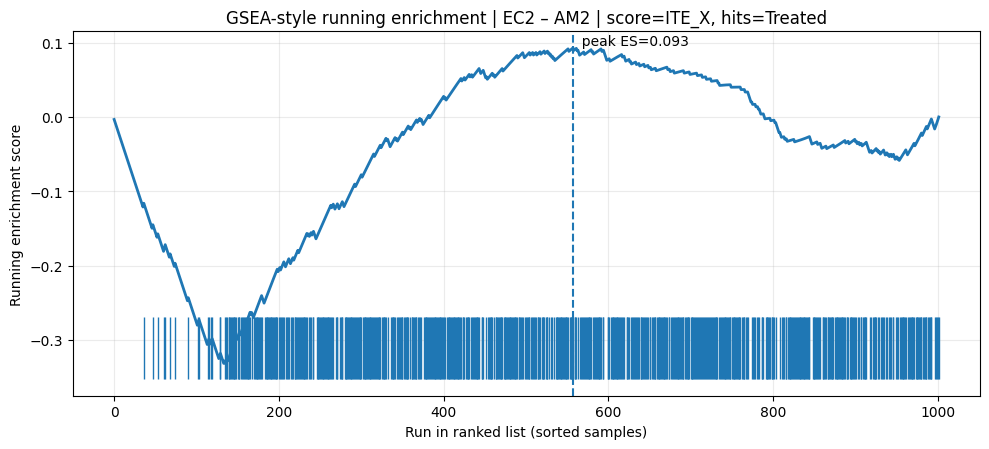

{'df_sorted':       orig_idx  y_true  treat     ITE_T  GE  AG  ED  MO  PE  GS  ET
 0         1202     1.0      0  2.865102   2   2   2   1   2   2   3
 1          131     1.0      0  2.854081   2   2   1   1   1   1   1
 2           93     1.0      0  2.846459   2   2   3   5   3   4   2
 3         1191     1.0      0  2.828866   1   1   1   1   1   1   1
 4          130     1.0      0  2.814858   2   6   1   3   1   1   1
 ...        ...     ...    ...       ...  ..  ..  ..  ..  ..  ..  ..
 997        345     2.0      1 -1.175456   2   3   2   4   4   5   1
 998        669     2.0      1 -1.287179   2   2   4   3   3   3   3
 999        877     2.0      1 -1.300407   1   4   2   4   4   5   2
 1000      1021     1.0      1 -1.484505   2   1   2   3   3   2   2
 1001      1053     1.0      1 -1.484505   2   1   2   3   3   2   2
 
 [1002 rows x 11 columns],
 'running_es': array([-3.36700337e-03, -6.73400673e-03, -1.01010101e-02, ...,
        -7.13480453e-03, -3.56740227e-03, -2.3835100

In [25]:
df_ec2_am2 = eval_dict_all["EC2"]["AM2"]

# 先用 T-Learner 的 ITE 做排序（你也可以换 ITE_S / ITE_T）
plot_gsea_style(
    df_ec2_am2,
    score_col="ITE_T",
    hit_col="treat",          # treat==1 的样本画竖线
    title="GSEA-style running enrichment | EC2 – AM2 | score=ITE_X, hits=Treated",
    weight_p=1.0
)


In [21]:
other12 = ["CO1","CO2","CO3","CO4","RT1","RT2","CC1","CC2","FC","EP","CL","FL"]
controls = ["GE","AG","ED","MO","PE","GS","ET"]


In [22]:
import sys
import pandas as pd
import numpy as np

# ======================================================
# 0) 静音 LightGBM / 其它模型 stdout/stderr（可选）
# ======================================================
class NullIO:
    def write(self, *args, **kwargs):
        pass
    def flush(self):
        pass


# ======================================================
# 1) 主程序：只跑 T-Learner（顺序执行，无额外函数）
#    依赖你已有对象：
#    - df
#    - outcome_task_map
#    - task_outputs (含 selected_models / NCL_weights / model_objects)
#    - TrainableStackingModel
#    - Treatment_vars
#    - Control_vars = ['GE','AG','ED','MO','PE','GS','ET']
# ======================================================
all_results = {}

eval_dict_EC1 = {}
eval_dict_EC2 = {}
eval_dict_EC3 = {}
eval_dict_EC4 = {}

eval_target_map = {
    "EC1": eval_dict_EC1,
    "EC2": eval_dict_EC2,
    "EC3": eval_dict_EC3,
    "EC4": eval_dict_EC4
}

for outcome, task_name in outcome_task_map.items():

    print("\n======================================")
    print(f" Running T-Learner for {outcome} ({task_name})")
    print("======================================")

    # ---- stacking Base Model (task-specific) ----
    selected_names   = task_outputs[task_name]["selected_models"]
    selected_weights = task_outputs[task_name]["NCL_weights"]
    model_templates  = task_outputs[task_name]["model_objects"]

    # 创建 get_base_model()
    def get_base_model():
        return TrainableStackingModel(
            selected_names,
            model_templates,
            selected_weights
        )

    rows = []        # 保存 ATE
    eval_holder = {} # 保存 ITE（以及 orig_idx / 控制变量）

    for tr in Treatment_vars:

        # ===============================
        # 2) 数据（与原逻辑一致：极端组 <=2 或 >=4）
        # ===============================
        X_vars = Control_vars + [v for v in Treatment_vars if v != tr]
        mask = (df[tr] <= 2) | (df[tr] >= 4)

        # 原始索引用于后续对齐（非常建议保存）
        orig_idx = df.loc[mask].index.to_numpy()

        Y = df.loc[mask, outcome].astype(float).values
        T = (df.loc[mask, tr] >= 4).astype(int).values

        # 这里 reset_index(drop=True) 以确保与 Y/T/ITE 一一对应
        X = df.loc[mask, X_vars].copy().reset_index(drop=True)

        # 静音（可选）
        _stdout, _stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = NullIO(), NullIO()

        # ===============================
        # 3) T-Learner
        # ===============================
        model_t1 = get_base_model()
        model_t0 = get_base_model()

        model_t1.fit(X[T == 1], Y[T == 1])
        model_t0.fit(X[T == 0], Y[T == 0])

        ITE_t = model_t1.predict(X) - model_t0.predict(X)
        ATE_t = float(np.mean(ITE_t))

        # 恢复输出
        sys.stdout, sys.stderr = _stdout, _stderr

        # ===============================
        # 4) 保存结果
        # ===============================
        rows.append({
            "Treatment": tr,
            "ATE_T": round(ATE_t, 4)
        })

        # eval_df：保存 ITE + 对齐索引 + 控制变量（便于后续 ES/hit）
        eval_df = pd.DataFrame({
            "orig_idx": orig_idx,
            "y_true": Y,
            "treat": T,
            "ITE_T": ITE_t
        })

        # 把 7 个控制变量一并存进去（用于后续作为 hit 或分层）
        # 注意：这些列是否在 X 中存在取决于你 X_vars 的构造，这里通常都存在
        for c in Control_vars:
            eval_df[c] = X[c].values

        eval_holder[tr] = eval_df

    # outcome 的 ATE 汇总
    all_results[outcome] = pd.DataFrame(rows)
    print(all_results[outcome])

    # outcome 的 eval_dict
    eval_target_map[outcome].update(eval_holder)


# ======================================================
# 5) 组合成 eval_dict_all（后续画图/算ES用）
# ======================================================
eval_dict_all = {
    "EC1": eval_dict_EC1,
    "EC2": eval_dict_EC2,
    "EC3": eval_dict_EC3,
    "EC4": eval_dict_EC4,
}

print("\n✔ eval_dict_all 已准备（仅 T-Learner）：可用 eval_dict_all['EC2']['AM2'] 读取对应 df_eval")



 Running T-Learner for EC1 (Task1)
   Treatment   ATE_T
0        AM1  0.0800
1        AM2  0.5706
2        AM3  0.3273
3        AM4  1.0877
4        CO1  0.2778
5        CO2  0.3471
6        CO3  0.0170
7        CO4  0.4573
8        RT1 -0.0057
9        RT2  0.0308
10       CC1  0.1216
11       CC2  0.0091
12        FC  0.1727
13        EP -0.0535
14        CL -0.0587
15        FL  0.0588

 Running T-Learner for EC2 (Task2)
   Treatment   ATE_T
0        AM1  0.2649
1        AM2  0.5466
2        AM3  0.4522
3        AM4  0.7602
4        CO1  0.3643
5        CO2  0.3234
6        CO3  0.0108
7        CO4  0.7942
8        RT1  0.2626
9        RT2  0.0360
10       CC1  0.1393
11       CC2 -0.0949
12        FC  0.1866
13        EP  0.2602
14        CL -0.0764
15        FL  0.1511

 Running T-Learner for EC3 (Task3)
   Treatment   ATE_T
0        AM1  0.3321
1        AM2  0.5267
2        AM3  0.5934
3        AM4  0.3270
4        CO1  0.4945
5        CO2  0.3751
6        CO3  0.0654
7        C

In [23]:
import numpy as np
import pandas as pd

AM_list = ["AM1","AM2","AM3","AM4"]
other12 = ["CO1","CO2","CO3","CO4","RT1","RT2","CC1","CC2","FC","EP","CL","FL"]
controls = ["GE","AG","ED","MO","PE","GS","ET"]

def percentile_rank(s):
    # 越大 rank 越高（0~1）
    return s.rank(method="average", pct=True)

def build_agg_rank(eval_dict_all, outcome="EC2", ite_col="ITE_T", strict_intersection=True):
    # 取 AM1~AM4 对应的 eval df
    dfs = []
    for tr in AM_list:
        d = eval_dict_all[outcome][tr].copy()
        if "orig_idx" not in d.columns:
            raise ValueError(f"{outcome}-{tr} 缺少 orig_idx，请先在 eval_holder 里保存 orig_idx")
        d = d[["orig_idx", ite_col]].rename(columns={ite_col: f"{ite_col}_{tr}"})
        dfs.append(d)

    # 合并到同一张表：每行对应同一个人（orig_idx）
    how = "inner" if strict_intersection else "outer"
    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on="orig_idx", how=how)

    # 各 treatment 内转 percentile rank，再求平均
    for tr in AM_list:
        col = f"{ite_col}_{tr}"
        merged[f"rank_{tr}"] = merged[col].rank(method="average")


    merged["rank_AM_mean"] = merged[[f"rank_{tr}" for tr in AM_list]].mean(axis=1)

    return merged  # columns: orig_idx, ite cols, rank cols, rank_AM_mean


In [24]:
import numpy as np
import pandas as pd

def gsea_es_from_rank(score, hit):
    """
    score: 1D array, 用于排序（越大越靠前）
    hit:   1D array(0/1), 命中集合
    """
    df = pd.DataFrame({"score": score, "hit": hit}).sort_values("score", ascending=False).reset_index(drop=True)
    hits = df["hit"].astype(int).values
    N = len(df)
    Nh = hits.sum()
    Nm = N - Nh
    if Nh == 0 or Nh == N:
        return np.nan, np.nan, int(Nh), int(N)

    inc_hit = hits / Nh
    inc_miss = (1 - hits) / Nm
    running = np.cumsum(inc_hit - inc_miss)

    peak_idx = int(np.argmax(running))
    peak_es = float(running[peak_idx])
    peak_pos = peak_idx / (N - 1)  # 0~1

    return peak_es, peak_pos, int(Nh), int(N)

def compute_es_table_controls(
    df_raw,
    agg_rank_df,
    vars_for_hit,
    mode="high",          # "high" or "levels"
    score_col="rank_AM_mean",
    idx_col="orig_idx",
    likert_thr=4,         # ✅ 新增：其他Likert变量命中阈值（>=3 或 >=4）
):
    """
    df_raw: 原始问卷 DataFrame（含 GE/AG/ED/MO/PE/GS/ET 等列）
    agg_rank_df: build_agg_rank 输出（至少含 idx_col 与 score_col）
    vars_for_hit: 需要计算 ES 的变量列表（可含 controls + other12）
    mode:
      - "high": 只算每个变量的“高等级/目标组”富集
      - "levels": 对分类变量每个水平都算一条（如 ED1~ED4）
    likert_thr:
      - 非控制变量（CO/RT/CC/FC/EP/CL/FL 等）按 >= likert_thr 为 hit
    """
    base = agg_rank_df.merge(df_raw[vars_for_hit], left_on=idx_col, right_index=True, how="left").copy()
    score = base[score_col].values

    rows = []

    for v in vars_for_hit:
        # ---------- 控制变量：按你给的实际编码 ----------
        if v == "GE":
            if mode == "levels":
                for lv in [1, 2]:
                    hit = (base["GE"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"GE{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["GE"] == 1).astype(int).values  # Female=1
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "GE", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "AG":
            if mode == "levels":
                for lv in [1,2,3,4,5,6,7]:
                    hit = (base["AG"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"AG{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["AG"] >= 5).astype(int).values  # 41+
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "AG", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "ED":
            if mode == "levels":
                for lv in [1,2,3,4]:
                    hit = (base["ED"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"ED{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["ED"] == 4).astype(int).values  # Graduate+
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "ED", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "MO":
            if mode == "levels":
                for lv in [11,2,3,4,5]:
                    hit = (base["MO"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"MO{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["MO"] >= 4).astype(int).values  # Good+
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "MO", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "PE":
            if mode == "levels":
                for lv in [1,2,3,4]:
                    hit = (base["PE"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"PE{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["PE"] >= 3).astype(int).values  # 2–4 or 5+
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "PE", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "GS":
            if mode == "levels":
                for lv in [1,2,3,4,5]:
                    hit = (base["GS"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"GS{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["GS"] >= 3).astype(int).values  # 2+
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "GS", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "ET":
            if mode == "levels":
                for lv in [1,2,3,4]:
                    hit = (base["ET"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"ET{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["ET"] >= 3).astype(int).values  # Annual+
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "ET", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        # ---------- 其他 Likert 变量 ----------
        else:
            hit = (base[v] >= likert_thr).astype(int).values   # ✅ 这里用阈值
            es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
            rows.append({"hit_var": v, "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

    out = pd.DataFrame(rows).sort_values("ES", ascending=False).reset_index(drop=True)
    return out



In [25]:
# outcome 你自己选：EC1/EC2/EC3/EC4
outcome = "EC2"

# 1) 构建聚合排序（确保输出包含：orig_idx + rank_AM_mean）
agg = build_agg_rank(
    eval_dict_all,
    outcome=outcome,
    ite_col="ITE_T",
    strict_intersection=True
)

# 2) 命中变量集合（other12 + controls）
vars_for_hit = other12 + controls

# 3) 自动识别 build_agg_rank 输出列名（更稳）
score_col = "rank_AM_mean" if "rank_AM_mean" in agg.columns else (
    "score" if "score" in agg.columns else (
        "rank_score" if "rank_score" in agg.columns else agg.columns[-1]
    )
)

idx_col = "orig_idx" if "orig_idx" in agg.columns else (
    "idx" if "idx" in agg.columns else None
)

if idx_col is None:
    raise ValueError("agg 中找不到 orig_idx/idx。请检查 build_agg_rank 的输出列名。")

# 4) 计算 ES 表（注意：这里不要再传 hit_rule 了）
es_table = compute_es_table_controls(
    df_raw=df,
    agg_rank_df=agg,
    vars_for_hit=vars_for_hit,
    mode="high",         # 或 "levels"（要 ED1-ED4/AG1-AG7 这种）
    score_col=score_col,
    idx_col=idx_col,
)

es_df = es_table.copy()
print(es_table)


   hit_var            ES  peak_pos   Nh    N
0       ED  2.670474e-01  0.275459   85  600
1       CL  2.141707e-01  0.412354  276  600
2       ET  1.250000e-01  0.676127  200  600
3      CC2  1.071008e-01  0.363940  329  600
4       AG  9.929301e-02  0.594324  214  600
5      CO1  6.764943e-02  0.904841  374  600
6       EP  6.750000e-02  0.924875  400  600
7      CO2  6.677104e-02  0.916528  356  600
8       GE  5.338777e-02  0.065109  271  600
9      CO4  4.834826e-02  0.904841  395  600
10      FC  4.605953e-02  0.914858  421  600
11     CO3  3.258157e-02  0.898164  284  600
12     RT1  3.051980e-02  0.891486  337  600
13      MO  2.609394e-02  0.949917  318  600
14      FL  1.198590e-02  0.989983  370  600
15     CC1  9.878419e-03  0.988314  376  600
16      PE  2.631579e-03  0.000000  380  600
17      GS  2.500000e-03  0.976628  400  600
18     RT2 -7.901665e-16  1.000000  406  600


In [26]:
# ======================================================
# EC1–EC4 全部跑一遍：AM1–AM4 排序聚合 -> 计算 other12 + controls 的 ES 表
# ======================================================

outcomes = ["EC1", "EC2", "EC3", "EC4"]
vars_for_hit = other12 + controls

es_tables = {}
agg_tables = {}

for outcome in outcomes:
    print(f"\n================ {outcome} ================\n")

    agg = build_agg_rank(
        eval_dict_all,
        outcome=outcome,
        ite_col="ITE_T",
        strict_intersection=True
    )
    agg_tables[outcome] = agg

    # 自动确定列名（更稳）
    score_col = "rank_AM_mean" if "rank_AM_mean" in agg.columns else (
        "score" if "score" in agg.columns else (
            "rank_score" if "rank_score" in agg.columns else agg.columns[-1]
        )
    )
    idx_col = "orig_idx" if "orig_idx" in agg.columns else (
        "idx" if "idx" in agg.columns else None
    )
    if idx_col is None:
        raise ValueError("agg 中找不到 orig_idx/idx，请检查 build_agg_rank 输出。")

    es_table = compute_es_table_controls(
        df_raw=df,
        agg_rank_df=agg,
        vars_for_hit=vars_for_hit,
        mode="high",           # 或 "levels"
        score_col=score_col,
        idx_col=idx_col,
        likert_thr=3           # ✅ >=3
    )

    es_tables[outcome] = es_table
    print(es_table)

# Top-5
print("\n\n========== Top-5 by ES (each outcome) ==========")
for outcome in outcomes:
    top5 = es_tables[outcome].head(5)[["hit_var", "ES", "peak_pos", "Nh", "N"]]
    print(f"\n[{outcome}]")
    print(top5.to_string(index=False))



================ EC1 ================

   hit_var            ES  peak_pos   Nh    N
0       CL  3.908858e-01  0.424040  410  600
1       ED  2.830383e-01  0.308848   85  600
2      CC2  2.828947e-01  0.803005  448  600
3      CO3  2.804878e-01  0.791319  410  600
4       FL  2.571037e-01  0.412354  508  600
5       EP  1.999008e-01  0.803005  504  600
6      CO2  1.875000e-01  0.833055  480  600
7      RT1  1.078854e-01  0.796327  464  600
8       ET  1.050000e-01  0.709516  200  600
9       FC  4.296011e-02  0.876461  519  600
10      GE  4.152133e-02  0.729549  271  600
11      MO  3.693296e-02  0.025042  318  600
12     CC1  3.520924e-02  0.876461  495  600
13     CO4  2.316532e-02  0.973289  514  600
14     RT2  1.511204e-02  0.991653  505  600
15     CO1  8.849558e-03  0.998331  487  600
16      AG  5.689797e-03  0.991653  214  600
17      PE  5.023923e-03  0.984975  380  600
18      GS  7.025630e-17  1.000000  400  600

================ EC2 ================

   hit_var        ES

In [27]:
import pandas as pd

stacked = []
for outcome, tab in es_tables.items():
    t = tab.copy()
    t["outcome"] = outcome
    stacked.append(t)

es_all = pd.concat(stacked, ignore_index=True)


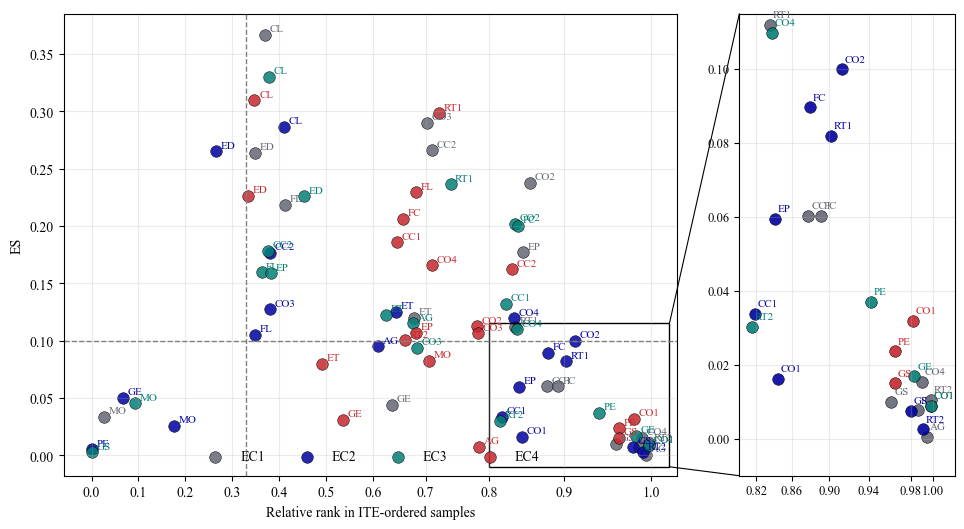

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib.gridspec import GridSpecFromSubplotSpec
# ======================================================
# Global font: Times New Roman
# ======================================================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

# ======================================================
# Colors
# ======================================================
colors = {
    "EC1": "#646774",
    "EC2": "#0001A1",
    "EC3": "#037F77",
    "EC4": "#C5272D",
}

# ======================================================
# x transform (your mild expanded scale)
# ======================================================
def x_transform_simple(x, split=0.6, alpha=1.2):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    right = x > split
    t = x[right] - split
    y[right] = split + t + alpha * (t ** 2)
    return y

SPLIT = 0.6
ALPHA = 1.2

# ======================================================
# Zoom region (EDIT HERE if you want)
# Use RAW domain for defining the region, then transform for plotting
# ======================================================
raw_x_min, raw_x_max = 0.80, 1.02
y_zoom_min, y_zoom_max = -0.01, 0.115

x_zoom_min = x_transform_simple(raw_x_min, SPLIT, ALPHA)
x_zoom_max = x_transform_simple(raw_x_max, SPLIT, ALPHA)

# ======================================================
# Layout: main (left) + zoom (right)  -> no occlusion
# ======================================================
fig = plt.figure(figsize=(11.5, 6))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[3.7, 1.3], wspace=0.15)

ax = fig.add_subplot(gs[0, 0])      # main
ax_zoom = fig.add_subplot(gs[0, 1]) # zoom view on the right

# =======================
# Main plot
# =======================
for outcome, c in colors.items():
    d = es_all[es_all["outcome"] == outcome].copy()
    x_disp = x_transform_simple(d["peak_pos"].values, SPLIT, ALPHA)

    ax.scatter(
        x_disp, d["ES"],
        s=70, alpha=0.85,
        color=c, edgecolor="black", linewidth=0.4,
        label=outcome
    )

    for _, r in d.iterrows():
        ax.text(
            x_transform_simple(r["peak_pos"], SPLIT, ALPHA) + 0.01,
            r["ES"] + 0.003,
            r["hit_var"],
            fontsize=8,
            color=c
        )

# reference lines on main
ax.axvline(x_transform_simple(0.33, SPLIT, ALPHA), linestyle="--", linewidth=1, color="grey")
ax.axhline(0.10, linestyle="--", linewidth=1, color="grey")

# x ticks (main)
xticks_raw = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
xticks_disp = x_transform_simple(xticks_raw, SPLIT, ALPHA)
ax.set_xticks(xticks_disp)
ax.set_xticklabels([f"{x:.1f}" for x in xticks_raw])

ax.set_xlabel("Relative rank in ITE-ordered samples")
ax.set_ylabel("ES")
#ax.set_title("ES vs. Peak Position across EC1–EC4")
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=4, loc="lower center")

# =======================
# Draw zoom rectangle on main (must fully cover region)
# =======================
rect = Rectangle(
    (x_zoom_min, y_zoom_min),
    x_zoom_max - x_zoom_min,
    y_zoom_max - y_zoom_min,
    fill=False, edgecolor="black", linewidth=1.0
)
ax.add_patch(rect)

# =======================
# Zoom plot (right)
# =======================
for outcome, c in colors.items():
    d = es_all[es_all["outcome"] == outcome].copy()
    x_disp = x_transform_simple(d["peak_pos"].values, SPLIT, ALPHA)

    ax_zoom.scatter(
        x_disp, d["ES"],
        s=70, alpha=0.90,
        color=c, edgecolor="black", linewidth=0.4
    )

    # label only points within zoom window (avoid clutter)
    for _, r in d.iterrows():
        xd = x_transform_simple(r["peak_pos"], SPLIT, ALPHA)
        if (x_zoom_min <= xd <= x_zoom_max) and (y_zoom_min <= r["ES"] <= y_zoom_max):
            ax_zoom.text(
                xd + 0.005,
                r["ES"] + 0.002,
                r["hit_var"],
                fontsize=8,
                color=c
            )

ax_zoom.set_xlim(x_zoom_min, x_zoom_max)
ax_zoom.set_ylim(y_zoom_min, y_zoom_max)
ax_zoom.grid(alpha=0.25)
#ax_zoom.set_title("Zoomed view", fontsize=10)

# Keep zoom axis labels minimal (optional)
ax_zoom.set_xlabel("")
ax_zoom.set_ylabel("")
ax_zoom.tick_params(axis="both", labelsize=9)

# Make zoom x-ticks show raw values
xt_raw_zoom = np.array([0.82, 0.86, 0.90, 0.94, 0.98, 1.00])
xt_disp_zoom = x_transform_simple(xt_raw_zoom, SPLIT, ALPHA)
ax_zoom.set_xticks(xt_disp_zoom)
ax_zoom.set_xticklabels([f"{x:.2f}" for x in xt_raw_zoom])

# y ticks for zoom
ax_zoom.set_yticks([0.00, 0.02, 0.04, 0.06, 0.08, 0.10])

# =======================
# Connection lines (main rectangle -> zoom panel)
# =======================
# connect top-right and bottom-right corners of rectangle to zoom panel left edge
con1 = ConnectionPatch(
    xyA=(x_zoom_max, y_zoom_max), coordsA=ax.transData,
    xyB=(x_zoom_min, y_zoom_max), coordsB=ax_zoom.transData,
    color="black", linewidth=0.8
)
con2 = ConnectionPatch(
    xyA=(x_zoom_max, y_zoom_min), coordsA=ax.transData,
    xyB=(x_zoom_min, y_zoom_min), coordsB=ax_zoom.transData,
    color="black", linewidth=0.8
)
fig.add_artist(con1)
fig.add_artist(con2)

plt.tight_layout()
save_dir = r"D:\论文数据\2025.10 出口选择\HTE"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "ES_vs_PeakPosition_EC1_EC4_Zoom.png")

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)
plt.show()


{'peak_es': 0.4330856340033623, 'peak_idx': 159, 'Nh': 85, 'N': 600}


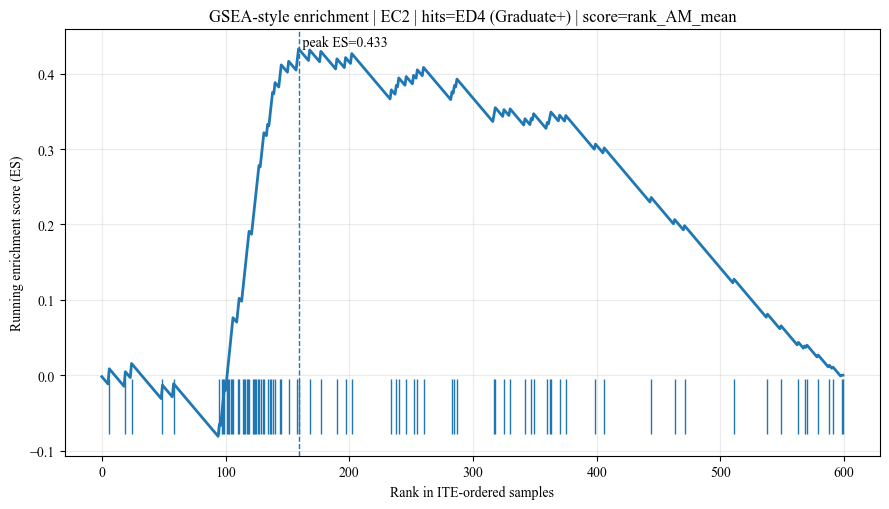

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_gsea_style(df_ranked, score_col, hit_col, title, weight=1.0):
    d = df_ranked.copy().reset_index(drop=True)
    s = d[score_col].astype(float).values
    h = d[hit_col].astype(int).values
    N = len(d)
    Nh = int(h.sum())
    Nm = N - Nh

    if Nh == 0 or Nm == 0:
        raise ValueError(f"Invalid hit split: Nh={Nh}, N={N}. Check hit rule / data.")

    w = np.abs(s) ** weight
    w_hit_sum = (w * h).sum()
    if w_hit_sum <= 0:
        w = np.ones_like(s)
        w_hit_sum = (w * h).sum()

    inc_hit = (w * h) / w_hit_sum
    inc_miss = (1 - h) / Nm
    running_es = np.cumsum(inc_hit - inc_miss)

    peak_idx = int(np.argmax(running_es))
    peak_es = float(running_es[peak_idx])

    fig, ax = plt.subplots(figsize=(9, 5.2))
    x = np.arange(N)

    ax.plot(x, running_es, linewidth=2)
    ax.axvline(peak_idx, linestyle="--", linewidth=1)
    ax.text(peak_idx, peak_es, f" peak ES={peak_es:.3f}", va="bottom", fontsize=10)

    ax.set_title(title)
    ax.set_xlabel("Rank in ITE-ordered samples")
    ax.set_ylabel("Running enrichment score (ES)")
    ax.grid(alpha=0.25)

    ymin, ymax = ax.get_ylim()
    tick_base = ymin + 0.05 * (ymax - ymin)
    tick_top  = ymin + 0.18 * (ymax - ymin)
    hit_pos = np.where(h == 1)[0]
    ax.vlines(hit_pos, tick_base, tick_top, linewidth=1)

    plt.tight_layout()

    return {"df_sorted": d, "running_es": running_es, "peak_idx": peak_idx, "peak_es": peak_es, "Nh": Nh, "N": N}


# ===============================
# 2) Build EC2 aggregated ranking
# ===============================
outcome = "EC2"
agg = build_agg_rank(eval_dict_all, outcome=outcome, ite_col="ITE_T", strict_intersection=True)

score_col = "rank_AM_mean" if "rank_AM_mean" in agg.columns else (
    "score" if "score" in agg.columns else agg.columns[-1]
)

# 兼容索引列：优先 orig_idx，再 idx，否则用 index
idx_col = "orig_idx" if "orig_idx" in agg.columns else ("idx" if "idx" in agg.columns else None)

if idx_col is not None:
    df_ranked = agg[[idx_col, score_col]].copy()
    df_ranked["ED"] = df.loc[df_ranked[idx_col], "ED"].values
else:
    df_ranked = agg[[score_col]].copy()
    df_ranked["ED"] = df.loc[df_ranked.index, "ED"].values

# ===============================
# 3) Construct hit (ED=4: Graduate+)
# ===============================
df_ranked["hit_ED4"] = (df_ranked["ED"] == 4).astype(int)

# sort by score desc (front = higher ITE / rank)
df_ranked = df_ranked.sort_values(score_col, ascending=False).reset_index(drop=True)

# ===============================
# 4) Plot
# ===============================
res = plot_gsea_style(
    df_ranked=df_ranked,
    score_col=score_col,
    hit_col="hit_ED4",
    title=f"GSEA-style enrichment | {outcome} | hits=ED4 (Graduate+) | score={score_col}",
    weight=1.0
)

print({k: res[k] for k in ["peak_es", "peak_idx", "Nh", "N"]})


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_gsea_single_color(
    df_ranked: pd.DataFrame,
    score_col: str,
    hit_col: str,
    title: str,
    weight: float = 1.0,
    sort_inside: bool = False,
    color: str = "#1f77b4",   # 单色（默认蓝色，可改）
    curve_lw: float = 2.4,
    bar_lw: float = 1.2,
    bar_alpha: float = 0.9,
    bottom_pad_frac: float = 0.02,
):
    """
    Single-color GSEA-style visualization.
    - ES curve: single color
    - Bars: single color, from bottom to ES curve at hit positions
    """

    d = df_ranked.copy()
    if sort_inside:
        d = d.sort_values(score_col, ascending=False)
    d = d.reset_index(drop=True)

    s = d[score_col].astype(float).values
    h = d[hit_col].astype(int).values
    N = len(d)
    Nh = int(h.sum())
    Nm = N - Nh
    if Nh == 0 or Nm == 0:
        raise ValueError(f"Invalid hit split: Nh={Nh}, N={N}. Check hit rule / data.")

    # --------------------------
    # 1) Running enrichment score (GSEA-like)
    # --------------------------
    w = np.abs(s) ** weight
    w_hit_sum = (w * h).sum()
    if w_hit_sum <= 0:
        w = np.ones_like(s)
        w_hit_sum = (w * h).sum()

    inc_hit = (w * h) / w_hit_sum
    inc_miss = (1 - h) / Nm
    running_es = np.cumsum(inc_hit - inc_miss)

    peak_idx = int(np.argmax(running_es))
    peak_es = float(running_es[peak_idx])

    # --------------------------
    # 2) Plot
    # --------------------------
    fig, ax = plt.subplots(figsize=(9.2, 5.4))
    x = np.arange(N)

    # ES curve (single color)
    ax.plot(x, running_es, color=color, linewidth=curve_lw)

    # Axis limits
    ax.set_xlim(0, N - 1)
    ax.set_ylim(min(running_es.min(), 0) - 0.05,
                running_es.max() + 0.05)

    # Peak marker
    ax.axvline(peak_idx, linestyle="--", linewidth=1, color="black", alpha=0.7)
    ax.text(peak_idx, peak_es, f" peak ES={peak_es:.3f}",
            va="bottom", fontsize=10)

    # Bars: from bottom to ES curve (single color)
    ymin, ymax = ax.get_ylim()
    y0 = ymin + bottom_pad_frac * (ymax - ymin)

    hit_pos = np.where(h == 1)[0]
    y1 = running_es[hit_pos]

    ax.vlines(
        hit_pos, y0, y1,
        colors=color,
        linewidth=bar_lw,
        alpha=bar_alpha
    )

    # Labels & grid
    ax.set_title(title)
    ax.set_xlabel("Rank in ITE-ordered samples")
    ax.set_ylabel("Running enrichment score (ES)")
    ax.grid(alpha=0.25)

    plt.tight_layout()

    return {
        "df_sorted": d,
        "running_es": running_es,
        "peak_idx": peak_idx,
        "peak_es": peak_es,
        "Nh": Nh,
        "N": N,
    }


{'peak_es': 0.4330856340033623, 'peak_idx': 159, 'Nh': 85, 'N': 600}


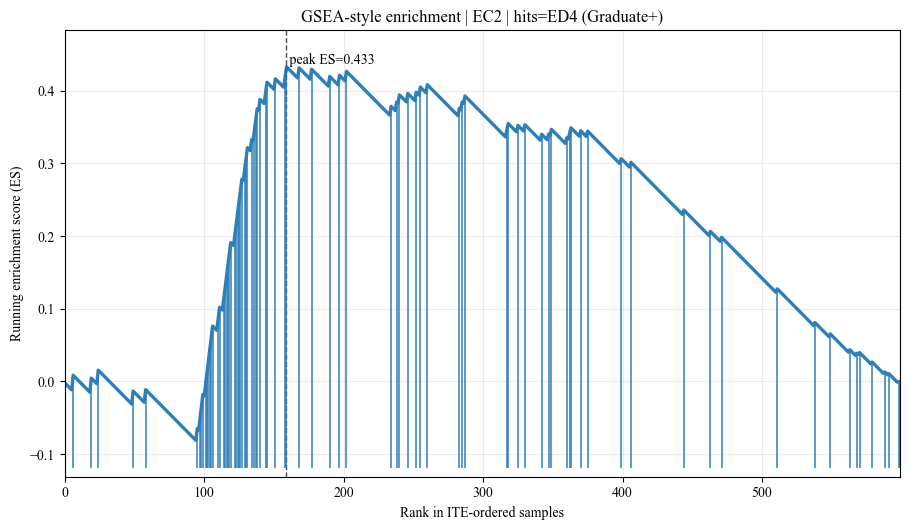

In [79]:
res = plot_gsea_single_color(
    df_ranked=df_ranked,
    score_col=score_col,
    hit_col="hit_ED4",
    title="GSEA-style enrichment | EC2 | hits=ED4 (Graduate+)",
    color="#2C7FB8"  # 深蓝，期刊友好
)

print({k: res[k] for k in ["peak_es", "peak_idx", "Nh", "N"]})


In [28]:
# ======================================================
# 0) Imports + Basic Settings
# ======================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, ConnectionPatch

# Global font: Times New Roman
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"


In [29]:
# ======================================================
# 1) Config (你常改的参数集中放这)
# ======================================================
AM_list   = ["AM1", "AM2", "AM3", "AM4"]
other12   = ["CO1","CO2","CO3","CO4","RT1","RT2","CC1","CC2","FC","EP","CL","FL"]
controls  = ["GE","AG","ED","MO","PE","GS","ET"]

outcomes  = ["EC1", "EC2", "EC3", "EC4"]

LIKERT_THR = 3                 # other12 的 hit 阈值（>=3 或 >=4）
STRICT_INTERSECTION = True     # AM1~AM4 聚合时是否取交集
ES_MODE = "high"               # "high" 或 "levels"

# x transform (右侧拉伸)
SPLIT = 0.6
ALPHA = 1.2

# Zoom region (raw domain)
raw_x_min, raw_x_max = 0.80, 1.02
y_zoom_min, y_zoom_max = -0.01, 0.115

# plot style
colors = {
    "EC1": "#646774",
    "EC2": "#0001A1",
    "EC3": "#037F77",
    "EC4": "#C5272D",
}

SAVE_DIR  = r"D:\论文数据\2025.10 出口选择\HTE"
SAVE_NAME = "ES_vs_PeakPosition_EC1_EC4_Zoom.png"



In [30]:
# ======================================================
# 2) Utilities: 静音输出（可选）
# ======================================================
class NullIO:
    def write(self, *args, **kwargs):
        pass
    def flush(self):
        pass


# ======================================================
# 3) Stage A: Run T-Learner and build eval_dict_all
#    依赖你已有对象：
#    - df
#    - outcome_task_map
#    - task_outputs (selected_models / NCL_weights / model_objects)
#    - TrainableStackingModel
#    - Treatment_vars
#    - Control_vars
# ======================================================
all_results = {}

eval_dict_all = {"EC1": {}, "EC2": {}, "EC3": {}, "EC4": {}}

for outcome, task_name in outcome_task_map.items():
    print("\n======================================")
    print(f" Running T-Learner for {outcome} ({task_name})")
    print("======================================")

    selected_names   = task_outputs[task_name]["selected_models"]
    selected_weights = task_outputs[task_name]["NCL_weights"]
    model_templates  = task_outputs[task_name]["model_objects"]

    def get_base_model():
        return TrainableStackingModel(
            selected_names,
            model_templates,
            selected_weights
        )

    rows = []
    eval_holder = {}

    for tr in Treatment_vars:
        # ---- data mask: extreme groups ----
        X_vars = Control_vars + [v for v in Treatment_vars if v != tr]
        mask = (df[tr] <= 2) | (df[tr] >= 4)

        orig_idx = df.loc[mask].index.to_numpy()
        Y = df.loc[mask, outcome].astype(float).values
        T = (df.loc[mask, tr] >= 4).astype(int).values
        X = df.loc[mask, X_vars].copy().reset_index(drop=True)

        # ---- silence (optional) ----
        _stdout, _stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = NullIO(), NullIO()

        # ---- T-Learner ----
        model_t1 = get_base_model()
        model_t0 = get_base_model()

        model_t1.fit(X[T == 1], Y[T == 1])
        model_t0.fit(X[T == 0], Y[T == 0])

        ITE_t = model_t1.predict(X) - model_t0.predict(X)
        ATE_t = float(np.mean(ITE_t))

        # ---- restore output ----
        sys.stdout, sys.stderr = _stdout, _stderr

        # ---- save ATE ----
        rows.append({"Treatment": tr, "ATE_T": round(ATE_t, 4)})

        # ---- save eval df (ITE + meta) ----
        eval_df = pd.DataFrame({
            "orig_idx": orig_idx,
            "y_true": Y,
            "treat": T,
            "ITE_T": ITE_t
        })

        for c in Control_vars:
            eval_df[c] = X[c].values

        eval_holder[tr] = eval_df

    all_results[outcome] = pd.DataFrame(rows)
    print(all_results[outcome])

    eval_dict_all[outcome].update(eval_holder)

print("\n✔ eval_dict_all ready (T-Learner). Example: eval_dict_all['EC2']['AM2']")



 Running T-Learner for EC1 (Task1)
   Treatment   ATE_T
0        AM1  0.1146
1        AM2  0.5767
2        AM3  0.3339
3        AM4  1.0878
4        CO1  0.2306
5        CO2  0.3744
6        CO3  0.0232
7        CO4  0.5438
8        RT1 -0.0091
9        RT2 -0.0167
10       CC1  0.0873
11       CC2  0.0497
12        FC  0.1718
13        EP -0.0274
14        CL -0.0461
15        FL  0.0994

 Running T-Learner for EC2 (Task2)
   Treatment   ATE_T
0        AM1  0.2649
1        AM2  0.5466
2        AM3  0.4522
3        AM4  0.7602
4        CO1  0.3643
5        CO2  0.3234
6        CO3  0.0108
7        CO4  0.7942
8        RT1  0.2626
9        RT2  0.0360
10       CC1  0.1393
11       CC2 -0.0949
12        FC  0.1866
13        EP  0.2602
14        CL -0.0764
15        FL  0.1511

 Running T-Learner for EC3 (Task3)
   Treatment   ATE_T
0        AM1  0.3321
1        AM2  0.5267
2        AM3  0.5934
3        AM4  0.3270
4        CO1  0.4945
5        CO2  0.3751
6        CO3  0.0654
7        C

In [31]:
# ======================================================
# 4) Stage B: Build aggregated rank (AM1–AM4 ITE rank mean)
# ======================================================
def percentile_rank(s: pd.Series) -> pd.Series:
    return s.rank(method="average", pct=True)

def build_agg_rank(eval_dict_all, outcome="EC2", ite_col="ITE_T",
                   AM_list=("AM1","AM2","AM3","AM4"),
                   strict_intersection=True):

    dfs = []
    for tr in AM_list:
        d = eval_dict_all[outcome][tr].copy()
        if "orig_idx" not in d.columns:
            raise ValueError(f"{outcome}-{tr} missing orig_idx")
        d = d[["orig_idx", ite_col]].rename(columns={ite_col: f"{ite_col}_{tr}"})
        dfs.append(d)

    how = "inner" if strict_intersection else "outer"
    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on="orig_idx", how=how)

    for tr in AM_list:
        col = f"{ite_col}_{tr}"
        merged[f"rank_{tr}"] = percentile_rank(merged[col])

    merged["rank_AM_mean"] = merged[[f"rank_{tr}" for tr in AM_list]].mean(axis=1)
    return merged


In [32]:
# ======================================================
# 5) Stage C: GSEA-like ES computation
# ======================================================
def gsea_es_from_rank(score, hit):
    df_ = pd.DataFrame({"score": score, "hit": hit}).sort_values("score", ascending=False).reset_index(drop=True)

    hits = df_["hit"].astype(int).values
    N = len(df_)
    Nh = hits.sum()
    Nm = N - Nh
    if Nh == 0 or Nh == N:
        return np.nan, np.nan, int(Nh), int(N)

    inc_hit = hits / Nh
    inc_miss = (1 - hits) / Nm
    running = np.cumsum(inc_hit - inc_miss)

    peak_idx = int(np.argmax(running))
    peak_es = float(running[peak_idx])
    peak_pos = peak_idx / (N - 1)

    return peak_es, peak_pos, int(Nh), int(N)

def compute_es_table_controls(df_raw, agg_rank_df, vars_for_hit,
                             mode="high", score_col="rank_AM_mean", idx_col="orig_idx",
                             likert_thr=4):

    base = agg_rank_df.merge(df_raw[vars_for_hit], left_on=idx_col, right_index=True, how="left").copy()
    score = base[score_col].values

    rows = []

    for v in vars_for_hit:
        # ---------- controls: 按你原规则 ----------
        if v == "GE":
            if mode == "levels":
                for lv in [1, 2]:
                    hit = (base["GE"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"GE{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["GE"] == 1).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "GE", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "AG":
            if mode == "levels":
                for lv in [1,2,3,4,5,6,7]:
                    hit = (base["AG"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"AG{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["AG"] >= 5).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "AG", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "ED":
            if mode == "levels":
                for lv in [1,2,3,4]:
                    hit = (base["ED"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"ED{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["ED"] == 4).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "ED", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "MO":
            if mode == "levels":
                for lv in [1,2,3,4,5]:
                    hit = (base["MO"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"MO{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["MO"] >= 4).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "MO", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "PE":
            if mode == "levels":
                for lv in [1,2,3,4]:
                    hit = (base["PE"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"PE{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["PE"] >= 3).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "PE", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "GS":
            if mode == "levels":
                for lv in [1,2,3,4,5]:
                    hit = (base["GS"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"GS{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["GS"] >= 3).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "GS", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        elif v == "ET":
            if mode == "levels":
                for lv in [1,2,3,4]:
                    hit = (base["ET"] == lv).astype(int).values
                    es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                    rows.append({"hit_var": f"ET{lv}", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})
            else:
                hit = (base["ET"] >= 3).astype(int).values
                es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
                rows.append({"hit_var": "ET", "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

        # ---------- other12: Likert hit ----------
        else:
            hit = (base[v] >= likert_thr).astype(int).values
            es, peak_pos, Nh, N = gsea_es_from_rank(score, hit)
            rows.append({"hit_var": v, "ES": es, "peak_pos": peak_pos, "Nh": Nh, "N": N})

    out = pd.DataFrame(rows).sort_values("ES", ascending=False).reset_index(drop=True)
    return out



In [33]:
# ======================================================
# 6) Stage D: Run ES for EC1–EC4 (aggregate rank -> ES table)
# ======================================================
vars_for_hit = other12 + controls

es_tables = {}
agg_tables = {}

for oc in outcomes:
    print(f"\n================ {oc} ================\n")

    agg = build_agg_rank(
        eval_dict_all,
        outcome=oc,
        ite_col="ITE_T",
        AM_list=AM_list,
        strict_intersection=STRICT_INTERSECTION
    )
    agg_tables[oc] = agg

    es_table = compute_es_table_controls(
        df_raw=df,
        agg_rank_df=agg,
        vars_for_hit=vars_for_hit,
        mode=ES_MODE,
        score_col="rank_AM_mean",
        idx_col="orig_idx",
        likert_thr=LIKERT_THR
    )
    es_tables[oc] = es_table
    print(es_table.head(10))

print("\n\n========== Top-5 by ES (each outcome) ==========")
for oc in outcomes:
    top5 = es_tables[oc].head(5)[["hit_var", "ES", "peak_pos", "Nh", "N"]]
    print(f"\n[{oc}]")
    print(top5.to_string(index=False))



================ EC1 ================

  hit_var        ES  peak_pos   Nh    N
0      CL  0.398973  0.419032  410  600
1      ED  0.287036  0.317195   85  600
2     CC2  0.280898  0.689482  448  600
3     CO3  0.277535  0.762938  410  600
4      FL  0.258131  0.402337  508  600
5     CO2  0.212500  0.828047  480  600
6      EP  0.184028  0.831386  504  600
7     RT1  0.128043  0.841402  464  600
8      ET  0.122500  0.767947  200  600
9      GE  0.050864  0.691152  271  600

================ EC2 ================

  hit_var        ES  peak_pos   Nh    N
0      CL  0.290116  0.365609  410  600
1      ED  0.267047  0.275459   85  600
2     CC2  0.171875  0.377295  448  600
3      ET  0.125000  0.621035  200  600
4     CO3  0.124005  0.388982  410  600
5     CO4  0.115691  0.831386  514  600
6      FL  0.110151  0.363940  508  600
7      AG  0.101884  0.592654  214  600
8     CO2  0.097917  0.911519  480  600
9      FC  0.092700  0.894825  519  600

================ EC3 ================



In [34]:
# ======================================================
# 7) Stage E: Stack ES tables (for plotting)
#     ✅ Plot only controls
# ======================================================
es_all = pd.concat(
    [tab.assign(outcome=oc) for oc, tab in es_tables.items()],
    ignore_index=True
)

# ✅ 只在绘图阶段过滤：只保留 controls
controls_set = set(controls)
es_all_plot = es_all[es_all["hit_var"].isin(controls_set)].copy()


In [59]:
# ======================================================
# CATE (controls-levels) with x-axis in [0,1] percentile rank
# - Build AM1–AM4 aggregated percentile ranks (0–1)
# - Compute CATE for each control level (GE1.., AG1.., ...)
# - Plot AG-only (or any single control) with x in [0,1] and auto-zoomed x-limits
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Global font
# =========================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

# =========================
# Config
# =========================
AM_list   = ["AM1", "AM2", "AM3", "AM4"]
controls  = ["GE", "AG", "ED", "MO", "PE", "GS", "ET"]
outcomes  = ["EC1", "EC2", "EC3", "EC4"]

STRICT_INTERSECTION = True
MIN_GROUP_N = 30

BOOTSTRAP_B = 300      # 0 -> no CI
SEED = 42

colors = {"EC1": "#646774", "EC2": "#0001A1", "EC3": "#037F77", "EC4": "#C5272D"}

SAVE_DIR  = r"D:\论文数据\2025.10 出口选择\HTE"
SAVE_NAME = "CATE_AG_levels_xPercentile.png"

# =========================
# Utilities
# =========================
def bootstrap_ci_mean(x, B=300, alpha=0.05, seed=42):
    """Bootstrap CI for mean."""
    if B <= 0:
        return (np.nan, np.nan)
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n <= 1:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(B, n))
    means = x[idx].mean(axis=1)
    lo = np.quantile(means, alpha / 2)
    hi = np.quantile(means, 1 - alpha / 2)
    return (float(lo), float(hi))


def build_agg_rank_and_ite(
    eval_dict_all,
    outcome,
    ite_col="ITE_T",
    AM_list=("AM1", "AM2", "AM3", "AM4"),
    strict_intersection=True,
):
    """
    Build sample-level table:
      - orig_idx
      - ITE_T_AMk for each AMk
      - rank_AM_mean: mean percentile rank (0–1) across AM1–AM4
      - ITE_AM_mean : mean ITE across AM1–AM4
    """
    dfs = []
    for tr in AM_list:
        d = eval_dict_all[outcome][tr].copy()
        if "orig_idx" not in d.columns:
            raise ValueError(f"{outcome}-{tr} missing orig_idx.")
        d = d[["orig_idx", ite_col]].rename(columns={ite_col: f"{ite_col}_{tr}"})
        dfs.append(d)

    how = "inner" if strict_intersection else "outer"
    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on="orig_idx", how=how)

    # ✅ percentile rank (0–1)
    for tr in AM_list:
        col = f"{ite_col}_{tr}"
        merged[f"rank_{tr}"] = merged[col].rank(method="average", pct=True)

    merged["rank_AM_mean"] = merged[[f"rank_{tr}" for tr in AM_list]].mean(axis=1)
    merged["ITE_AM_mean"]  = merged[[f"{ite_col}_{tr}" for tr in AM_list]].mean(axis=1)

    return merged


# =========================
# Control levels (manual; or auto-detect if missing)
# =========================
control_levels = {
    "GE": [1, 2],
    "AG": [1, 2, 3, 4, 5, 6, 7],
    "ED": [1, 2, 3, 4],
    "MO": [1, 2, 3, 4, 5],
    "PE": [1, 2, 3, 4],
    "GS": [1, 2, 3, 4, 5],
    "ET": [1, 2, 3, 4],
}


def compute_cate_controls_levels(
    df_raw,
    eval_dict_all,
    outcomes,
    controls,
    control_levels,
    AM_list,
    strict_intersection=True,
    min_group_n=30,
    bootstrap_B=300,
    seed=42,
):
    """
    For each outcome and each control variable level:
      - x_mean_rank: mean percentile rank (0–1) of subgroup
      - CATE: mean ITE_AM_mean of subgroup
      - CI: bootstrap CI of CATE
    """
    rows = []

    for oc in outcomes:
        agg = build_agg_rank_and_ite(
            eval_dict_all=eval_dict_all,
            outcome=oc,
            ite_col="ITE_T",
            AM_list=AM_list,
            strict_intersection=strict_intersection,
        )

        base = agg.merge(df_raw[controls], left_on="orig_idx", right_index=True, how="left")

        for v in controls:
            levels = control_levels.get(v, sorted(base[v].dropna().unique().tolist()))
            for lv in levels:
                sub = base.loc[base[v] == lv, ["rank_AM_mean", "ITE_AM_mean"]].dropna()
                n = len(sub)
                if n < min_group_n:
                    continue

                x = float(sub["rank_AM_mean"].mean())  # 0–1 percentile position
                y = float(sub["ITE_AM_mean"].mean())   # CATE

                lo, hi = bootstrap_ci_mean(sub["ITE_AM_mean"].values, B=bootstrap_B, seed=seed)

                rows.append(
                    {
                        "outcome": oc,
                        "group": f"{v}{lv}",  # label
                        "var": v,
                        "level": lv,
                        "n": n,
                        "x_mean_rank": x,
                        "CATE": y,
                        "CI_lo": lo,
                        "CI_hi": hi,
                    }
                )

    return pd.DataFrame(rows)


# ======================================================
# 1) Compute CATE table
# ======================================================
# Assumes you already have:
#   - df (raw questionnaire DataFrame)
#   - eval_dict_all (from your T-learner stage)
cate_lv_df = compute_cate_controls_levels(
    df_raw=df,
    eval_dict_all=eval_dict_all,
    outcomes=outcomes,
    controls=controls,
    control_levels=control_levels,
    AM_list=AM_list,
    strict_intersection=STRICT_INTERSECTION,
    min_group_n=MIN_GROUP_N,
    bootstrap_B=BOOTSTRAP_B,
    seed=SEED,
)

print(cate_lv_df.sort_values(["outcome", "CATE"], ascending=[True, False]).head(20))

   outcome group var  level    n  x_mean_rank      CATE     CI_lo     CI_hi
2      EC1   AG1  AG      1   41     0.663140  1.244579  1.009873  1.476120
20     EC1   GS1  GS      1   85     0.645711  1.185167  1.059983  1.324848
16     EC1   PE1  PE      1   82     0.627764  1.145309  0.984000  1.290876
11     EC1   ED4  ED      4   85     0.588005  0.914920  0.798629  1.019362
28     EC1   ET4  ET      4  133     0.564483  0.889109  0.780433  0.984454
3      EC1   AG2  AG      2  201     0.545815  0.871351  0.784491  0.968848
21     EC1   GS2  GS      2  115     0.543594  0.867708  0.725626  1.007039
17     EC1   PE2  PE      2  138     0.530444  0.841037  0.716351  0.954561
15     EC1   MO5  MO      5  187     0.529091  0.833825  0.727589  0.943909
10     EC1   ED3  ED      3  164     0.518641  0.806484  0.696574  0.917523
13     EC1   MO3  MO      3  213     0.522529  0.784138  0.705180  0.867761
8      EC1   ED1  ED      1   95     0.504829  0.766023  0.613978  0.922269
12     EC1  

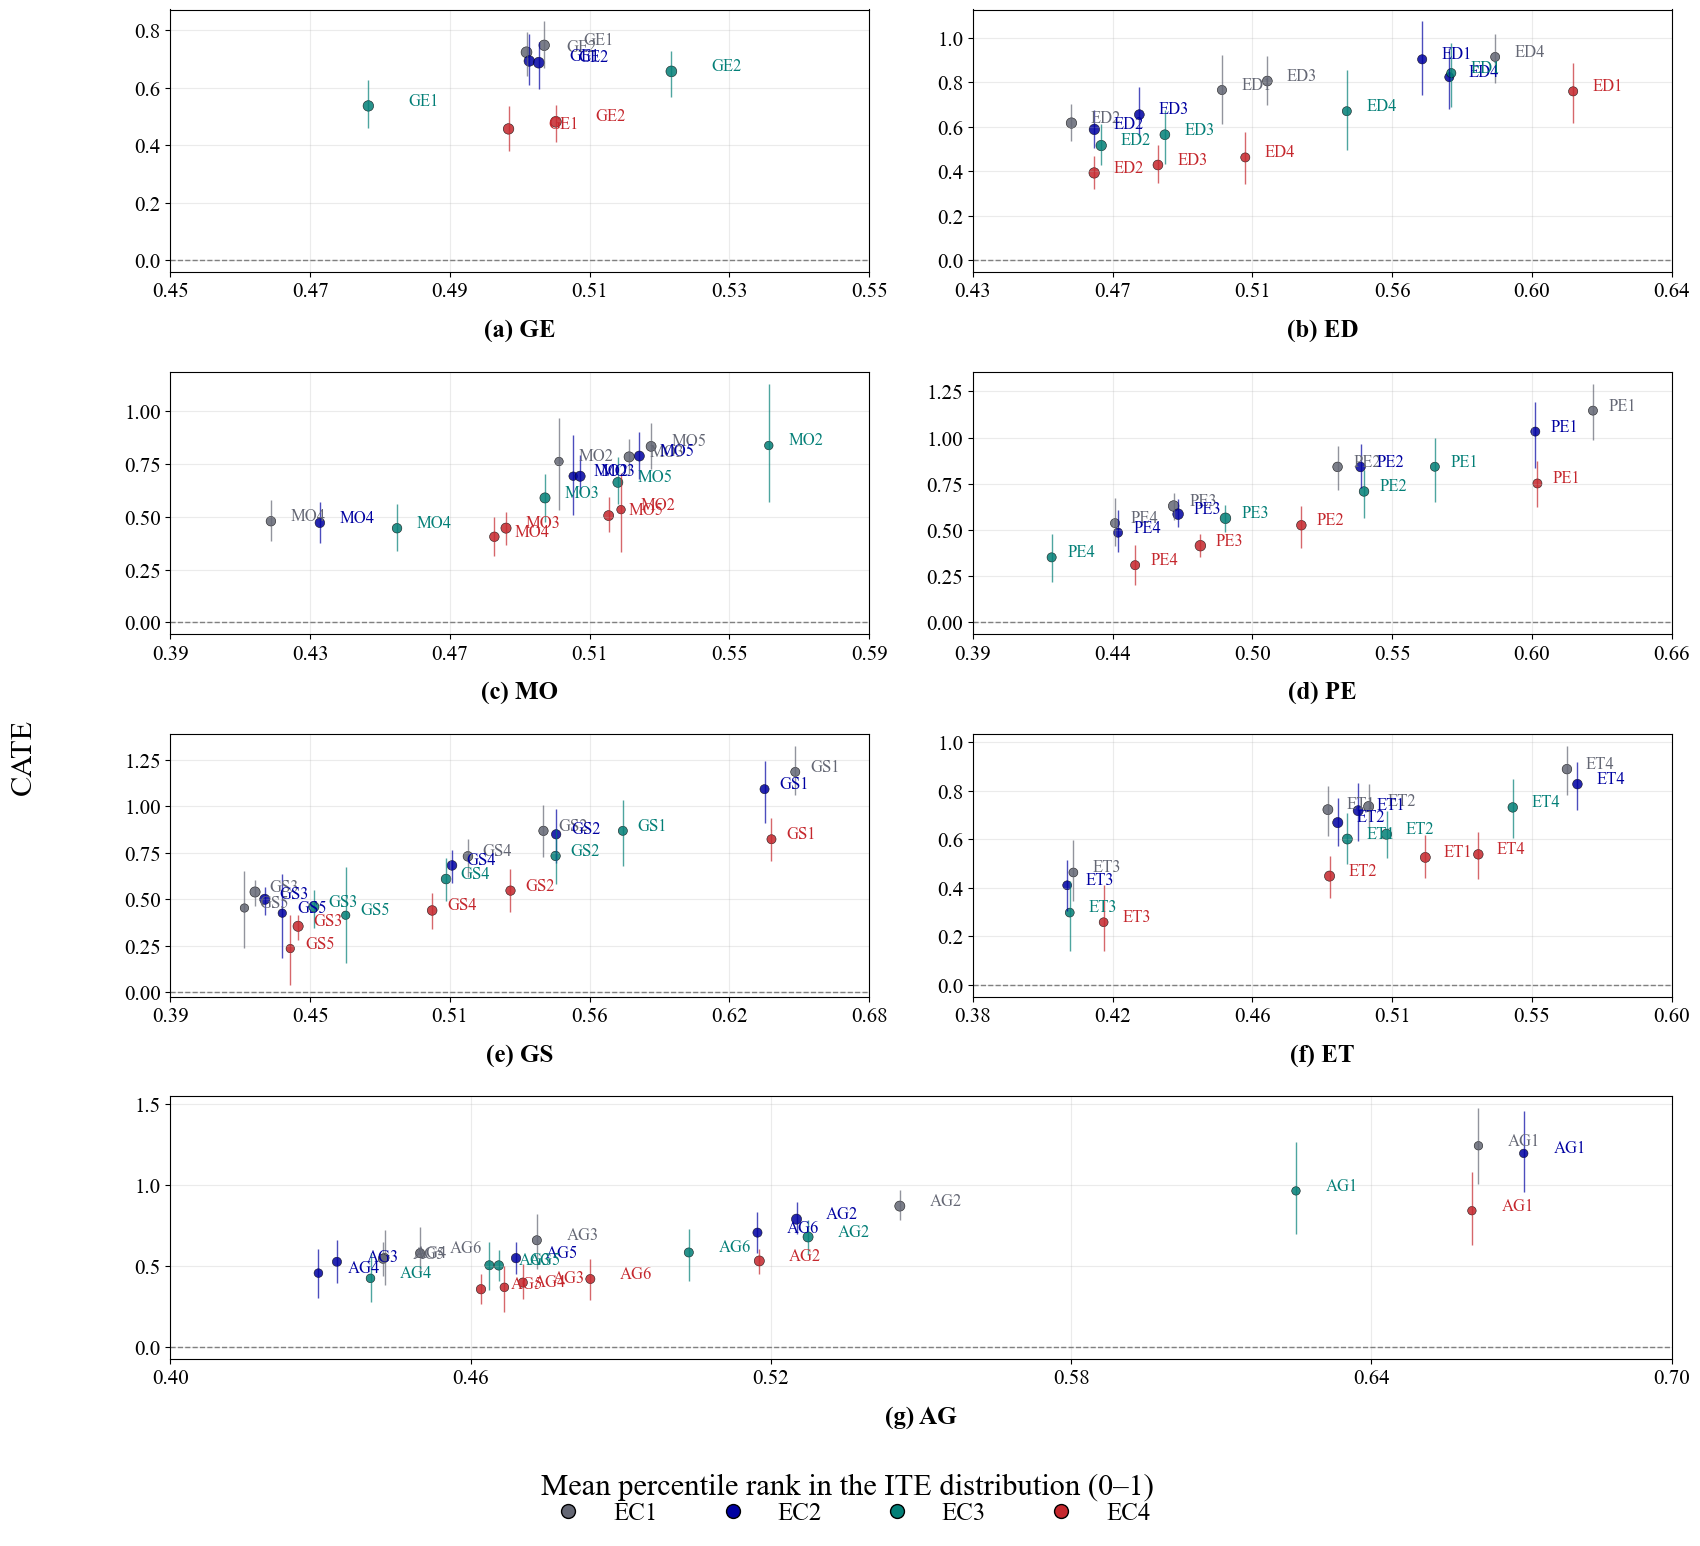

✔ Saved: D:\论文数据\2025.10 出口选择\HTE\CATE_controls_4rows_2cols_AG_center.png


In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Global font
# ---------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

panel_text = {
    "GE": "(a) GE",
    "ED": "(b) ED",
    "MO": "(c) MO",
    "PE": "(d) PE",
    "GS": "(e) GS",
    "ET": "(f) ET",
    "AG": "(g) AG",
}

X_LABEL = "Mean percentile rank in the ITE distribution (0–1)"

# ------------------------------------------------------
# Your original plotting logic (no post-processing)
# ------------------------------------------------------
def draw_one_var_on_ax(
    ax,
    cate_df,
    var,
    colors,
    outcomes=("EC1","EC2","EC3","EC4"),
    bootstrap_B=300,
    pad=0.03,
    n_xticks=6,
):
    dvar = cate_df[cate_df["var"] == var].copy()
    if dvar.empty:
        ax.set_visible(False)
        return

    xmin = float(dvar["x_mean_rank"].min())
    xmax = float(dvar["x_mean_rank"].max())
    xmin_plot = max(0.0, xmin - pad)
    xmax_plot = min(1.0, xmax + pad)

    for oc, c in colors.items():
        d = dvar[dvar["outcome"] == oc].sort_values("level")
        if d.empty:
            continue

        sizes = np.clip(d["n"].values, 10, None)
        sizes = 25 + 2.0 * np.sqrt(sizes)

        ax.scatter(
            d["x_mean_rank"].values,
            d["CATE"].values,
            s=sizes,
            alpha=0.85,
            color=c,
            edgecolor="black",
            linewidth=0.4,
        )

        if bootstrap_B > 0 and ("CI_lo" in d.columns) and ("CI_hi" in d.columns):
            ax.vlines(
                d["x_mean_rank"].values,
                d["CI_lo"].values,
                d["CI_hi"].values,
                color=c,
                linewidth=1.0,
                alpha=0.7,
            )

        # keep your colored level labels
        for _, r in d.iterrows():
            ax.text(
                r["x_mean_rank"] + 0.006,
                r["CATE"] + 0.003,
                f"{var}{int(r['level'])}",
                fontsize=12,
                color=c,
                family="Times New Roman",
            )

    ax.axhline(0.0, linestyle="--", linewidth=1, color="grey")
    ax.set_xlim(xmin_plot, xmax_plot)

    xt = np.linspace(xmin_plot, xmax_plot, n_xticks)
    ax.set_xticks(xt)
    ax.set_xticklabels([f"{x:.2f}" for x in xt])
    ax.grid(alpha=0.25)


# ======================================================
# Layout: 4x2; each row has two subplots, last row has AG only
# ======================================================
fig, axes = plt.subplots(4, 2, figsize=(18, 16))

layout_rows = [
    ["GE", "ED"],
    ["MO", "PE"],
    ["GS", "ET"],
]

# ======================================================
# 前三行：每行两个子图
# ======================================================
for i, row_vars in enumerate(layout_rows):
    for j, var in enumerate(row_vars):
        ax = axes[i, j]

        draw_one_var_on_ax(
            ax,
            cate_lv_df,
            var,
            colors,
            outcomes,
            BOOTSTRAP_B
        )

        ax.tick_params(axis="both", labelsize=15)

        ax.text(
            0.5, -0.18, panel_text[var],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            family="Times New Roman",
            ha="center",
            va="top"
        )

# ======================================================
# 最后一行：AG 居中显示
# ======================================================
axes[3, 0].set_visible(False)
axes[3, 1].set_visible(False)

# 先布局，让位置稳定
fig.supylabel("CATE", fontsize=22, family="Times New Roman", x=0.035)
fig.supxlabel(X_LABEL, fontsize=22, family="Times New Roman", y=0.035)

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=colors[o],
        markeredgecolor="black",
        markersize=10,
        label=o
    )
    for o in outcomes
]

fig.legend(
    handles=handles,
    labels=outcomes,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.005)
)

plt.tight_layout(rect=[0.06, 0.08, 0.98, 0.98], h_pad=1.5, w_pad=2.0)

# 获取最后一行两个空子图的位置，合并成一个居中 AG 图
pos_left = axes[3, 0].get_position()
pos_right = axes[3, 1].get_position()

x0 = pos_left.x0
y0 = pos_left.y0
w = pos_right.x1 - pos_left.x0
h = pos_left.height

ax_ag = fig.add_axes([x0, y0, w, h])

draw_one_var_on_ax(
    ax_ag,
    cate_lv_df,
    "AG",
    colors,
    outcomes,
    BOOTSTRAP_B
)

ax_ag.tick_params(axis="both", labelsize=15)

ax_ag.text(
    0.5, -0.18, panel_text["AG"],
    transform=ax_ag.transAxes,
    fontsize=18,
    fontweight="bold",
    family="Times New Roman",
    ha="center",
    va="top"
)

# ======================================================
# Save
# ======================================================
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(
    SAVE_DIR,
    "CATE_controls_4rows_2cols_AG_center.png"
)

plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.show()

print(f"✔ Saved: {save_path}")


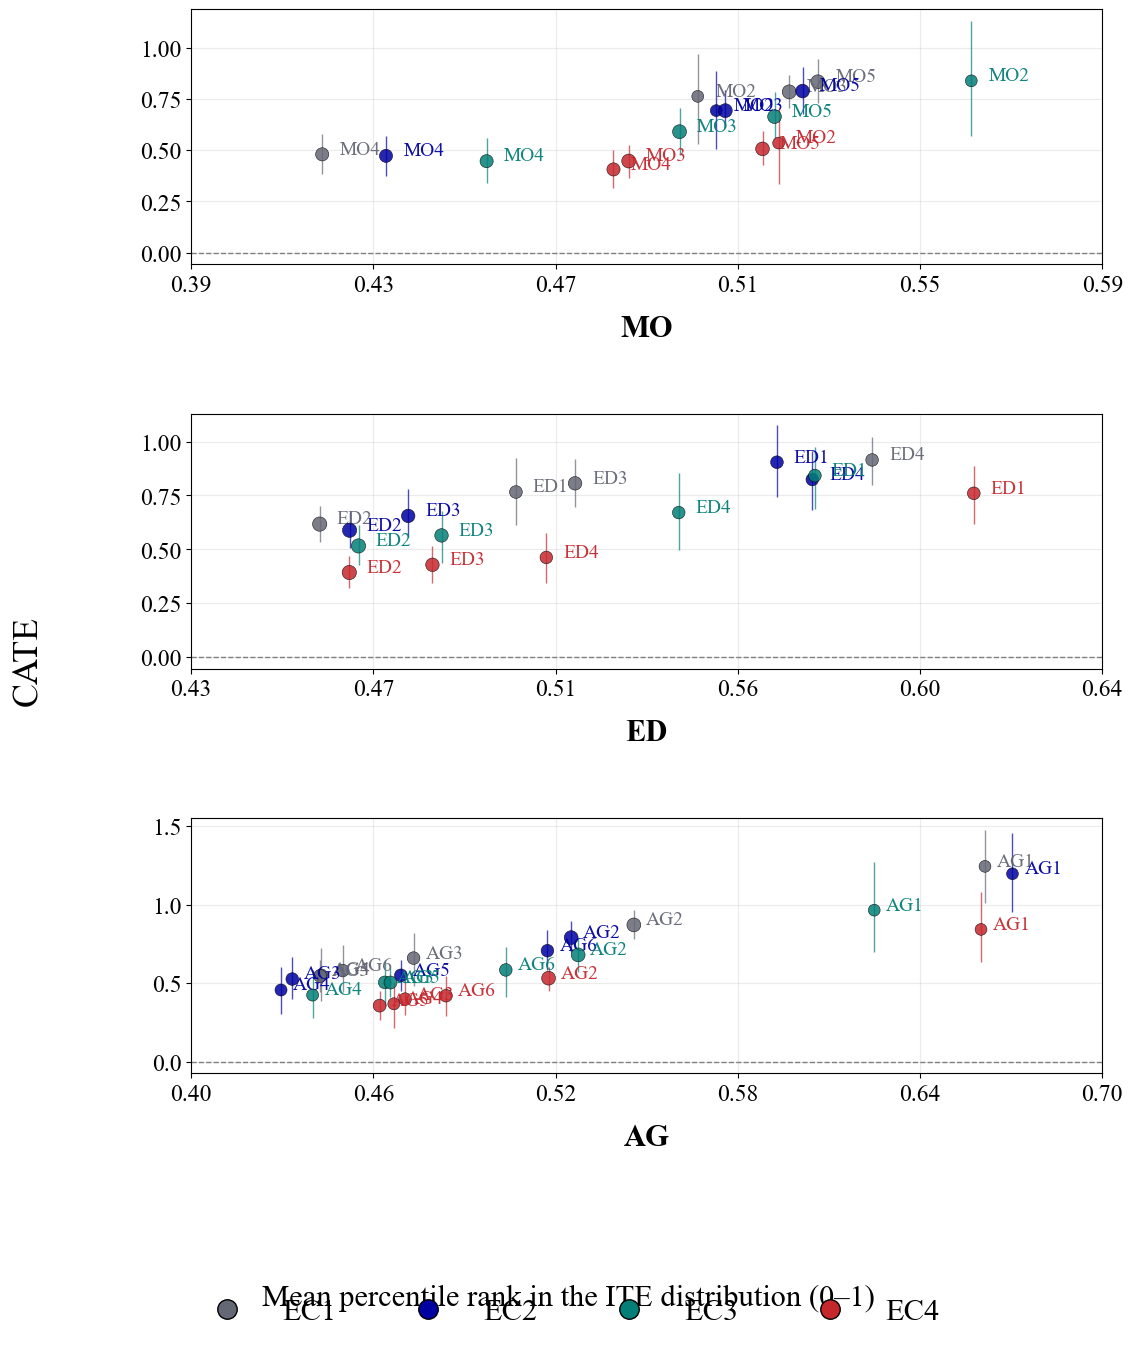

✔ Saved: D:\论文数据\2025.10 出口选择\HTE\CATE_controls_AM_MO_ED_AG_3rows_1col.png


In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Global font
# ---------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

panel_text = {
    "MO": "MO",
    "ED": "ED",
    "AG": "AG",
}

X_LABEL = "Mean percentile rank in the ITE distribution (0–1)"


# ======================================================
# Plotting function
# ======================================================
def draw_one_var_on_ax(
    ax,
    cate_df,
    var,
    colors,
    outcomes=("EC1", "EC2", "EC3", "EC4"),
    bootstrap_B=300,
    pad=0.03,
    n_xticks=6,
):

    dvar = cate_df[cate_df["var"] == var].copy()

    if dvar.empty:
        ax.set_visible(False)
        return

    xmin = float(dvar["x_mean_rank"].min())
    xmax = float(dvar["x_mean_rank"].max())

    xmin_plot = max(0.0, xmin - pad)
    xmax_plot = min(1.0, xmax + pad)

    for oc, c in colors.items():

        d = dvar[dvar["outcome"] == oc].sort_values("level")

        if d.empty:
            continue

        # ======================================================
        # Larger scatter size
        # ======================================================
        sizes = np.clip(d["n"].values, 10, None)
        sizes = 50 + 3.5 * np.sqrt(sizes)

        # ---------------------------
        # Scatter
        # ---------------------------
        ax.scatter(
            d["x_mean_rank"].values,
            d["CATE"].values,
            s=sizes,
            alpha=0.85,
            color=c,
            edgecolor="black",
            linewidth=0.4,
            label=oc,
            zorder=3
        )

        # ---------------------------
        # Error bars
        # ---------------------------
        if bootstrap_B > 0 and ("CI_lo" in d.columns) and ("CI_hi" in d.columns):

            ax.vlines(
                d["x_mean_rank"].values,
                d["CI_lo"].values,
                d["CI_hi"].values,
                color=c,
                linewidth=1.0,
                alpha=0.7,
                zorder=2
            )

        # ======================================================
        # Larger text labels
        # ======================================================
        for _, r in d.iterrows():

            ax.text(
                r["x_mean_rank"] + 0.004,
                r["CATE"] + 0.002,
                f"{var}{int(r['level'])}",
                fontsize=14,
                color=c,
                family="Times New Roman",
                alpha=0.95
            )

    # ---------------------------
    # Baseline
    # ---------------------------
    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1,
        color="grey"
    )

    # ---------------------------
    # Axis range
    # ---------------------------
    ax.set_xlim(xmin_plot, xmax_plot)

    xt = np.linspace(xmin_plot, xmax_plot, n_xticks)

    ax.set_xticks(xt)

    ax.set_xticklabels(
        [f"{x:.2f}" for x in xt]
    )

    # ---------------------------
    # Grid
    # ---------------------------
    ax.grid(alpha=0.25)


# ======================================================
# Layout: 3 rows × 1 column
# ======================================================
layout_vars = ["MO", "ED", "AG"]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14)
)

# ======================================================
# Draw
# ======================================================
for i, var in enumerate(layout_vars):

    ax = axes[i]

    draw_one_var_on_ax(
        ax,
        cate_lv_df,
        var,
        colors,
        outcomes,
        BOOTSTRAP_B
    )

    # ======================================================
    # Larger tick labels
    # ======================================================
    ax.tick_params(
        axis="both",
        labelsize=17
    )

    # ======================================================
    # Larger subplot title
    # ======================================================
    ax.text(
        0.5,
        -0.20,
        panel_text[var],
        transform=ax.transAxes,
        fontsize=22,
        fontweight="bold",
        family="Times New Roman",
        ha="center",
        va="top"
    )


# ======================================================
# Global labels
# ======================================================
fig.supylabel(
    "CATE",
    fontsize=26,
    family="Times New Roman",
    x=0.035
)

# X_LABEL 不放大
fig.supxlabel(
    X_LABEL,
    fontsize=22,
    family="Times New Roman",
    y=0.035
)


# ======================================================
# Legend
# ======================================================
handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=colors[o],
        markeredgecolor="black",
        markersize=14,
        label=o
    )
    for o in outcomes
]

fig.legend(
    handles=handles,
    labels=outcomes,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=22,
    bbox_to_anchor=(0.5, 0.005)
)


# ======================================================
# Layout
# ======================================================
plt.tight_layout(
    rect=[0.08, 0.09, 0.98, 0.98],
    h_pad=3.0
)


# ======================================================
# Save
# ======================================================
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(
    SAVE_DIR,
    "CATE_controls_AM_MO_ED_AG_3rows_1col.png"
)

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"✔ Saved: {save_path}")

   outcome var  level    n  x_mean_rank      CATE     CI_lo     CI_hi
2      EC1  AG      1   40     0.567844  0.575340  0.404189  0.752484
3      EC1  AG      2  168     0.504355  0.418854  0.336913  0.491554
4      EC1  AG      3   94     0.502127  0.421426  0.330151  0.514571
5      EC1  AG      4   46     0.483200  0.355565  0.212921  0.483463
6      EC1  AG      5  128     0.474457  0.358724  0.283703  0.419257
7      EC1  AG      6  123     0.494760  0.396212  0.321373  0.468189
32     EC2  AG      1   40     0.552026  0.578477  0.440817  0.708910
33     EC2  AG      2  168     0.486757  0.476388  0.397397  0.545430
34     EC2  AG      3   94     0.455584  0.399839  0.314984  0.492635
35     EC2  AG      4   46     0.498593  0.471843  0.350574  0.597825
36     EC2  AG      5  128     0.499049  0.461397  0.390477  0.540496
37     EC2  AG      6  123     0.525013  0.533754  0.454926  0.595347
62     EC3  AG      1   40     0.607217  0.879099  0.661109  1.139312
63     EC3  AG      

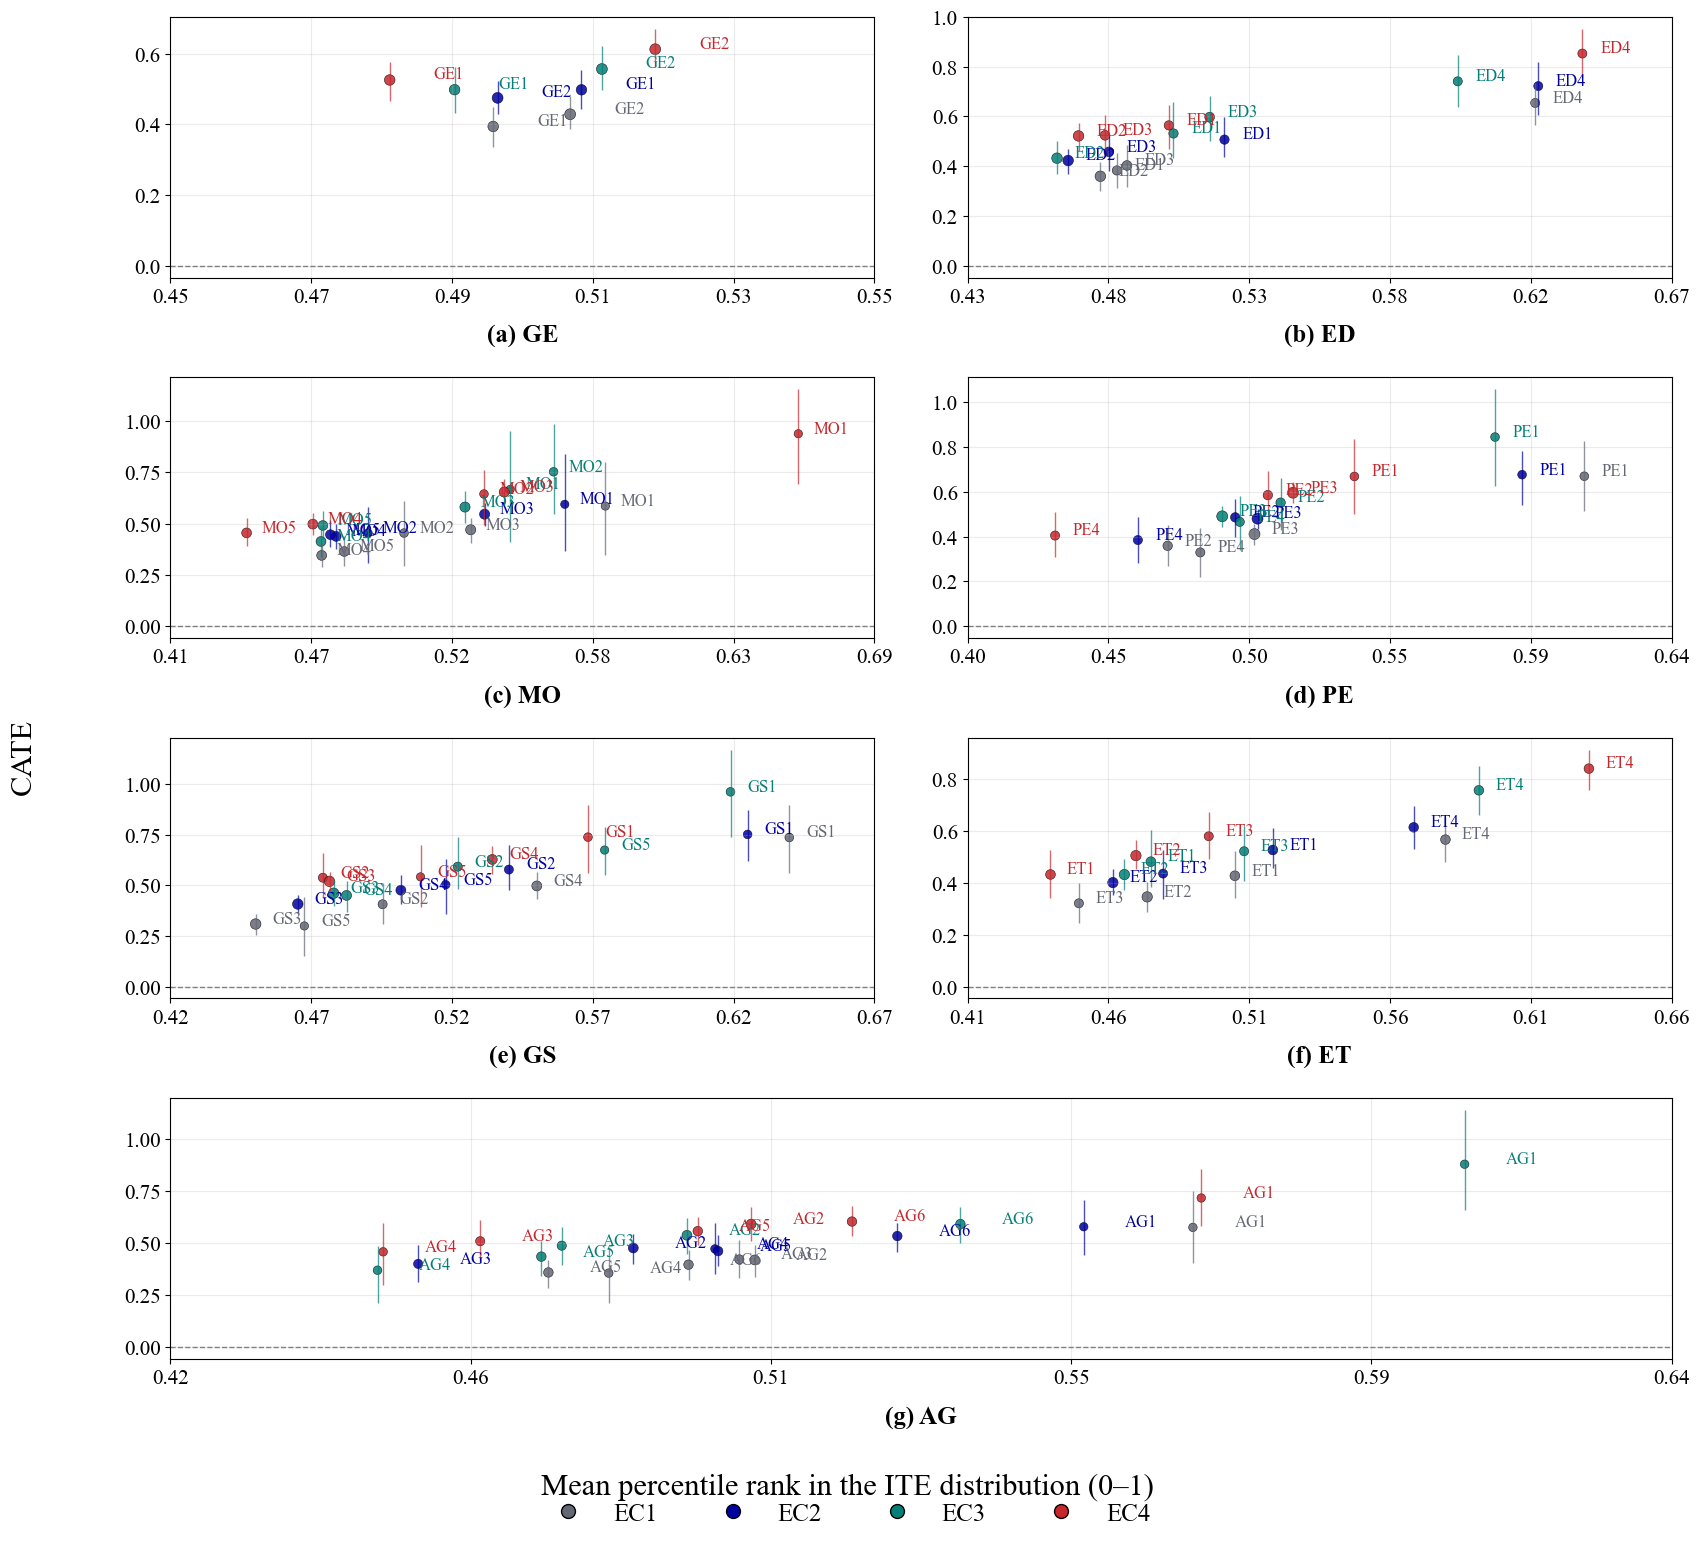

✔ Saved: D:\论文数据\2025.10 出口选择\HTE\CATE_controls_levels_CO_aggregate_4rows_2cols.png


In [62]:
# ======================================================
# AM -> CO 版本（完整代码）
# 目标：把“原来 AM1–AM4 聚合”的那套图，原样改成 CO1–CO4 聚合
# - 用 CO1–CO4 的 ITE_T 做聚合排序
# - x: mean percentile rank (0–1) in CO-aggregated ITE distribution
# - y: CATE = mean ITE (CO-aggregated)
# - 子组：controls 的 levels（GE/AG/ED/MO/PE/GS/ET）
# - 画法：点 + bootstrap CI 竖线 + 彩色 level 文本标签（不二次处理）
# - 布局：三行（前两行各3个，第三行AG居中 1.5× 严格居中）
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Global font
# =========================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

# =========================
# Config
# =========================
# ✅ 关键：这里从 AM 改为 CO
TREATMENT_LIST = ["CO1", "CO2", "CO3", "CO4"]
TREATMENT_TAG  = "CO"  # 用于文件名/轴标题

controls = ["GE", "AG", "ED", "MO", "PE", "GS", "ET"]
outcomes = ["EC1", "EC2", "EC3", "EC4"]

STRICT_INTERSECTION = True
MIN_GROUP_N = 30

BOOTSTRAP_B = 300     # 0 -> no CI
SEED = 42

colors = {"EC1":"#646774","EC2":"#0001A1","EC3":"#037F77","EC4":"#C5272D"}

SAVE_DIR  = r"D:\论文数据\2025.10 出口选择\HTE"
SAVE_NAME = f"CATE_controls_levels_{TREATMENT_TAG}_aggregate.png"

# controls levels（按你原来的编码来）
control_levels = {
    "GE": [1, 2],
    "AG": [1, 2, 3, 4, 5, 6, 7],
    "ED": [1, 2, 3, 4],
    "MO": [1, 2, 3, 4, 5],
    "PE": [1, 2, 3, 4],
    "GS": [1, 2, 3, 4, 5],
    "ET": [1, 2, 3, 4],
}

panel_text = {
    "GE": "(a) GE",
    "ED": "(b) ED",
    "MO": "(c) MO",
    "PE": "(d) PE",
    "GS": "(e) GS",
    "ET": "(f) ET",
    "AG": "(g) AG",
}

X_LABEL = f"Mean percentile rank in the ITE distribution (0–1)"


# =========================
# Utilities
# =========================
def bootstrap_ci_mean(x, B=300, alpha=0.05, seed=42):
    if B <= 0:
        return (np.nan, np.nan)
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n <= 1:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(B, n))
    means = x[idx].mean(axis=1)
    lo = np.quantile(means, alpha / 2)
    hi = np.quantile(means, 1 - alpha / 2)
    return (float(lo), float(hi))


def build_agg_rank_and_ite(
    eval_dict_all,
    outcome,
    ite_col="ITE_T",
    treatment_list=("CO1","CO2","CO3","CO4"),
    strict_intersection=True
):
    """
    把 treatment_list（如 CO1-CO4）对应的 ITE 合并到同一张表
    并计算：
      - rank_*: 每个 treatment 的 ITE percentile rank (0–1)
      - rank_T_mean: 4个 treatment rank 的均值（0–1）
      - ITE_T_mean : 4个 treatment ITE 的均值（用于CATE）
    """
    dfs = []
    for tr in treatment_list:
        d = eval_dict_all[outcome][tr].copy()
        if "orig_idx" not in d.columns:
            raise ValueError(f"{outcome}-{tr} missing orig_idx. 请确认 eval_dict_all 里保存了 orig_idx。")
        d = d[["orig_idx", ite_col]].rename(columns={ite_col: f"{ite_col}_{tr}"})
        dfs.append(d)

    how = "inner" if strict_intersection else "outer"
    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on="orig_idx", how=how)

    # percentile rank (0–1) within each treatment
    for tr in treatment_list:
        col = f"{ite_col}_{tr}"
        merged[f"rank_{tr}"] = merged[col].rank(method="average", pct=True)

    merged["rank_T_mean"] = merged[[f"rank_{tr}" for tr in treatment_list]].mean(axis=1)
    merged["ITE_T_mean"]  = merged[[f"{ite_col}_{tr}" for tr in treatment_list]].mean(axis=1)

    return merged


def compute_cate_controls_levels(
    df_raw,
    eval_dict_all,
    outcomes,
    controls,
    control_levels,
    treatment_list,
    strict_intersection=True,
    min_group_n=30,
    bootstrap_B=300,
    seed=42
):
    """
    对每个 outcome、每个 control 水平：
      x = 子组样本的 mean(rank_T_mean)
      y = 子组样本的 mean(ITE_T_mean) = CATE
      CI = bootstrap 子组 ITE_T_mean 的均值置信区间（可选）
    """
    rows = []
    for oc in outcomes:
        agg = build_agg_rank_and_ite(
            eval_dict_all=eval_dict_all,
            outcome=oc,
            ite_col="ITE_T",
            treatment_list=treatment_list,
            strict_intersection=strict_intersection
        )

        base = agg.merge(df_raw[controls], left_on="orig_idx", right_index=True, how="left")

        for v in controls:
            levels = control_levels.get(v, sorted(base[v].dropna().unique().tolist()))
            for lv in levels:
                sub = base.loc[base[v] == lv, ["rank_T_mean", "ITE_T_mean"]].dropna()
                n = len(sub)
                if n < min_group_n:
                    continue

                x = float(sub["rank_T_mean"].mean())
                y = float(sub["ITE_T_mean"].mean())
                lo, hi = bootstrap_ci_mean(sub["ITE_T_mean"].values, B=bootstrap_B, seed=seed)

                rows.append({
                    "outcome": oc,
                    "var": v,
                    "level": int(lv),
                    "n": int(n),
                    "x_mean_rank": x,
                    "CATE": y,
                    "CI_lo": lo,
                    "CI_hi": hi
                })

    return pd.DataFrame(rows)


# ======================================================
# 1) Compute CATE table (CO-aggregated)
# ======================================================
cate_lv_df = compute_cate_controls_levels(
    df_raw=df,
    eval_dict_all=eval_dict_all,
    outcomes=outcomes,
    controls=controls,
    control_levels=control_levels,
    treatment_list=TREATMENT_LIST,
    strict_intersection=STRICT_INTERSECTION,
    min_group_n=MIN_GROUP_N,
    bootstrap_B=BOOTSTRAP_B,
    seed=SEED
)

print(cate_lv_df.sort_values(["var","outcome","level"]).head(30))


# ======================================================
# 2) Plot helper (保持你原来的画法：点+CI+彩色level标签)
# ======================================================
def draw_one_var_on_ax(
    ax,
    cate_df,
    var,
    colors,
    outcomes=("EC1","EC2","EC3","EC4"),
    bootstrap_B=300,
    pad=0.03,
    n_xticks=6,
):
    dvar = cate_df[cate_df["var"] == var].copy()
    if dvar.empty:
        ax.set_visible(False)
        return

    xmin = float(dvar["x_mean_rank"].min())
    xmax = float(dvar["x_mean_rank"].max())
    xmin_plot = max(0.0, xmin - pad)
    xmax_plot = min(1.0, xmax + pad)

    for oc, c in colors.items():
        d = dvar[dvar["outcome"] == oc].sort_values("level")
        if d.empty:
            continue

        sizes = np.clip(d["n"].values, 10, None)
        sizes = 25 + 2.0 * np.sqrt(sizes)

        ax.scatter(
            d["x_mean_rank"].values,
            d["CATE"].values,
            s=sizes,
            alpha=0.85,
            color=c,
            edgecolor="black",
            linewidth=0.4,
        )

        if bootstrap_B > 0:
            ax.vlines(
                d["x_mean_rank"].values,
                d["CI_lo"].values,
                d["CI_hi"].values,
                color=c,
                linewidth=1.0,
                alpha=0.7
            )

        # 彩色 level 文本（不二次处理）
        for _, r in d.iterrows():
            ax.text(
                r["x_mean_rank"] + 0.006,
                r["CATE"] + 0.003,
                f"{var}{int(r['level'])}",
                fontsize=12,
                color=c,
                family="Times New Roman"
            )

    ax.axhline(0.0, linestyle="--", linewidth=1, color="grey")
    ax.set_xlim(xmin_plot, xmax_plot)

    xt = np.linspace(xmin_plot, xmax_plot, n_xticks)
    ax.set_xticks(xt)
    ax.set_xticklabels([f"{x:.2f}" for x in xt])

    ax.grid(alpha=0.25)


# ======================================================
# 3) Layout: 4x2; each row has two subplots, last row has AG only
# ======================================================
fig, axes = plt.subplots(4, 2, figsize=(18, 16))

layout_rows = [
    ["GE", "ED"],
    ["MO", "PE"],
    ["GS", "ET"],
]

# ======================================================
# 前三行：每行两个子图
# ======================================================
for i, row_vars in enumerate(layout_rows):
    for j, v in enumerate(row_vars):
        ax = axes[i, j]

        draw_one_var_on_ax(
            ax,
            cate_lv_df,
            v,
            colors,
            outcomes,
            BOOTSTRAP_B
        )

        ax.tick_params(axis="both", labelsize=15)

        ax.text(
            0.5, -0.18, panel_text[v],
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=18,
            fontweight="bold",
            family="Times New Roman"
        )

# ======================================================
# 最后一行：AG 居中显示
# ======================================================
axes[3, 0].set_visible(False)
axes[3, 1].set_visible(False)

# Global labels
fig.supylabel(
    "CATE",
    fontsize=22,
    family="Times New Roman",
    x=0.035
)

fig.supxlabel(
    X_LABEL,
    fontsize=22,
    family="Times New Roman",
    y=0.035
)

# Legend
handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=colors[o],
        markeredgecolor="black",
        markersize=10,
        label=o
    )
    for o in outcomes
]

fig.legend(
    handles=handles,
    labels=outcomes,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.005)
)

plt.tight_layout(
    rect=[0.06, 0.08, 0.98, 0.98],
    h_pad=1.5,
    w_pad=2.0
)

# ======================================================
# 合并最后一行两个空位，放置 AG
# ======================================================
pos_left = axes[3, 0].get_position()
pos_right = axes[3, 1].get_position()

x0 = pos_left.x0
y0 = pos_left.y0
w = pos_right.x1 - pos_left.x0
h = pos_left.height

ax_ag = fig.add_axes([x0, y0, w, h])

draw_one_var_on_ax(
    ax_ag,
    cate_lv_df,
    "AG",
    colors,
    outcomes,
    BOOTSTRAP_B
)

ax_ag.tick_params(axis="both", labelsize=15)

ax_ag.text(
    0.5, -0.18, panel_text["AG"],
    transform=ax_ag.transAxes,
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

# ======================================================
# Save
# ======================================================
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(
    SAVE_DIR,
    f"CATE_controls_levels_{TREATMENT_TAG}_aggregate_4rows_2cols.png"
)

plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.show()

print(f"✔ Saved: {save_path}")


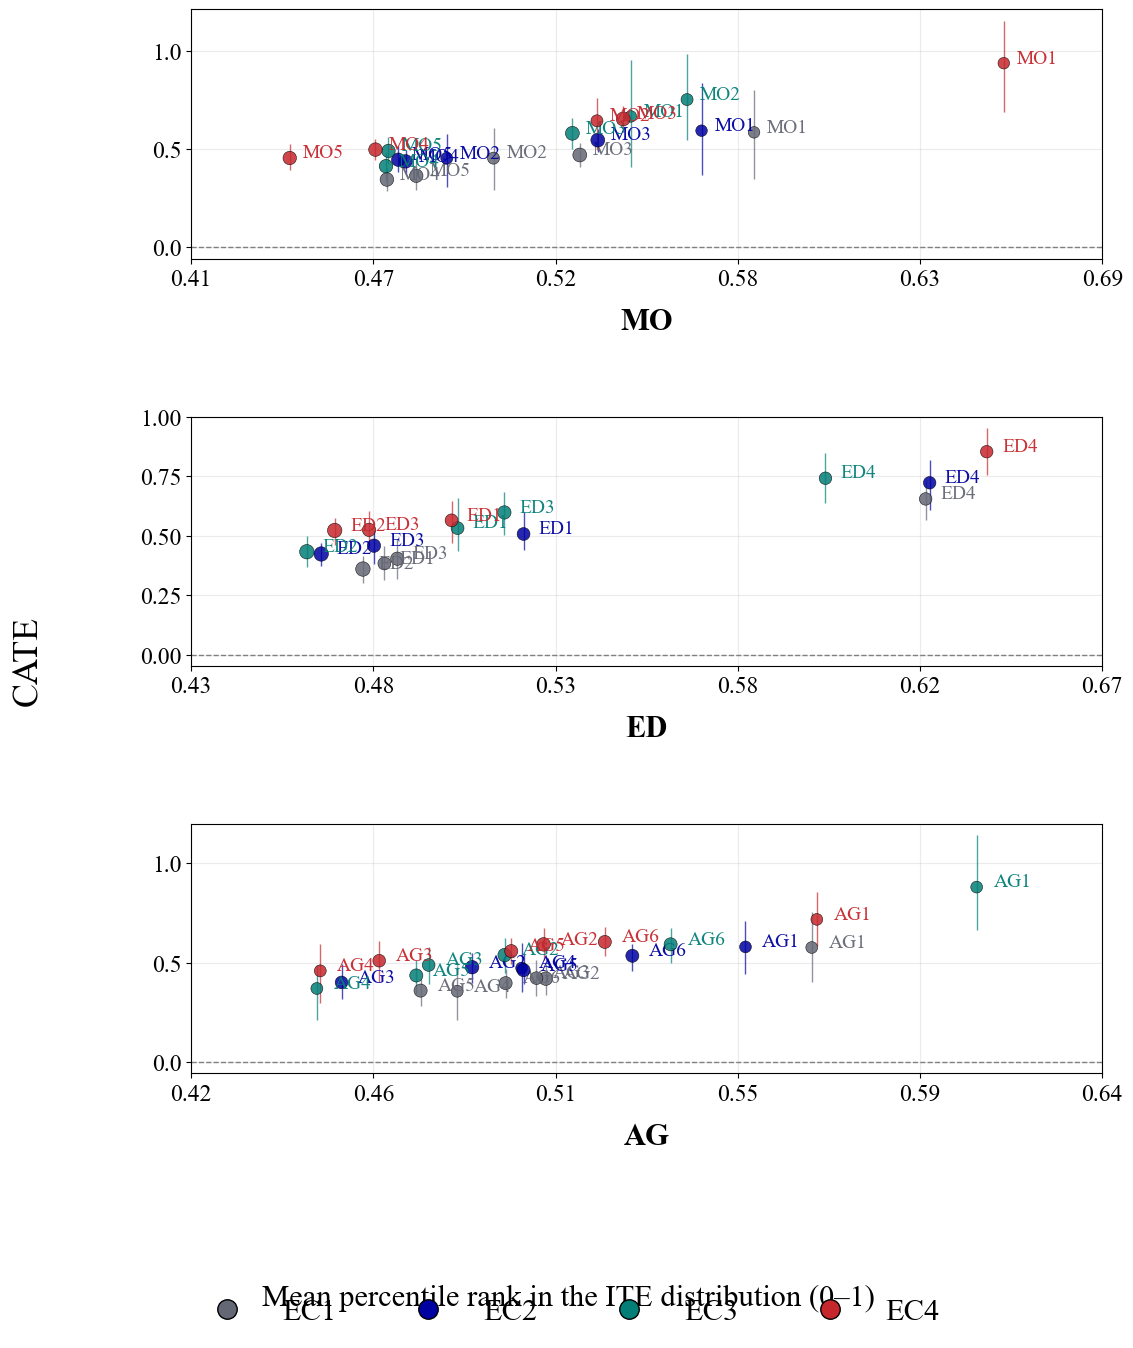

✔ Saved: D:\论文数据\2025.10 出口选择\HTE\CATE_controls_CO_MO_ED_AG_3rows_1col.png


In [63]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Global font
# ---------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

panel_text = {
    "MO": "MO",
    "ED": "ED",
    "AG": "AG",
}

X_LABEL = "Mean percentile rank in the ITE distribution (0–1)"


# ======================================================
# Plotting function
# ======================================================
def draw_one_var_on_ax(
    ax,
    cate_df,
    var,
    colors,
    outcomes=("EC1", "EC2", "EC3", "EC4"),
    bootstrap_B=300,
    pad=0.03,
    n_xticks=6,
):

    dvar = cate_df[cate_df["var"] == var].copy()

    if dvar.empty:
        ax.set_visible(False)
        return

    xmin = float(dvar["x_mean_rank"].min())
    xmax = float(dvar["x_mean_rank"].max())

    xmin_plot = max(0.0, xmin - pad)
    xmax_plot = min(1.0, xmax + pad)

    for oc, c in colors.items():

        d = dvar[dvar["outcome"] == oc].sort_values("level")

        if d.empty:
            continue

        # ======================================================
        # Larger scatter size
        # ======================================================
        sizes = np.clip(d["n"].values, 10, None)
        sizes = 50 + 3.5 * np.sqrt(sizes)

        # ---------------------------
        # Scatter
        # ---------------------------
        ax.scatter(
            d["x_mean_rank"].values,
            d["CATE"].values,
            s=sizes,
            alpha=0.85,
            color=c,
            edgecolor="black",
            linewidth=0.4,
            label=oc,
            zorder=3
        )

        # ---------------------------
        # Error bars
        # ---------------------------
        if bootstrap_B > 0 and ("CI_lo" in d.columns) and ("CI_hi" in d.columns):

            ax.vlines(
                d["x_mean_rank"].values,
                d["CI_lo"].values,
                d["CI_hi"].values,
                color=c,
                linewidth=1.0,
                alpha=0.7,
                zorder=2
            )

        # ======================================================
        # Larger text labels
        # ======================================================
        for _, r in d.iterrows():

            ax.text(
                r["x_mean_rank"] + 0.004,
                r["CATE"] + 0.002,
                f"{var}{int(r['level'])}",
                fontsize=14,
                color=c,
                family="Times New Roman",
                alpha=0.95
            )

    # ---------------------------
    # Baseline
    # ---------------------------
    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1,
        color="grey"
    )

    # ---------------------------
    # Axis range
    # ---------------------------
    ax.set_xlim(xmin_plot, xmax_plot)

    xt = np.linspace(xmin_plot, xmax_plot, n_xticks)

    ax.set_xticks(xt)

    ax.set_xticklabels(
        [f"{x:.2f}" for x in xt]
    )

    # ---------------------------
    # Grid
    # ---------------------------
    ax.grid(alpha=0.25)


# ======================================================
# Layout: 3 rows × 1 column
# ======================================================
layout_vars = ["MO", "ED", "AG"]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14)
)

# ======================================================
# Draw subplots
# ======================================================
for i, v in enumerate(layout_vars):

    ax = axes[i]

    draw_one_var_on_ax(
        ax,
        cate_lv_df,
        v,
        colors,
        outcomes,
        BOOTSTRAP_B
    )

    ax.tick_params(
        axis="both",
        labelsize=17
    )

    ax.text(
        0.5,
        -0.20,
        panel_text[v],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=22,
        fontweight="bold",
        family="Times New Roman"
    )

# ======================================================
# Global labels
# ======================================================
fig.supylabel(
    "CATE",
    fontsize=26,
    family="Times New Roman",
    x=0.035
)

# 不放大 X_LABEL
fig.supxlabel(
    X_LABEL,
    fontsize=22,
    family="Times New Roman",
    y=0.035
)

# ======================================================
# Legend
# ======================================================
handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=colors[o],
        markeredgecolor="black",
        markersize=14,
        label=o
    )
    for o in outcomes
]

fig.legend(
    handles=handles,
    labels=outcomes,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=22,
    bbox_to_anchor=(0.5, 0.005)
)

# ======================================================
# Layout adjustment
# ======================================================
plt.tight_layout(
    rect=[0.08, 0.09, 0.98, 0.98],
    h_pad=3.0
)

# ======================================================
# Save
# ======================================================
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(
    SAVE_DIR,
    "CATE_controls_CO_MO_ED_AG_3rows_1col.png"
)

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"✔ Saved: {save_path}")